In [5]:
import numpy as np 
import pandas as pd 
import h5py
import re
import uproot
import glob 

from collections import Counter
import copy, sys, os
import matplotlib.pyplot as plt
from tqdm import tqdm 
# adding path to folder
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.colors as mcolors  # Importing the correct module for colors


from utils_analysis import ParticleCode, load_dataset
# Load your custom style 
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True

sys.path.insert(0, '../tools/')
from caf_readers import CafReader
from mx2_matching import Mx2_DS_Match

In [8]:
# Load datasets 
n_files = 1023
location = "nersc"
type="mr6.2"
df = load_dataset(n_files,location, type)
# Create a caf reader
caf_reader = CafReader(df)

Reading  1023  files gk
Location selected nersc
Openning MiniRun 6.2 CAFs


100%|██████████| 1023/1023 [55:38<00:00,  3.26s/it]


In [ ]:
class NeutrinoSelection:
    def __init__(self, ev_data, pdg_tab, QE=False, exclusive=False, proton_threshold=2):
        """
        Initialize NeutrinoSelection with event data and PDG table.
        """
        self.ev_data = ev_data
        self.pdg_tab = pdg_tab
        self.tpc_dist = 5
        self.xbound = 63.931
        self.ybound = 62.076
        self.zbound = 64.3163
        self.QE = QE
        self.muon_track= [None, None]
        self.exclusive = exclusive
        self.proton_threshold=proton_threshold
        self.match = None
        self.best_match_idx = None
        self.signal = np.zeros_like(self.ev_data['rec.mc.nu.vtx.x'], dtype=bool)
        self.reco_vertices = np.zeros_like(self.ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
        self.ixn_dict={
            'file_number':[], 'event_number':[], 'ixn_number':[],'true_ixn_number':[], 'cc':[], 'nprim':[], 'nsec':[], 'nneutron':[], 'nproton':[],
            'npip':[], 'npim':[], 'npi0':[], 'mode':[], 'match':[]
            }
    
    def true_neutrino_signal(self):
        """
        Identifies true neutrino signals based on various conditions.
        """
        # QE-like post-FSI with any number of neutrons
        if self.QE:
            mask_t = (
                (abs(self.ev_data['rec.mc.nu.vtx.x']) < self.xbound - self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.x']) > self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.y']) < self.ybound - self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.z']) > self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.z']) < self.zbound - self.tpc_dist) &
                (self.ev_data['rec.mc.nu.targetPDG'] == self.pdg_tab.argon) &
                (self.ev_data['rec.mc.nu.iscc'] == 1) &
                (self.ev_data['rec.mc.nu.pdg'] == -1 * self.pdg_tab.numu) &
                (np.isin(self.ev_data['rec.mc.nu.mode'], [1,4,10])) &
               # (self.ev_data['rec.mc.nu.nproton'] == 0) &
                (self.ev_data['rec.mc.nu.npip'] == 0) &
                (self.ev_data['rec.mc.nu.npim'] == 0) &
                (self.ev_data['rec.mc.nu.npi0'] == 0) &
                (self.ev_data['rec.mc.nu.nneutron'] >= 1)
            )
            for ix in range(self.ev_data['rec.mc.nu..length']):
                if mask_t[ix]:
                    n_particles = self.ev_data['rec.mc.nu.prim..length'][ix]
                    n_pre = np.sum(self.ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                    for ip in range(n_pre, n_pre + n_particles):
                        pdg = self.ev_data['rec.mc.nu.prim.pdg'][ip]
                        if pdg == self.pdg_tab.proton:
                            xs = self.ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                            ys = self.ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                            zs = self.ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                            xe = self.ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                            ye = self.ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                            ze = self.ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                            track_length = np.sqrt((xe - xs) ** 2 + (ye - ys) ** 2 + (ze - zs) ** 2)
                            if track_length > self.proton_threshold:
                                self.signal[ix] = False
        else:
            mask_t = (
                (abs(self.ev_data['rec.mc.nu.vtx.x']) < self.xbound - self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.x']) > self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.y']) < self.ybound - self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.z']) > self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.z']) < self.zbound - self.tpc_dist) &
                (self.ev_data['rec.mc.nu.targetPDG'] == self.pdg_tab.argon) &
                (self.ev_data['rec.mc.nu.iscc'] == 1) &
                (abs(self.ev_data['rec.mc.nu.pdg']) == self.pdg_tab.numu)
            )

        self.signal[mask_t] = True

        for ix in range(self.ev_data['rec.mc.nu..length']):
            if mask_t[ix]:
                n_particles = self.ev_data['rec.mc.nu.prim..length'][ix]
                n_pre = np.sum(self.ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                for ip in range(n_pre, n_pre + n_particles):
                    pdg = self.ev_data['rec.mc.nu.prim.pdg'][ip]
                    if np.abs(pdg) == self.pdg_tab.muon:
                        Elep = self.ev_data['rec.mc.nu.prim.p.E'][ip]
                        cosL = self.calculate_cosL(ip)
                        if cosL < 0.9 and Elep < 1:
                            self.signal[ix] = False
        return self.signal
    
    def calculate_cosL(self, ip):
        """
        Utility function to calculate cosL.
        """
        dz = self.ev_data['rec.mc.nu.prim.start_pos.z'][ip] - self.ev_data['rec.mc.nu.prim.end_pos.z'][ip]
        start_pos = np.array([
            self.ev_data['rec.mc.nu.prim.start_pos.x'][ip],
            self.ev_data['rec.mc.nu.prim.start_pos.y'][ip],
            self.ev_data['rec.mc.nu.prim.start_pos.z'][ip]
        ])
        end_pos = np.array([
            self.ev_data['rec.mc.nu.prim.end_pos.x'][ip],
            self.ev_data['rec.mc.nu.prim.end_pos.y'][ip],
            self.ev_data['rec.mc.nu.prim.end_pos.z'][ip]
        ])
        track_length = np.linalg.norm(start_pos - end_pos)
        return abs(dz / track_length)


    def reco_neutrino_signal(self, mode='mx2'):
        """
        Defines the reconstructed neutrino signal in the fiducial volume.
        """
        mask_fv = (
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.x']) < self.xbound - self.tpc_dist) &
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.x']) > self.tpc_dist) &
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.y']) < self.ybound - self.tpc_dist) &
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.z']) > self.tpc_dist) &
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.z']) < self.zbound - self.tpc_dist)
        )
        vertices = mask_fv if not self.QE else self.QE_reco_signal(mask_fv)
        if mode == 'FV':
            self.reco_vertices = vertices
        elif mode == '2x2':
            track_out_2x2 = self.track_selection_signal()
            self.reco_vertices = vertices & track_out_2x2
        elif mode == 'mx2':
            match_mx2, self.muon_track = self.track_match_mx2()
            self.reco_vertices = vertices & match_mx2
        else:
            raise ValueError("Invalid mode. Options: FV, 2x2, mx2")
        return self.reco_vertices, self.muon_track

    def QE_reco_signal(self, mask_fv):
        """
        Applies QE-specific signal selection.
        """
        QE_signal = mask_fv.copy()
        for vtx in range(self.ev_data['rec.common.ixn.dlp..length']):
            n_vtx = self.ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
            n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
            count_prim = 0
            count_sec = 0

            if self.exclusive:
                for ip in range(n_pre, n_pre + n_vtx):
                    count_prim += self.ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                    count_sec += 1 if not self.ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] else 0

                if count_prim == 1 and count_sec == 1:
                    continue
                else:
                    QE_signal[vtx] = 0
            else:
                for ip in range(n_pre, n_pre + n_vtx):
                    count_prim += self.ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                    if count_prim > 1:
                        break
                if count_prim != 1:
                    QE_signal[vtx] = 0
        return QE_signal

    def track_selection_signal(self):
        """
        Selects tracks that exit the 2x2 volume.
        """
        z_end_track = self.ev_data['rec.common.ixn.dlp.part.dlp.end.z']
        is_reco_primary = self.ev_data['rec.common.ixn.dlp.part.dlp.primary']
        track_out = np.zeros_like(self.ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

        for vtx in range(len(self.ev_data['rec.common.ixn.dlp.vtx.x'])):
            n_reco_tracks = self.ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
            n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
            for ip in range(n_pre, n_pre + n_reco_tracks):
                if is_reco_primary[ip] and z_end_track[ip] >= self.zbound:
                    track_out[vtx] = True
                    break
        return track_out

    def track_match_mx2(self):
        """
        Matches tracks with MINERvA data.
        """
        minerva_data = caf_reader.get_minerva_data(self.ev_data)
        is_reco_primary = self.ev_data['rec.common.ixn.dlp.part.dlp.primary']
        x_start_track = self.ev_data['rec.common.ixn.dlp.part.dlp.start.x']
        y_start_track = self.ev_data['rec.common.ixn.dlp.part.dlp.start.y']
        z_start_track = self.ev_data['rec.common.ixn.dlp.part.dlp.start.z']
        x_end_track = self.ev_data['rec.common.ixn.dlp.part.dlp.end.x']
        y_end_track = self.ev_data['rec.common.ixn.dlp.part.dlp.end.y']
        z_end_track = self.ev_data['rec.common.ixn.dlp.part.dlp.end.z']
        track_Mx2 = np.zeros_like(self.ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

        for vtx in range(len(self.ev_data['rec.common.ixn.dlp.vtx.x'])):
            n_reco_tracks = self.ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
            n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
            for ip in range(n_pre, n_pre + n_reco_tracks):
                if is_reco_primary[ip] and z_end_track[ip] >= self.zbound:
                    self.muon_track = [
                        [x_start_track[ip], y_start_track[ip], z_start_track[ip]],
                        [x_end_track[ip], y_end_track[ip], z_end_track[ip]]
                    ]
                    reco_vtx = [
                        self.ev_data['rec.common.ixn.dlp.vtx.x'][vtx],
                        self.ev_data['rec.common.ixn.dlp.vtx.y'][vtx],
                        self.ev_data['rec.common.ixn.dlp.vtx.z'][vtx]
                    ]
                    m_index, ds_dp, deltaX, deltaY, exit_minerva = Mx2_DS_Match(
                        self.muon_track, minerva_data, reco_vtx, mc=True, verbose=False)
                    if exit_minerva and m_index is not None:
                        track_Mx2[vtx] = True
        return track_Mx2, self.muon_track
    
    def matching(self, vtx_index):
        n_vtx = self.ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
        n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
        max_overlap = 0
        for ip in range(n_pre, n_pre + n_vtx):
            temp_overlap = self.ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
            temp_tp_idx = self.ev_data['rec.common.ixn.dlp.truth'][ip]
            if temp_overlap > max_overlap:
                max_overlap = temp_overlap
                self.best_match_idx = temp_tp_idx
        if self.best_match_idx is not None:
            delta_x = np.abs(self.ev_data['rec.mc.nu.vtx.x'][self.best_match_idx] - self.ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
            delta_y = np.abs(self.ev_data['rec.mc.nu.vtx.y'][self.best_match_idx] - self.ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
            delta_z = np.abs(self.ev_data['rec.mc.nu.vtx.z'][self.best_match_idx] - self.ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])
            if self.signal[self.best_match_idx] and delta_x < 5 and delta_y < 5 and delta_z < 5:
                self.reco_vertices[vtx_index] = True
                return True, self.best_match_idx, self.reco_vertices
        return False, self.best_match_idx, self.reco_vertices

    def save_inx_info(self, vtx_index):
        self.ixn_dict['file_number'].append(self.ev_data['file_number'])
        self.ixn_dict['event_number'].append(self.ev_data['rec.meta.nd_lar.event'])
        self.ixn_dict['ixn_number'].append(vtx_index)
        self.ixn_dict['mode'].append(self.ev_data['rec.mc.nu.mode'][self.best_match_idx])
        self.ixn_dict['nprim'].append(self.ev_data['rec.mc.nu.nprim'][self.best_match_idx])
        self.ixn_dict['nsec'].append(self.ev_data['rec.mc.nu.nsec'][self.best_match_idx])
        self.ixn_dict['nproton'].append(self.ev_data['rec.mc.nu.nproton'][self.best_match_idx])
        self.ixn_dict['nneutron'].append(self.ev_data['rec.mc.nu.nneutron'][self.best_match_idx])
        self.ixn_dict['npip'].append(self.ev_data['rec.mc.nu.npip'][self.best_match_idx])
        self.ixn_dict['npim'].append(self.ev_data['rec.mc.nu.npim'][self.best_match_idx])
        self.ixn_dict['npi0'].append(self.ev_data['rec.mc.nu.npi0'][self.best_match_idx])
        if self.match == 1:
            self.ixn_dict['true_ixn_number'].append(self.best_match_idx)
            self.ixn_dict['match'].append(1)
        if self.match == 0:
            self.ixn_dict['match'].append(0)
            
        # Get info of neutron-induced particles
    def sec_info(self, vtx_t, ip):
        dic = {'E': [], 'pdg': [], 'track_neutron': []}
        induced = self.was_neutron_induced(vtx_t, self.ev_data['rec.mc.nu.sec.parent'][ip])
        contained=self.isContainedFV([self.ev_data['rec.mc.nu.sec.start_pos.x'][ip], self.ev_data['rec.mc.nu.sec.start_pos.y'][ip], self.ev_data['rec.mc.nu.sec.start_pos.z'][ip]])
        contained2=self.isContainedFV([self.ev_data['rec.mc.nu.sec.end_pos.x'][ip], self.ev_data['rec.mc.nu.sec.end_pos.y'][ip], self.ev_data['rec.mc.nu.sec.end_pos.z'][ip]])
        
        if induced and contained and contained2:
            dic['E'].append(self.ev_data[f'rec.mc.nu.sec.p.E'][ip])
            dic['pdg'].append(self.ev_data['rec.mc.nu.sec.pdg'][ip])
            dic['track_neutron'].append(self.ev_data['rec.mc.nu.sec.parent'][ip])
        return dic

    def prim_info(self,ip):     
        dic = {'E': []}
        contained=self.isContainedFV([self.ev_data['rec.mc.nu.prim.start_pos.x'][ip], self.ev_data['rec.mc.nu.prim.start_pos.y'][ip], self.ev_data['rec.mc.nu.prim.start_pos.z'][ip]])
        if contained:
            if self.ev_data[f'rec.mc.nu.prim.pdg'][ip] == self.pdg_tab.neutron:    
                dic['E'].append(self.ev_data[f'rec.mc.nu.prim.p.E'][ip])
            return dic
                            
    def particles_inx( self,vtx_t,type, dic):
        # Get the number of particles for the current interaction
        n_particles = self.ev_data[f'rec.mc.nu.{type}..length'][vtx_t]
        n_pre = np.sum(self.ev_data[f'rec.mc.nu.{type}..length'][:vtx_t]) if vtx_t > 0 else 0
        
        # Iterate over the particles in the range
        for ip in range(n_pre, n_pre + n_particles):
            if type == 'prim':
                # Update the primary dictionary
                prim_data = self.prim_info(ip)
                for key in prim_data:
                    dic[key].extend(prim_data[key])
            if type == 'sec':
                # Update the secondary dictionary
                sec_data = self.sec_info(vtx_t,ip)
                for key in sec_data:   
                    dic[key].extend(sec_data[key])
        return dic
    
    def isContainedFV(self, vtx_pos):
        if(
            abs(vtx_pos[0])< self.xbound-self.tpc_dist and
            abs(vtx_pos[0])> self.tpc_dist and
            abs(vtx_pos[1])< self.ybound-self.tpc_dist and
            abs(vtx_pos[2])> self.tpc_dist and
            abs(vtx_pos[2])< self.zbound-self.tpc_dist
        ): return True
        else: return False  
        
    def was_neutron_induced(self, vtx_t, proton_parent_id):
        # Iterates over primaries to find parent
        neutron_induced = False
        n_prim = self.ev_data['rec.mc.nu.prim..length'][vtx_t]
        n_pred_prim = np.sum(self.ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
        for ip in range(n_pred_prim, n_pred_prim + n_prim):
            if (
                self.ev_data['rec.mc.nu.prim.pdg'][ip] == self.pdg_tab.neutron and 
                self.ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
            ):
                neutron_induced = True
        return neutron_induced
    
class NeutrinoAnalysis:
    def __init__(self):
        self.num_interactions = 0
        self.num_vertices = 0
        self.count_match_FV = 0
        self.num_match_signal = 0
        self.ScatteringMode = {'CC kQE': 1, 'CC kDIS': 3, 'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10}
        self.CurrentMode = {'NC': 0, 'RockMuons': 2}
        self.scattering_counters = {mode: 0 for mode in self.ScatteringMode.values()}
        self.current_counters = {mode: 0 for mode in self.CurrentMode.values()}
        self.insignal_counters = {mode: 0 for mode in self.ScatteringMode.values()}
        self.purity = None
        self.efficiency = None
        self.pastel_colors = [
            "#FFB3BA",  # Pastel Red
            "#FFDFBA",  # Pastel Orange
            "#FFFFBA",  # Pastel Yellow
            "#BAFFC9",  # Pastel Green
            "#BAE1FF",  # Pastel Blue
            "#E6BAFF",  # Pastel Purple
            "#FFB3E6",  # Pastel Pink
            "#C2C2F0",  # Pastel Lavender
            "#F0C2C2",  # Pastel Rose
            "#C2F0E0",  # Pastel Mint
            "#FFD9C0",  # Pastel Peach
            "#D1CFE2",  # Pastel Lilac
            "#F7C6C7",  # Pastel Salmon
            "#E3EAA7",  # Pastel Olive
            "#B5EAD7",  # Pastel Aqua
            "#A2D5F2",  # Pastel Sky Blue
            "#E2F0CB",  # Pastel Lime
            "#F6E1C3",  # Pastel Sand
            "#D4A5A5",  # Pastel Blush
            "#C3B1E1"   # Pastel Violet
        ]
        
        
    def type_interaction(self,ev_data,best_match_idx): 
        scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
        current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]
        if ev_data['rec.mc.nu.genieIdx'][best_match_idx] > 1E9:
            self.current_counters[self.CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
        if scattering_mode in self.ScatteringMode.values() and current_mode ==1:
            self.scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
        elif scattering_mode in self.ScatteringMode.values() and current_mode ==0:
            self.current_counters[self.CurrentMode['NC']] += 1  # Increment the counter for NC
        return self.scattering_counters, self.current_counters
    
    def efficiency_purity(self):
        """
        Compute efficiency and purity.
        """
        self.purity = self.count_match_FV / self.num_vertices if self.num_vertices > 0 else 0
        self.efficiency = self.count_match_FV / self.num_interactions if self.num_interactions > 0 else 0
        return self.efficiency, self.purity
    
    def plot_interactions(self):
        """
        Generates a pie chart for interaction types.
        """
        mode_labels = (
            [key for key, value in self.ScatteringMode.items() if value in self.scattering_counters] +
            [key for key, value in self.CurrentMode.items() if value in self.current_counters] +
            ['True Signal']
        )
        mode_counts = (
            [self.scattering_counters[self.ScatteringMode[label]] for label in self.ScatteringMode.keys()] +
            [self.current_counters[self.CurrentMode[label]] for label in self.CurrentMode.keys()] +
            [self.count_match_FV]
        )
        plt.figure(figsize=(7, 7))
        plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85,colors=self.pastel_colors[:len(mode_labels)])
        plt.legend(mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
        plt.title('Interaction Type of Reconstructed Vertices')
        plt.axis('equal')
        plt.show()
        
    #plot type of scattering of the reco vertices that matched signal
    def plot_signal_interactions(self):
        labels = [label for label, code in self.ScatteringMode.items() if code in self.insignal_counters]
        sizes = [self.insignal_counters[self.ScatteringMode[label]] for label in labels]
        plt.figure(figsize=(7, 7))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=self.pastel_colors[:len(labels)])
        plt.title('Scattering Mode of Vertices Matching Signal')
        plt.axis('equal')
        plt.show()
    #Print and plot results    
    def display_summary(self):
        print("Interaction Summary:\n")
        print(f'There are {self.num_vertices} reconstructed vertices.')
        print(f'There are {self.count_match_FV} reco vertices matching true interaction signal.')
        print(f'There are {self.num_interactions} true interactions')
        total_interactions = sum(self.scattering_counters.values()) + sum(self.current_counters.values())
        for mode, count in {**self.scattering_counters, **self.current_counters}.items():
            percent = (count / total_interactions) * 100 if total_interactions > 0 else 0
            print(f"{mode}: {percent:.2f}%")
        print(f"\nEfficiency: {self.efficiency:.2%}")
        print(f"Purity: {self.purity:.2%}")


In [27]:
class NeutronSelection:
    #this should run per interaction not event
    def __init__(self, pdg_tab, ev_data, reco_vtx, reco_data,  muon_track, tpc_dist = 5, radius=0, cyl=0):
        self.ev_data = ev_data
        self.reco_vtx = reco_vtx
        self.reco_data = reco_data
        self.pdg_tab = pdg_tab
        self.tpc_dist = tpc_dist 
        self.muon_track = muon_track 
        self.xbound = 63.931
        self.ybound = 62.076
        self.zbound = 64.3163
        self.vtx_pos = [
            self.reco_data['rec.common.ixn.dlp.vtx.x'],
            self.reco_data['rec.common.ixn.dlp.vtx.y'], 
            self.reco_data['rec.common.ixn.dlp.vtx.z']
        ]
        self.radius= radius 
        self.cyl = cyl
        
    def part_scanner(self):
        track_length, vtx_distance, best_match_type, best_match_ixn, best_match_idx, parent_id= None, None,None, None, None, None
        n_part = len(self.reco_data['rec.common.ixn.dlp.part.dlp.E'])
        #store the reco particles of the current vertex vtx
        reco_dic ={'best_match_type': [], 'best_match_ixn': [], 'best_match_idx':[], 'length':[],'distance':[],'energy':[], 'parent_id':[]}
        
        for ip in range(n_part):
            ip_start = [
                self.reco_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
                self.reco_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
                self.reco_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
            ]
            ip_end = [
                self.reco_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
                self.reco_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
                self.reco_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
            ]
            # Check if the particle is in ROI
            in_FV = self.isContainedFV(ip_start)
            outside_vtx = self.around_vtx_region(ip_start)
            muon_track_start = self.muon_track[0]
            muon_track_end = self.muon_track[1]
            if muon_track_start is None or muon_track_end is None:
                outside_track = True
            else:
                outside_track = self.around_track_region(ip_start, muon_track_start, muon_track_end)
            if outside_vtx and in_FV and outside_track and in_FV:
                ip_pdg = self.reco_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
                is_primary = self.reco_data['rec.common.ixn.dlp.part.dlp.primary'][ip] 
                # if secondary proton, find the match
                if (ip_pdg== self.pdg_tab.proton) and (is_primary==False):  
                    best_match_type, best_match_ixn, best_match_idx, parent_id= self.match_finder(ip)          
                    track_length, vtx_distance = self.calculate_track_properties(ip_start, ip_end, self.vtx_pos)
                    if best_match_type is not None:
                        reco_dic['best_match_type'].append(best_match_type)
                        reco_dic['best_match_ixn'].append(best_match_ixn)
                        reco_dic['best_match_idx'].append(best_match_idx)
                        reco_dic['parent_id'].append(parent_id)
                        reco_dic['length'].append(track_length)
                        reco_dic['distance'].append(vtx_distance)
                        reco_dic['energy'].append(self.reco_data['rec.common.ixn.dlp.part.dlp.E'][ip])
        return reco_dic


    def match_finder(self, ip):
        best_match_type = None
        best_match_ixn=None
        best_match_idx=None
        parent_id=None
        max_overlap=0
        n_part= self.ev_data['rec.common.ixn.dlp.part.dlp..length'][self.reco_vtx ]
        n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:self.reco_vtx ]) if self.reco_vtx  > 0 else 0
        idx_ev= [n_pre, n_pre+n_part]
        idx_ev_data = list(range(idx_ev[0], idx_ev[1]))
        n_overlaps= self.reco_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
        ip_ev = idx_ev_data[ip]
        if ip_ev ==0 : truth_pre = 0
        else: truth_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip_ev]) 
        overlaps=self.ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][truth_pre:truth_pre+n_overlaps]
        matches = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][truth_pre:truth_pre+n_overlaps]
        types = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][truth_pre:truth_pre+n_overlaps] # 1 prim and 3 second
        ixns = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.ixn'][truth_pre:truth_pre+n_overlaps]
        
        for tp in range(n_overlaps):
            temp_overlap=overlaps[tp]
            temp_tp_match=matches[tp]
            temp_tp_type=types[tp]
            temp_tp_ixn=ixns[tp]
            if(temp_overlap>max_overlap):
                max_overlap=temp_overlap
                best_match_idx=temp_tp_match
                best_match_type=temp_tp_type
                best_match_ixn=temp_tp_ixn
       
        if(best_match_type==3):
            n_pre_true = np.sum(self.ev_data['rec.mc.nu.nsec'][:best_match_ixn])
            n_sec_length = self.ev_data['rec.mc.nu.nsec'][best_match_ixn]
            parent_id = self.ev_data['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        
        if(best_match_type==1):
            n_pre_true = np.sum(self.ev_data['rec.mc.nu.nprim'][:best_match_ixn])
            n_sec_length = self.ev_data['rec.mc.nu.nprim'][best_match_ixn]
            
        return best_match_type, best_match_ixn, best_match_idx, parent_id
        
    
    def get_bm_truth_data(self, bm_truth_data, bm_type, bm_idx):
        bm_dic={'type': bm_type}

        if bm_type ==1: 
            bm_dic['pdg'] = bm_truth_data['rec.mc.nu.prim.pdg'][bm_idx]
            bm_dic['energy'] = bm_truth_data['rec.mc.nu.prim.p.E'][bm_idx]
            track_length_truth, vtx_distance_truth = self.calculate_track_properties(
                (  
                    bm_truth_data['rec.mc.nu.prim.start_pos.x'][bm_idx],
                    bm_truth_data['rec.mc.nu.prim.start_pos.y'][bm_idx],
                    bm_truth_data['rec.mc.nu.prim.start_pos.z'][bm_idx]
                ),
                (
                    bm_truth_data['rec.mc.nu.prim.end_pos.x'][bm_idx],
                    bm_truth_data['rec.mc.nu.prim.end_pos.y'][bm_idx],
                    bm_truth_data['rec.mc.nu.prim.end_pos.z'][bm_idx]
                ),
                (
                    bm_truth_data['rec.mc.nu.vtx.x'],
                    bm_truth_data['rec.mc.nu.vtx.y'],
                    bm_truth_data['rec.mc.nu.vtx.z'],
                )
            )
            
            bm_dic['length'] = track_length_truth
            bm_dic['distance'] = vtx_distance_truth
            
        elif(bm_type==3):
            bm_dic['pdg'] = bm_truth_data['rec.mc.nu.sec.pdg'][bm_idx]
            bm_dic['energy'] = bm_truth_data['rec.mc.nu.sec.p.E'][bm_idx]
            bm_dic['parent_id'] = bm_truth_data['rec.mc.nu.sec.parent'][bm_idx]
            track_length_truth, vtx_distance_truth = self.calculate_track_properties(

                (  
                    bm_truth_data['rec.mc.nu.sec.start_pos.x'][bm_idx],
                    bm_truth_data['rec.mc.nu.sec.start_pos.y'][bm_idx],
                    bm_truth_data['rec.mc.nu.sec.start_pos.z'][bm_idx]
                ),
                (
                    bm_truth_data['rec.mc.nu.sec.end_pos.x'][bm_idx],
                    bm_truth_data['rec.mc.nu.sec.end_pos.y'][bm_idx],
                    bm_truth_data['rec.mc.nu.sec.end_pos.z'][bm_idx]
                ),
                (
                    bm_truth_data['rec.mc.nu.vtx.x'],
                    bm_truth_data['rec.mc.nu.vtx.y'],
                    bm_truth_data['rec.mc.nu.vtx.z'],
                )
            )
            bm_dic['length'] = track_length_truth
            bm_dic['distance'] = vtx_distance_truth

        return bm_dic
    
    def was_neutron_induced(self, vtx_t, proton_parent_id):
        # Iterates over primaries to find parent
        neutron_induced = False
        n_prim = self.ev_data['rec.mc.nu.prim..length'][vtx_t]
        n_pred_prim = np.sum(self.ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
        for ip in range(n_pred_prim, n_pred_prim + n_prim):
            if (
                self.ev_data['rec.mc.nu.prim.pdg'][ip] == self.pdg_tab.neutron and 
                self.ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
            ):
                neutron_induced = True
        return neutron_induced
    
    def isContainedFV(self, vtx_pos):
        if(
            abs(vtx_pos[0])< self.xbound-self.tpc_dist and
            abs(vtx_pos[0])> self.tpc_dist and
            abs(vtx_pos[1])< self.ybound-self.tpc_dist and
            abs(vtx_pos[2])> self.tpc_dist and
            abs(vtx_pos[2])< self.zbound-self.tpc_dist
        ): return True
        else: return False  
        
    #finds distance of the track to vtx and length 
    def calculate_track_properties(self,start_pos, end_pos, vtx):
        track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
        vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx))
        return track_length, vtx_distance
    
    def around_vtx_region(self,part_pos):
        """Check if a particle position is outside a 
        spherical exclusion region around the vertex."""
        distance = np.linalg.norm(np.array(part_pos) - np.array(self.vtx_pos))
        return distance > self.cyl
    
    def around_track_region(self,point, xs, xe):
        """Check if a point is outside a cylinder with a 
        given radius around muon track."""
        point = np.array(point)
        xs = np.array(xs)
        xe = np.array(xe)
        line_vec = xe - xs
        point_vec = point - xs
        line_length = np.linalg.norm(line_vec)

        if line_length == 0:
            return False
        else:
            line_unit_vec = line_vec / line_length
            projection_length = np.dot(point_vec, line_unit_vec)
            projection_length = np.clip(projection_length, 0, line_length)
            closest_point = xs + projection_length * line_unit_vec
            distance_to_line = np.linalg.norm(point - closest_point)
        
        return distance_to_line > self.cyl

    # def muon_track_info(self):
    #     #primary muon track of the interaction
    #     muon_track_mask = (
    #                 (self.reco_data['rec.common.ixn.dlp.part.dlp.primary'] == 1) & 
    #                 (self.reco_data['rec.common.ixn.dlp.part.dlp.pdg']== self.pdg_tab.muon)
    #     )
        
    #     muon_sx = self.reco_data['rec.common.ixn.dlp.part.dlp.start.x']#[muon_track_mask]
    #     muon_sy = self.reco_data['rec.common.ixn.dlp.part.dlp.start.y']#[muon_track_mask]
    #     muon_sz = self.reco_data['rec.common.ixn.dlp.part.dlp.start.y']#[muon_track_mask]
    #     muon_ex = self.reco_data['rec.common.ixn.dlp.part.dlp.end.x']#[muon_track_mask]
    #     muon_ey = self.reco_data['rec.common.ixn.dlp.part.dlp.end.y']#[muon_track_mask]
    #     muon_ez = self.reco_data['rec.common.ixn.dlp.part.dlp.end.z']#[muon_track_mask]   
        
    #     if np.sum(muon_track_mask)> 1: 
    #         #check match in minerva
    #         minerva_data = caf_reader.get_minerva_data(self.ev_data)
    #         #indices = np.where(muon_track_mask==1)
    #         for ip, value in enumerate(muon_track_mask): 
    #             if value:
    #                 muon_track = [
    #                     [ muon_sx[ip],  muon_sy[ip],  muon_sz[ip]],
    #                     [muon_ex[ip], muon_ey[ip], muon_ez[ip]]
    #                 ]
    #                 reco_vtx = [
    #                     self.ev_data['rec.common.ixn.dlp.vtx.x'][self.reco_vtx],
    #                     self.ev_data['rec.common.ixn.dlp.vtx.y'][self.reco_vtx],
    #                     self.ev_data['rec.common.ixn.dlp.vtx.z'][self.reco_vtx]
    #                 ]
    #                 m_index, ds_dp, deltaX, deltaY, exit_minerva = Mx2_DS_Match(
    #                     muon_track, minerva_data, reco_vtx, mc=True, verbose=False)
    #                 if exit_minerva and m_index is not None:
    #                     muon_track_mask[ip] = True
    #                 else: muon_track_mask[ip]=False
    #                 if np.sum(muon_track_mask)>1: 
    #                     print('didnt work')
    #                     return None, None
    #                 else:  
    #                     start_point = np.array([muon_sx, muon_sy, muon_sz]).flatten()
    #                     end_point = np.array([muon_ex, muon_ey, muon_ez]).flatten()
    #                     return start_point, end_point             
    #     elif not np.any(muon_track_mask):
    #         return None, None  # No muon found, return None
    #     else:
    #         start_point = np.array([muon_sx, muon_sy, muon_sz]).flatten()
    #         end_point = np.array([muon_ex, muon_ey, muon_ez]).flatten()
    #         return start_point, end_point

In [28]:
class GlobalAnalyzer:
    def __init__(self, reco_proton_dic, sample_dic,case='unique'):
        self.reco_proton_dic  = reco_proton_dic
        self.case = case
        self.sample_dic = sample_dic
        self.today_date = datetime.today().strftime('%Y-%m-%d')
        self.pdf_filename = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_{self.case}_{self.today_date}.pdf"
        self.pdf = PdfPages(self.pdf_filename)  # Global PDF object
        self.blue_p='#9c589a'
        self.purple_p='#67b8bd'
        self.pink_p='#cfc9ea'
        self.yellow_p ='#88A3E2'
        self.green_p='#AAECFC'
        
        self.dic_results = {
            'prim_protons': 0,
            'sec_protons': 0,
            'pions': 0,
            'others': 0,
            'neutron_induced':0
        }
        
        self.pdgs = np.array(self.reco_proton_dic['best_match_pdg'])
        self.tipo = np.array(self.reco_proton_dic['best_match_type'])
        # Define masks
        self.bm_prim_protons_mask = (self.pdgs == pdg_tab.proton) & (self.tipo == 1)
        self.bm_sec_protons_mask = (self.pdgs == pdg_tab.proton) & (self.tipo == 3)
        # Count occurrences

        self.C = Counter(np.abs(self.pdgs))
        # total_protons = C[2212]
        # total=len(self.pdgs)
        # Add counts for specific particles
        self.C['2212_prim'] = np.sum(self.bm_prim_protons_mask)
        self.C['2212_sec'] = np.sum(self.bm_sec_protons_mask) - len(sample_dic['reco_energy'])
        self.C['2212_n_ind'] = len(sample_dic['reco_energy'])
        
        for key, value in self.C.items():
            if key == '2212_prim':
                self.dic_results['prim_protons'] = np.sum(self.bm_prim_protons_mask)
            elif key == '2212_sec':
                self.dic_results['sec_protons'] = np.sum(self.bm_sec_protons_mask) - len(sample_dic['reco_energy'])
            elif key == 211:
                self.dic_results['pions'] = value
            elif key== 2212: continue
        #     dic_results['all_protons'] = value
            elif key == '2212_n_ind':
                self.dic_results['neutron_induced'] = len(sample_dic['reco_energy'])
            else: 
                self.dic_results['others'] += value  # Use += to add to the count

   
    def particle_predictions(self):
        # Initialize dictionary
        labels = [r'$\text{p}_\text{prim}$',r'$\text{p}_\text{sec}$',r'$\pi^{\pm}$','others', r'$\text{n}_\text{prim}\rightarrow \text{p}_\text{sec}$']
        sizes = self.dic_results.values()
        # Plotting the pie chart
        plt.figure(figsize=(8, 8))
        plt.pie(sizes, labels=labels, colors=[self.purple_p, self.green_p, self.pink_p,self.blue_p, self.yellow_p] , autopct='%1.1f%%', startangle=140,textprops={'fontsize': 18})
        #plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT ', fontsize = '10')
        plt.suptitle('Best match of reconstructed secondary protons', fontsize=10)
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.legend(fontsize = 7,loc='upper right')
        plt.show()
        # self.pdf.savefig()
        # plt.close()
        
    def plot_track_lenght(self):
        #convert to mev
        #bm_lenght= [sample/1000 for sample in self.sample_dic['best_match_length']]
        plt.hist(self.sample_dic['reco_length'],bins=10,histtype='step', range=[0,20], color='#43dfd8', linewidth=1.5,density=True,label=r'Reco signal')
        plt.hist(self.sample_dic['best_match_length'],bins=10,histtype='step',range=[0,20], color='#224a8e',linestyle='--', density=True,linewidth=1,label=r'True best match')
        #plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
        plt.xlabel(' Proton track lenght (cm)')
        plt.ylabel('Number of protons (normalized)', fontsize='10')
        plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
        plt.legend(loc='upper right', fontsize='8') 
        plt.show()
        # self.pdf.savefig()
        # plt.close()
        
        plt.hist(self.sample_dic['reco_distance'],bins=30,histtype='step', range=[0,50], color=self.blue_p, linewidth=1.5,density=True,label=r'Reconstructed')
        plt.hist(self.sample_dic['best_match_distance'],bins=30,histtype='step',range=[0,50], color='#43dfd8',linestyle='--', density=True,linewidth=1,label=r'True')
        #plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
        plt.xlabel(' Distance From Vertex (cm)')
        plt.ylabel('Number of Protons', fontsize='10')
        plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize = '10')
        plt.legend(loc='upper right', fontsize='8') 
        plt.show()
        # self.pdf.savefig()
        # plt.close()
            
    def plot_part_dis(self):
        bmlentrack = {}
        bmdistancetrack ={}
        recolentrack = {}
        recodistancetrack ={}
        #convert to array
        bmlength = np.array(self.reco_proton_dic['best_match_length'])
        bmdistance = np.array(self.reco_proton_dic['best_match_distance'])
        recolength = np.array(self.reco_proton_dic['reco_length'])
        recodistance = np.array(self.reco_proton_dic['reco_distance'])
        total=len(self.pdgs)
        percents={}
        # Fill out dictionaries for each particle
        for i,value in self.dic_results.items():
            if i =='prim_protons':
                bmdistancetrack[i] = bmdistance[self.bm_prim_protons_mask]
                recodistancetrack[i] = recodistance[self.bm_prim_protons_mask]
                bmlentrack[i] = bmlength[self.bm_prim_protons_mask]
                recolentrack[i] = recolength[self.bm_prim_protons_mask]
                percents[i] = (value/total)*100
            elif i == 'pions':
                bmdistancetrack[i] = bmdistance[(np.abs(self.pdgs) == 211)]
                recodistancetrack[i] = recodistance[(np.abs(self.pdgs) == 211)]
                bmlentrack[i] = bmlength[(np.abs(self.pdgs) == 211)]
                recolentrack[i] = recolength[(np.abs(self.pdgs) == 211)]
                percents[i] = (value/total)*100
            elif i =='sec_protons':
                bmdistancetrack[i] = bmdistance[self.bm_sec_protons_mask]
                recodistancetrack[i] = recodistance[self.bm_sec_protons_mask]
                bmlentrack[i] = bmlength[self.bm_sec_protons_mask]
                recolentrack[i] = recolength[self.bm_sec_protons_mask]
                percents[i] = (value/total)*100
            else:
                bmdistancetrack['others'] = bmdistance[(np.abs(self.pdgs) == 321) | (np.abs(self.pdgs) == 3222)]
                recodistancetrack['others'] = recodistance[(np.abs(self.pdgs) == 321) | (np.abs(self.pdgs) == 3222)]
                bmlentrack['others']  = bmlength[(np.abs(self.pdgs) == 321) | (np.abs(self.pdgs) == 3222)]
                recolentrack['others'] = recolength[(np.abs(self.pdgs) == 321) | (np.abs(self.pdgs) == 3222)]
                percents['others'] = (value/total)*100

        # Extract distance arrays for stacking
        datasets = [
            bmdistancetrack.get('prim_protons', []),
            bmdistancetrack.get('pions', []),
            bmdistancetrack.get('sec_protons', []),
            bmdistancetrack.get('others', []),
        ]

        # Remove empty lists from datasets
        datasets = [arr for arr in datasets if len(arr) > 0]

        labels = [
            f'Primary Protons ({percents.get("prim_protons", 0):.2f}%)',
            f'Pions ({percents.get("pions", 0):.2f}%)',
            f'Secondary Protons ({percents.get("sec_protons", 0):.2f}%)',
            f'Others ({percents.get("others", 0):.2f}%)'
        ]

        # Match number of colors to datasets
        colors = [self.blue_p, self.purple_p, self.pink_p, self.yellow_p]
        colors = colors[:len(datasets)]  # Trim colors to match datasets

        # Plot stacked histogram
        plt.hist(
            datasets,
            bins=15,
            stacked=True,
            range=[0, 25],
            label=labels[:len(datasets)],  # Match labels to dataset size
            color=colors  
        )

        plt.xlabel('Distance from vertex (cm)', fontsize=10)
        plt.ylabel('Number of particles', fontsize=10)
        plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize=7)
        plt.suptitle('Reconstructed Secondary Protons', fontsize=10)
        plt.legend(loc='upper right', fontsize=6)
        plt.show()
        # self.pdf.savefig()
        # plt.close()
        
    def lenght_vs_distance(self):
        plt.hist2d(self.sample_dic['reco_distance'],self.sample_dic['reco_length'],  bins=105, norm=mcolors.LogNorm(), cmap='viridis')
        # plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
        plt.xlim(0, 60)
        plt.ylim(0,60)
        plt.colorbar(label='Counts')
        plt.ylabel('Track length (cm)')
        plt.xlabel('Distance from vertex (cm)')
        plt.title(r'DUNE $2\times 2$ MiniRun 6.2, $10^{19}$ POT', fontsize = '7')
        plt.suptitle(r'Reconstructed Quantities', fontsize = '10')
        #plt.show()
        self.pdf.savefig()
        plt.close()

        plt.hist2d(self.sample_dic['best_match_distance'],self.sample_dic['best_match_length'],  bins=500, norm=mcolors.LogNorm(), cmap='viridis')
        # plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
        plt.xlim(0, 60)
        plt.ylim(0, 60)
        plt.colorbar(label='Counts')
        plt.ylabel('Track length (cm)')
        plt.xlabel('Distance from vertex (cm)')
        plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize = '7')
        plt.suptitle(r'True Quantities', fontsize = '10')
        plt.show()
        # self.pdf.savefig()
        # plt.close()

    def save_pdf(self):
        """Closes the PDF file."""
        self.pdf.close()
        return self.pdf_filename

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  ang_xz_diff = np.abs(np.arctan(mn_dx/mn_dz) - np.arctan(tpc_dx/tpc_dz))
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:112: RuntimeWarning: divide by zero encountered in scalar divide
  ang_yz_diff = np.abs(np.arctan(mn_dy/mn_dz) - np.arctan(tpc_dy/tpc_dz))


Interaction Summary:

There are 478 reconstructed vertices.
There are 397 reco vertices matching true interaction signal.
There are 2850 true interactions
1: 34.57%
3: 12.35%
4: 34.57%
5: 6.17%
10: 11.11%
0: 1.23%
2: 0.00%

Efficiency: 13.93%
Purity: 83.05%


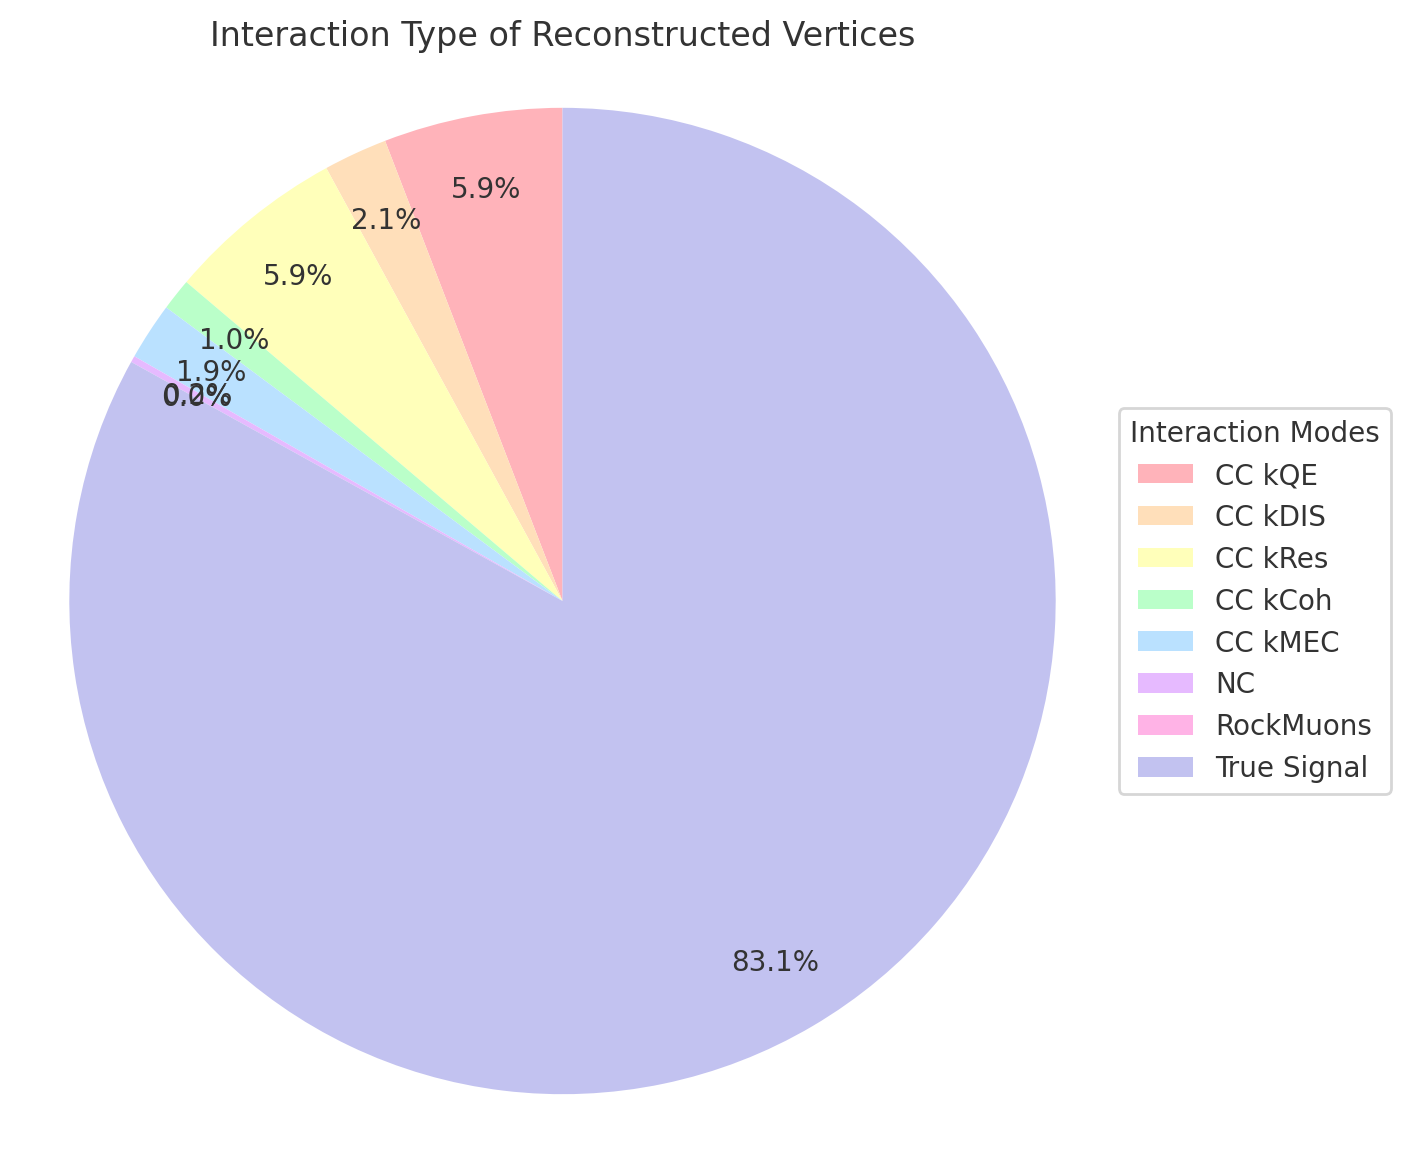

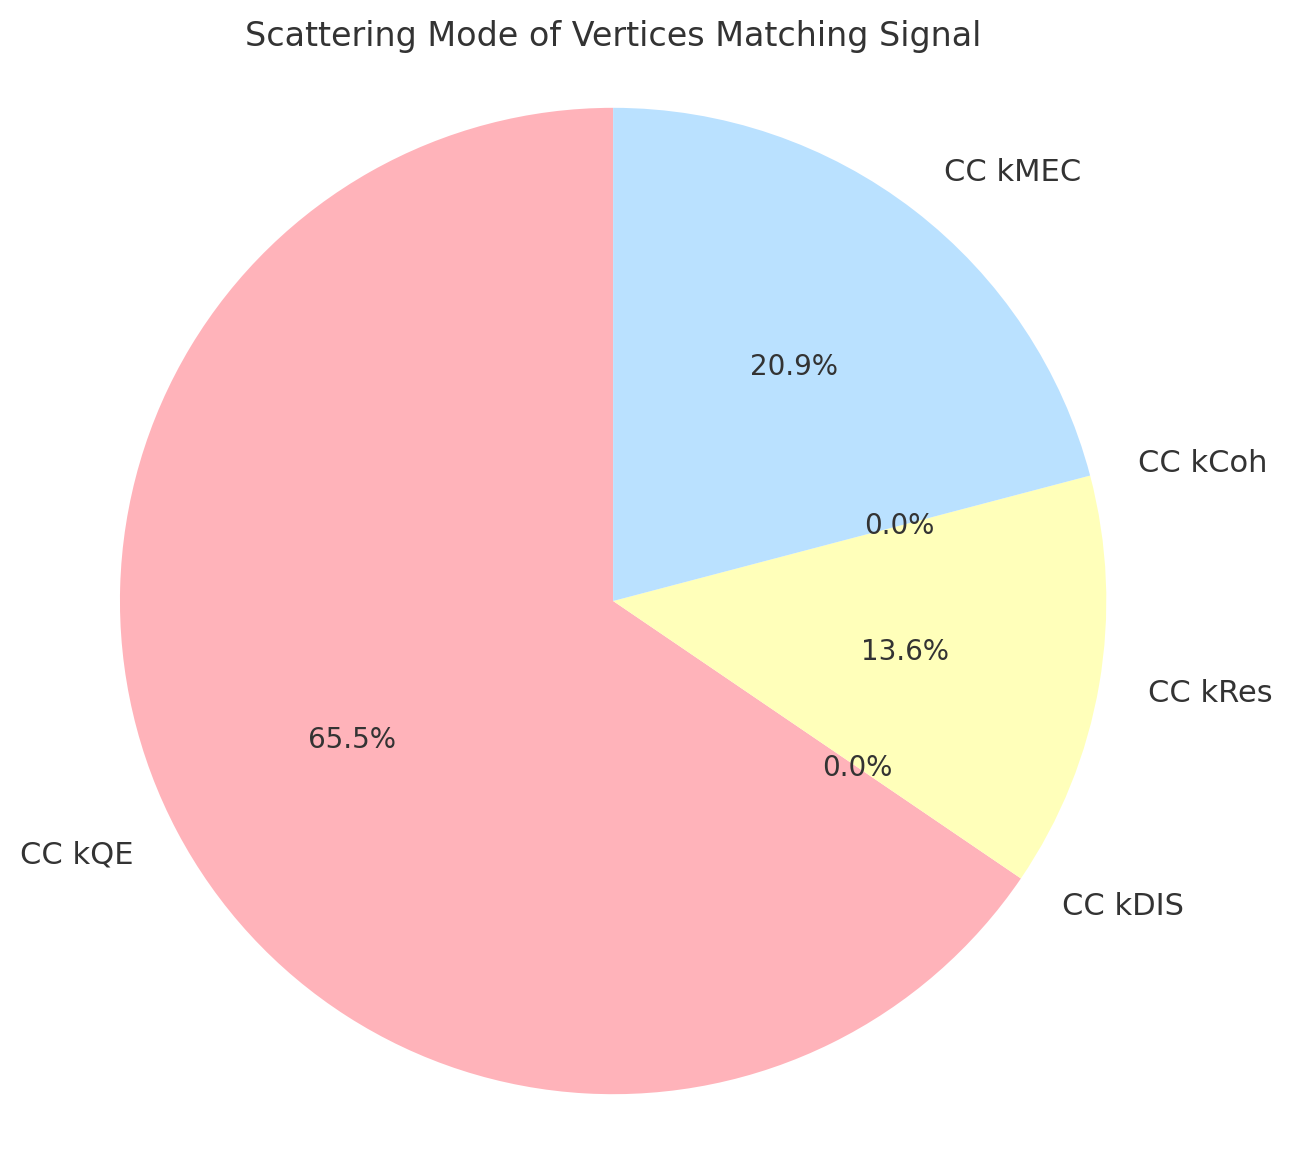

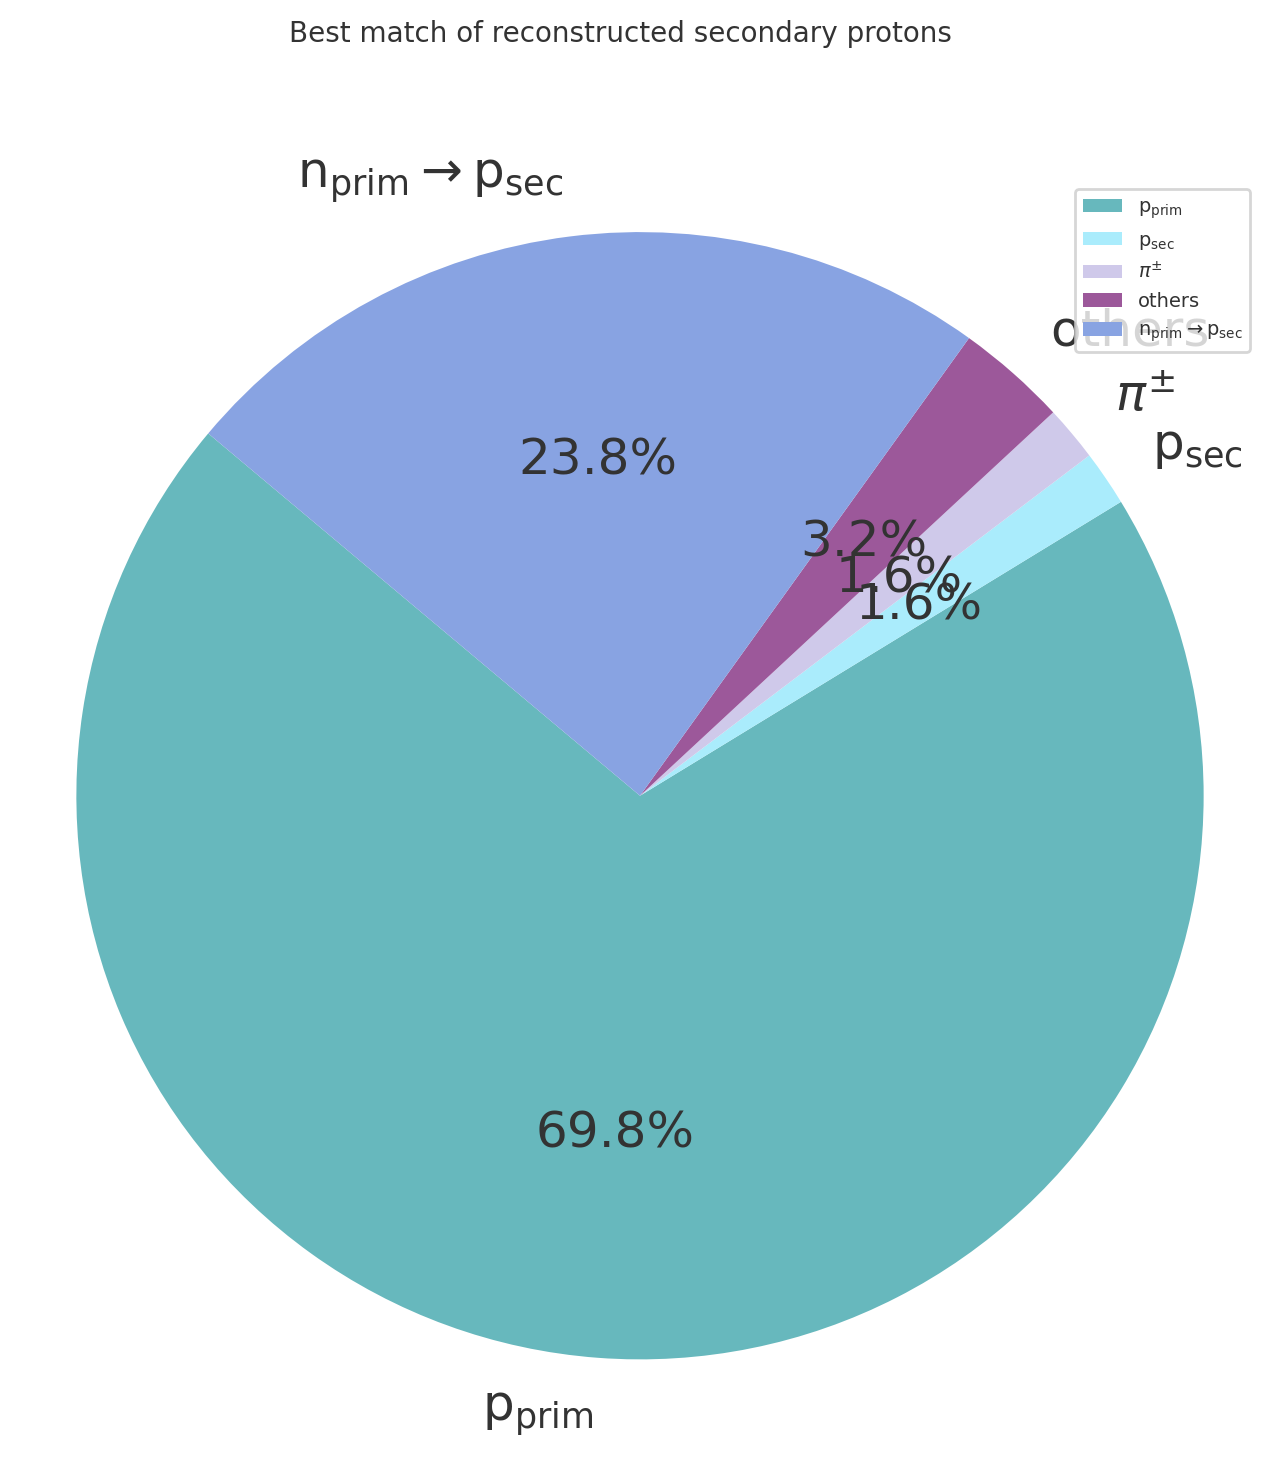

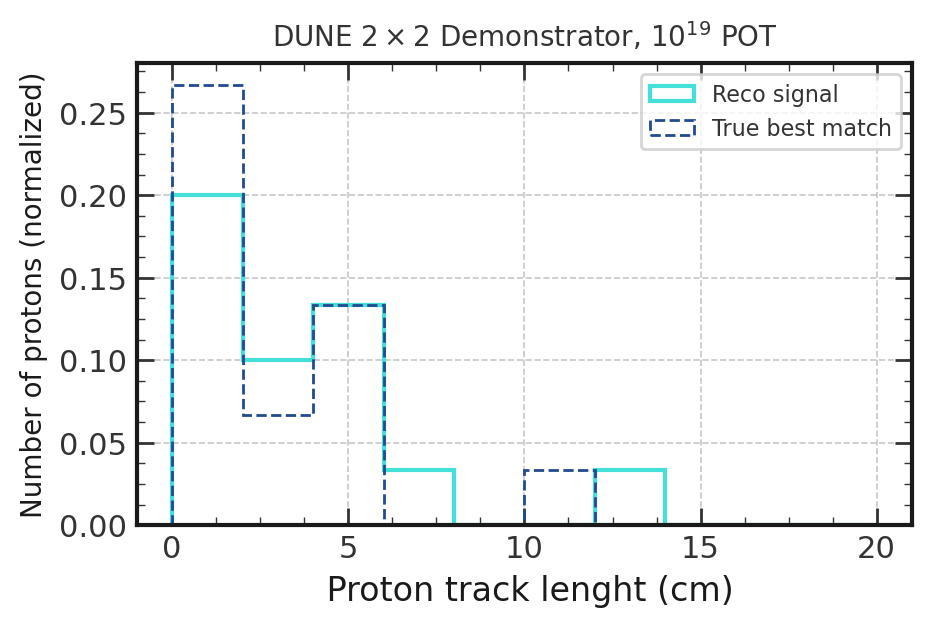

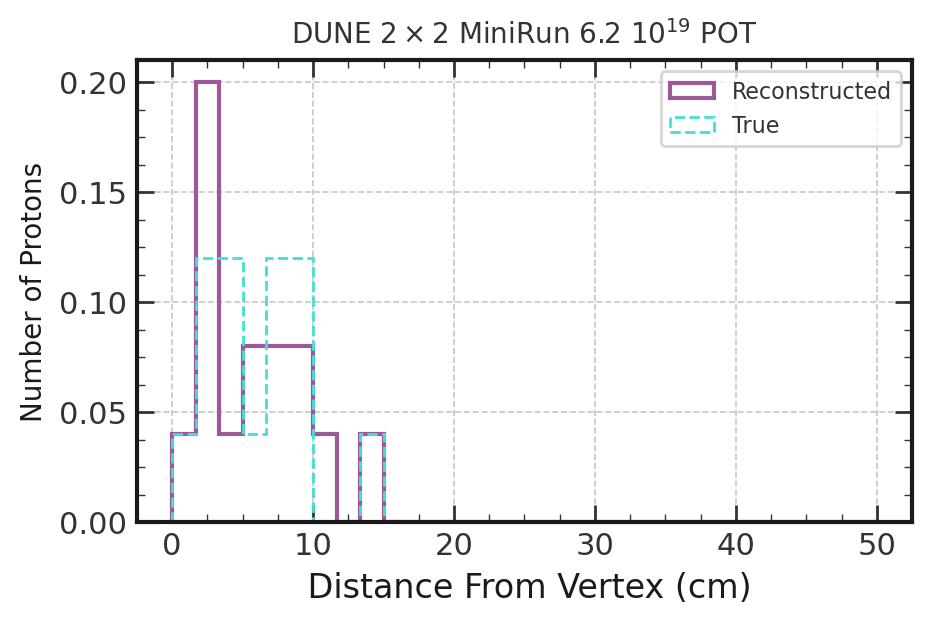

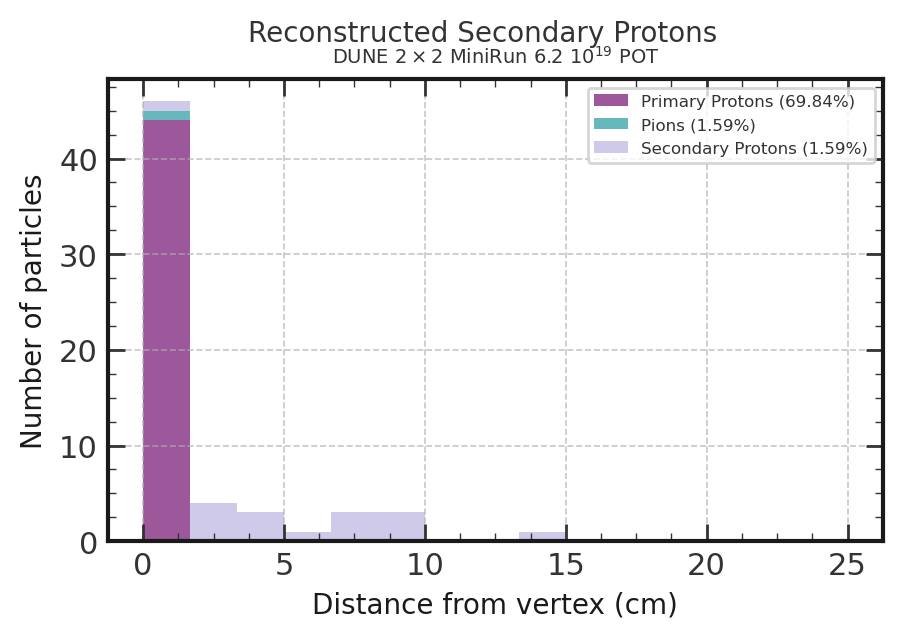

/tmp/ipykernel_800553/329907295.py:202: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  self.pdf.close()


Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 1_2025-02-26.pdf
Interaction Summary:

There are 2555 reconstructed vertices.
There are 1787 reco vertices matching true interaction signal.
There are 5700 true interactions
1: 19.92%
3: 31.12%
4: 38.02%
5: 2.34%
10: 7.03%
0: 1.56%
2: 0.00%

Efficiency: 31.35%
Purity: 69.94%


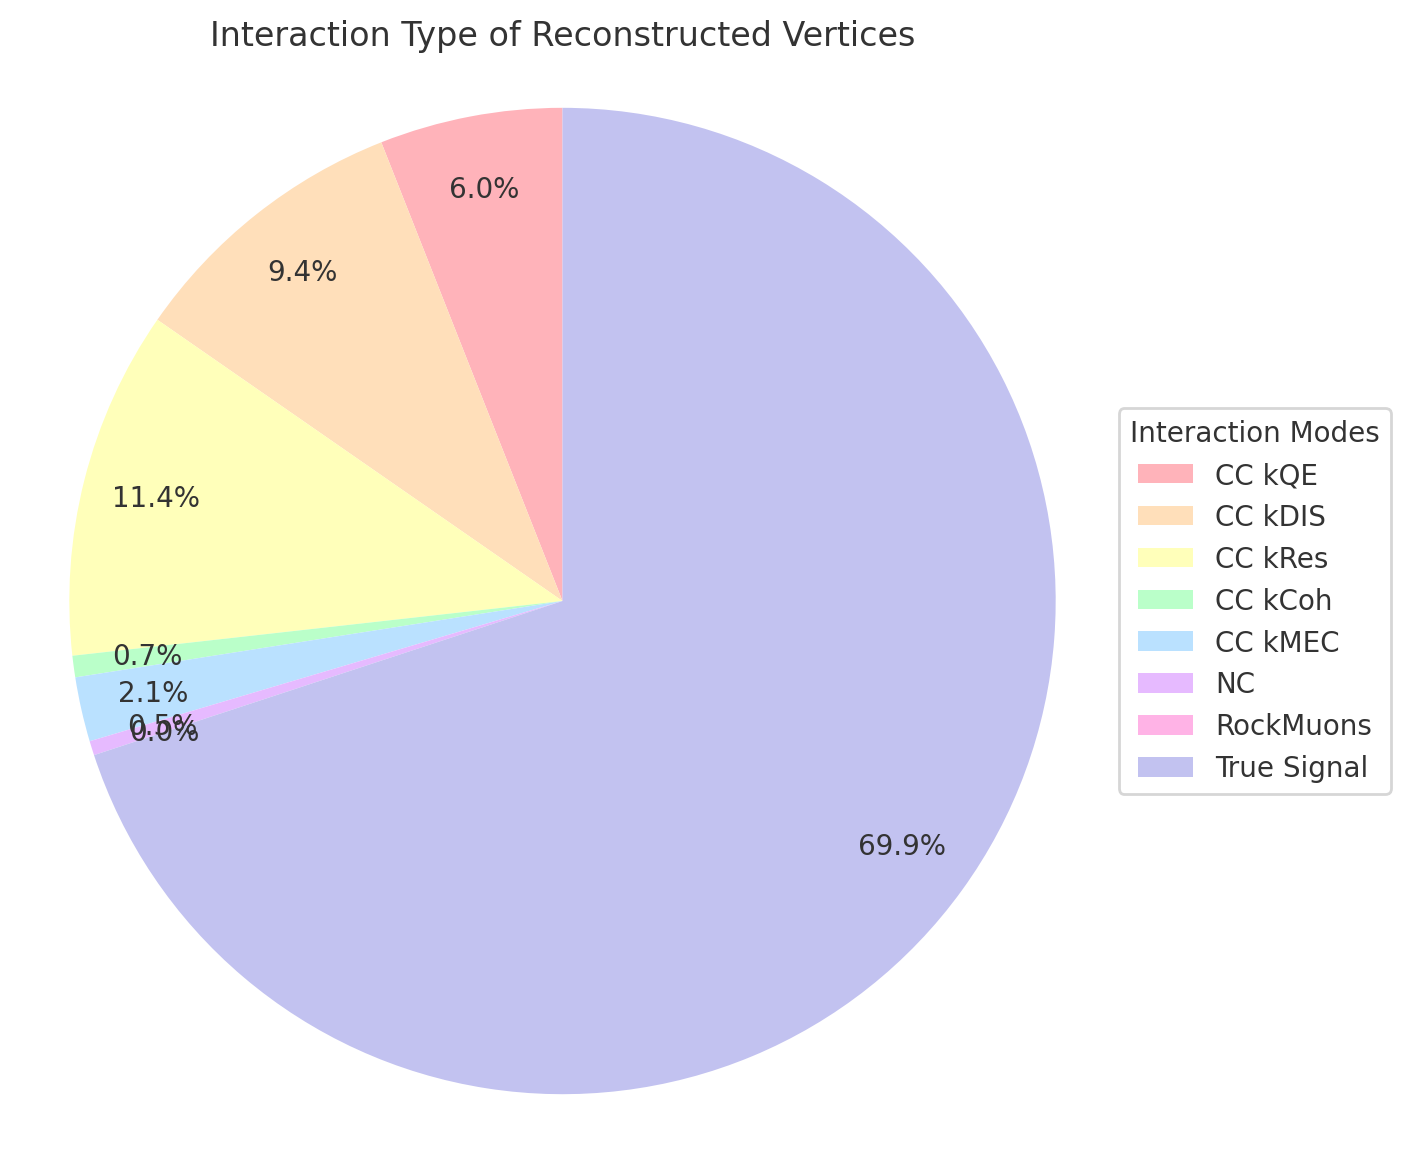

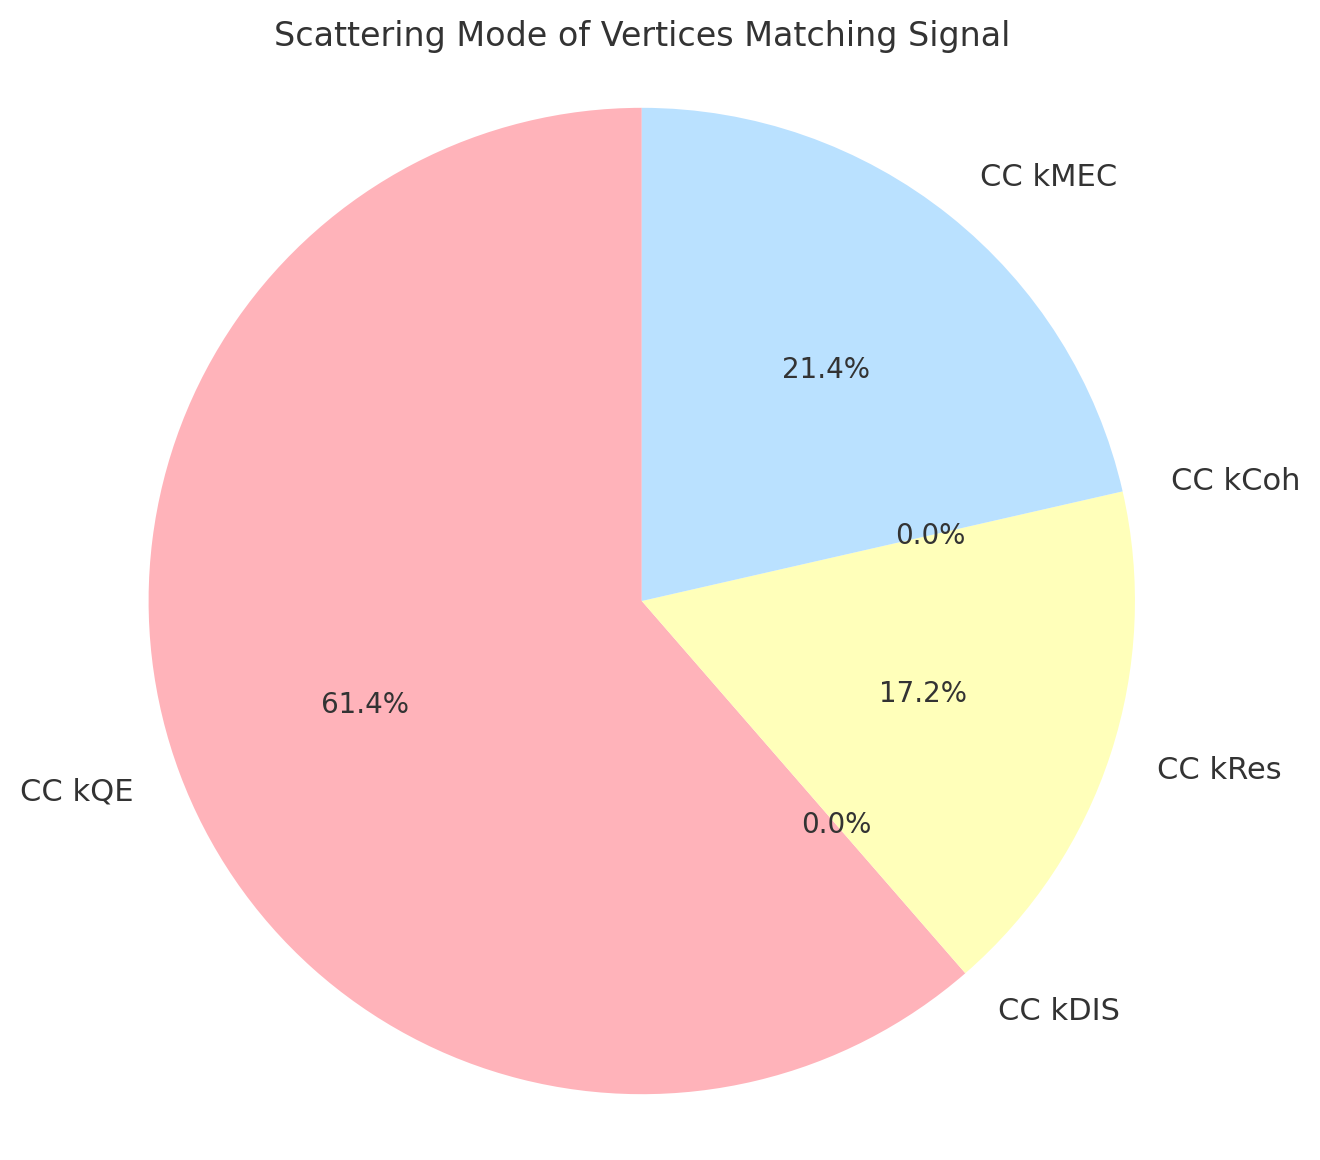

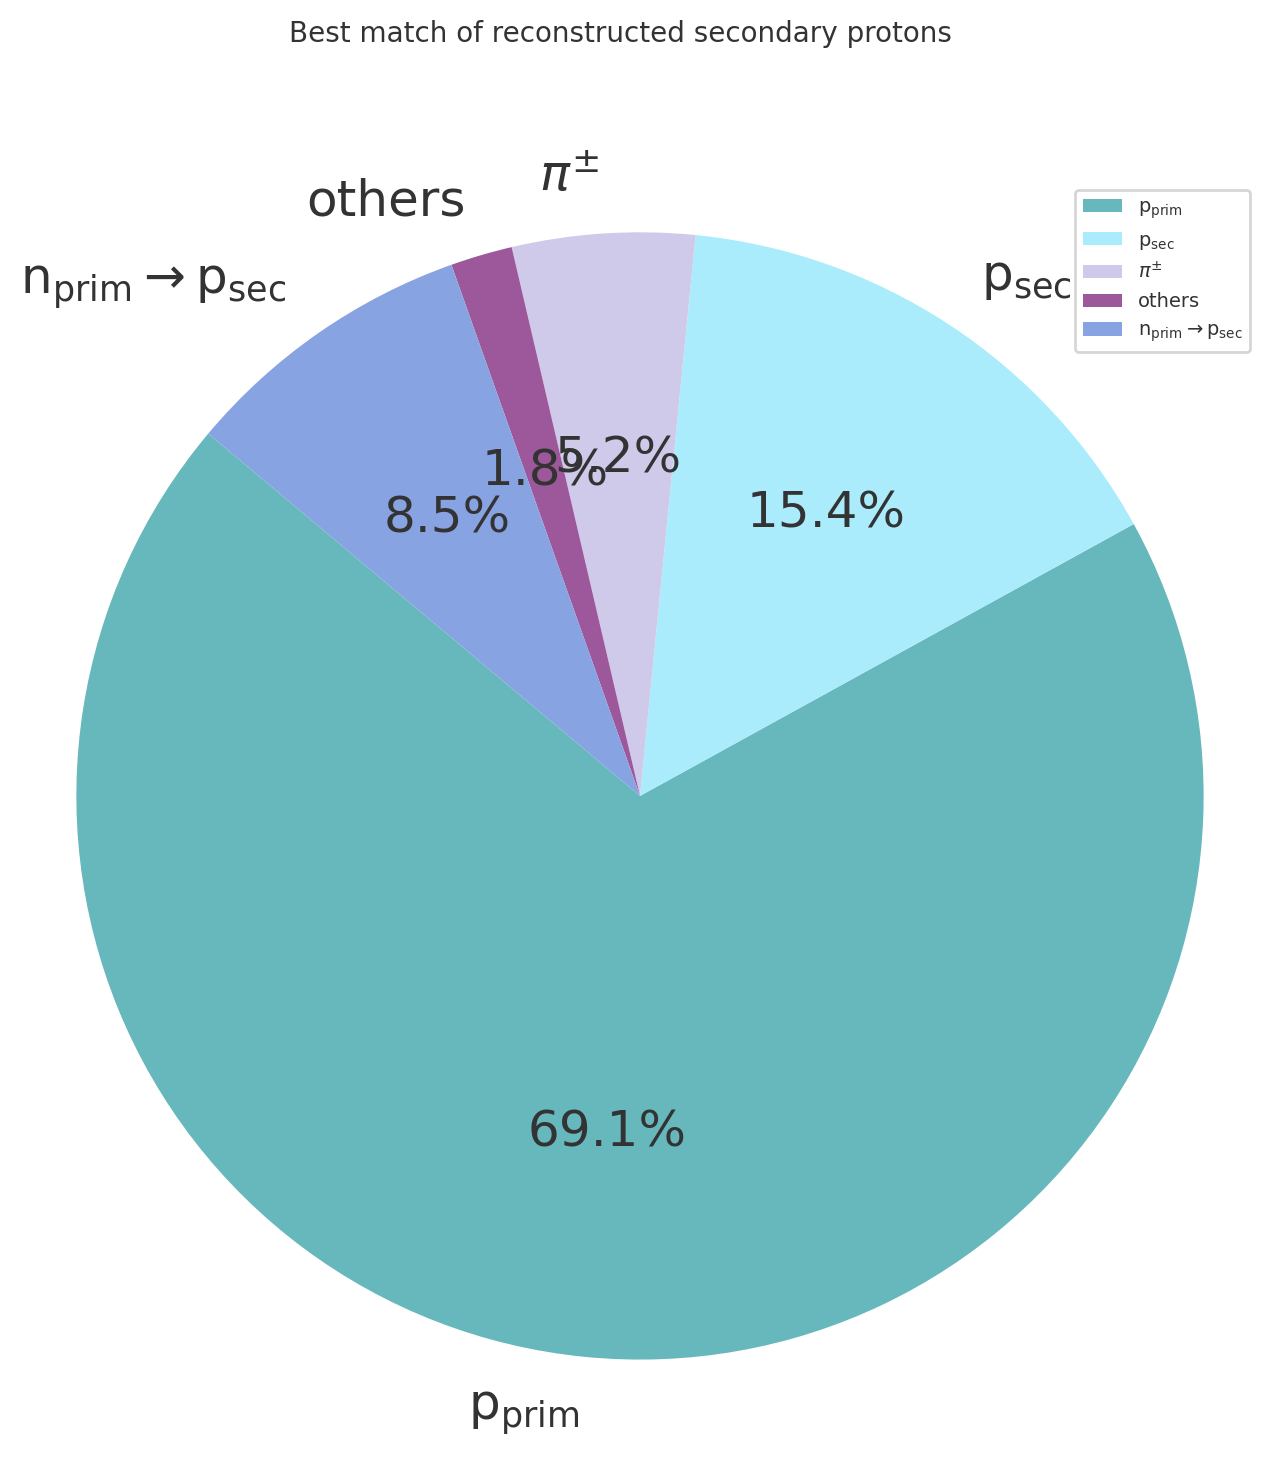

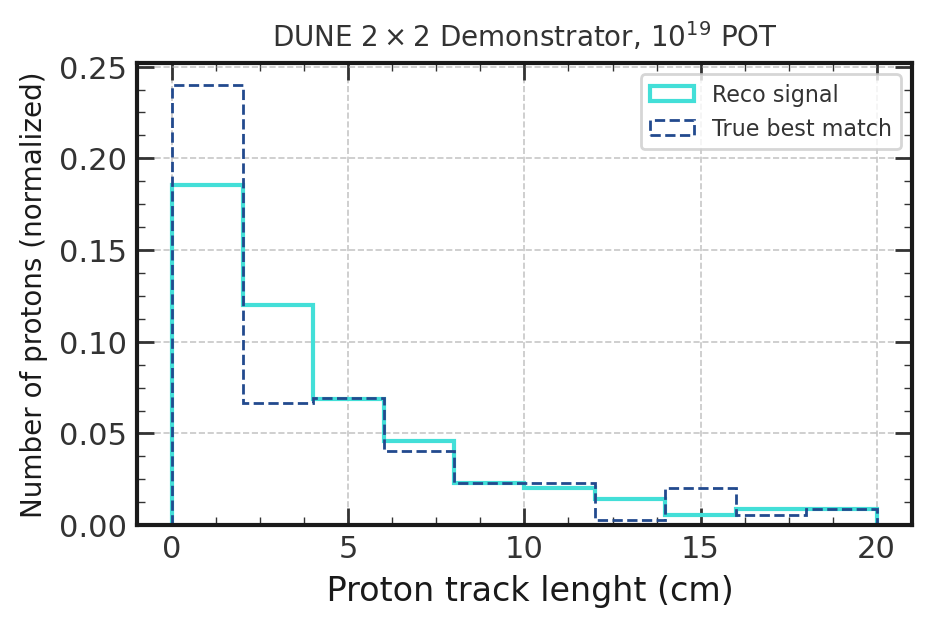

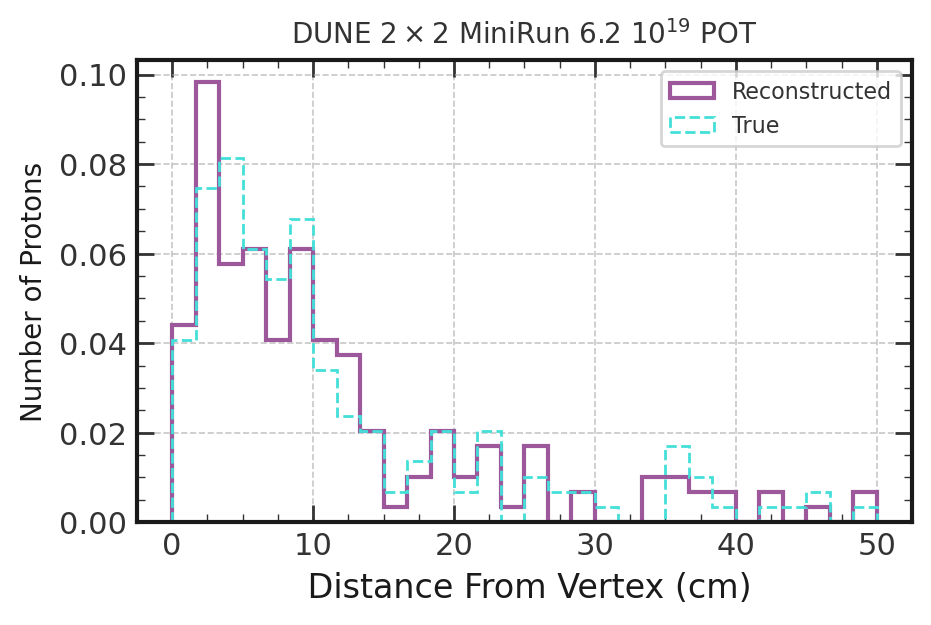

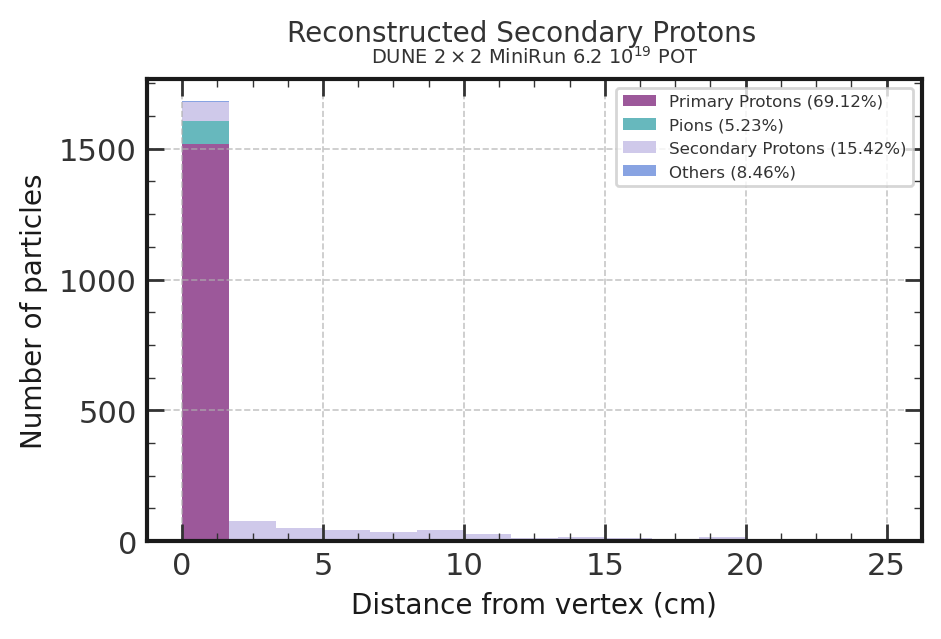

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 2_2025-02-26.pdf
Interaction Summary:

There are 3033 reconstructed vertices.
There are 2184 reco vertices matching true interaction signal.
There are 8550 true interactions
1: 21.32%
3: 29.33%
4: 37.69%
5: 2.71%
10: 7.42%
0: 1.53%
2: 0.00%

Efficiency: 25.54%
Purity: 72.01%


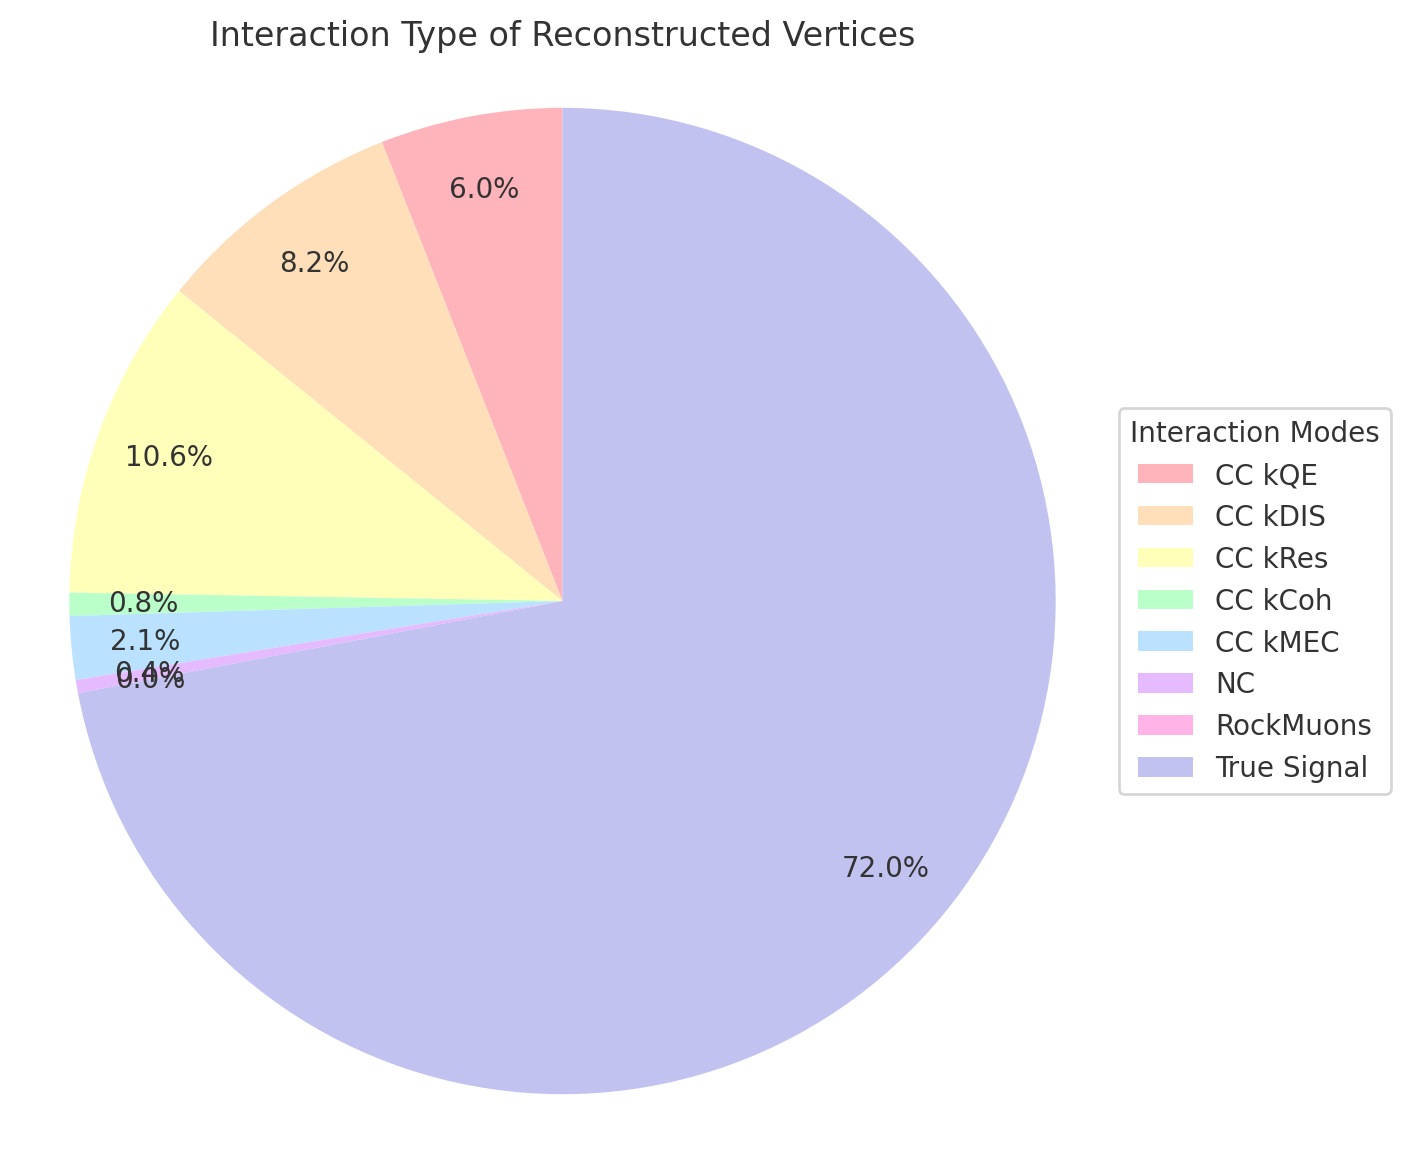

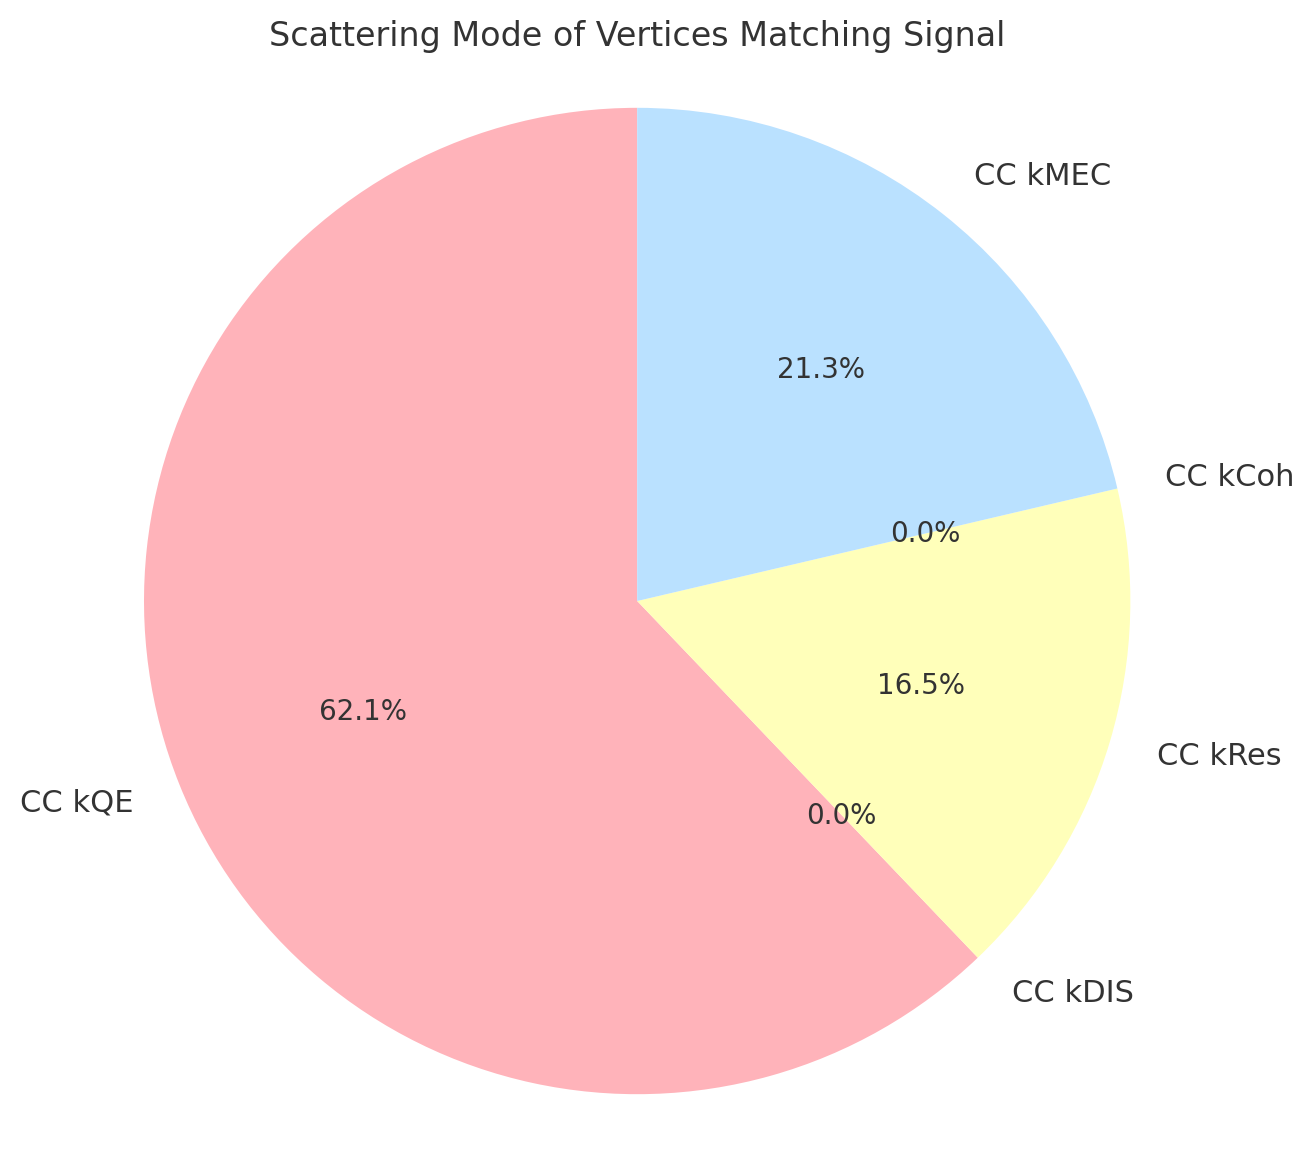

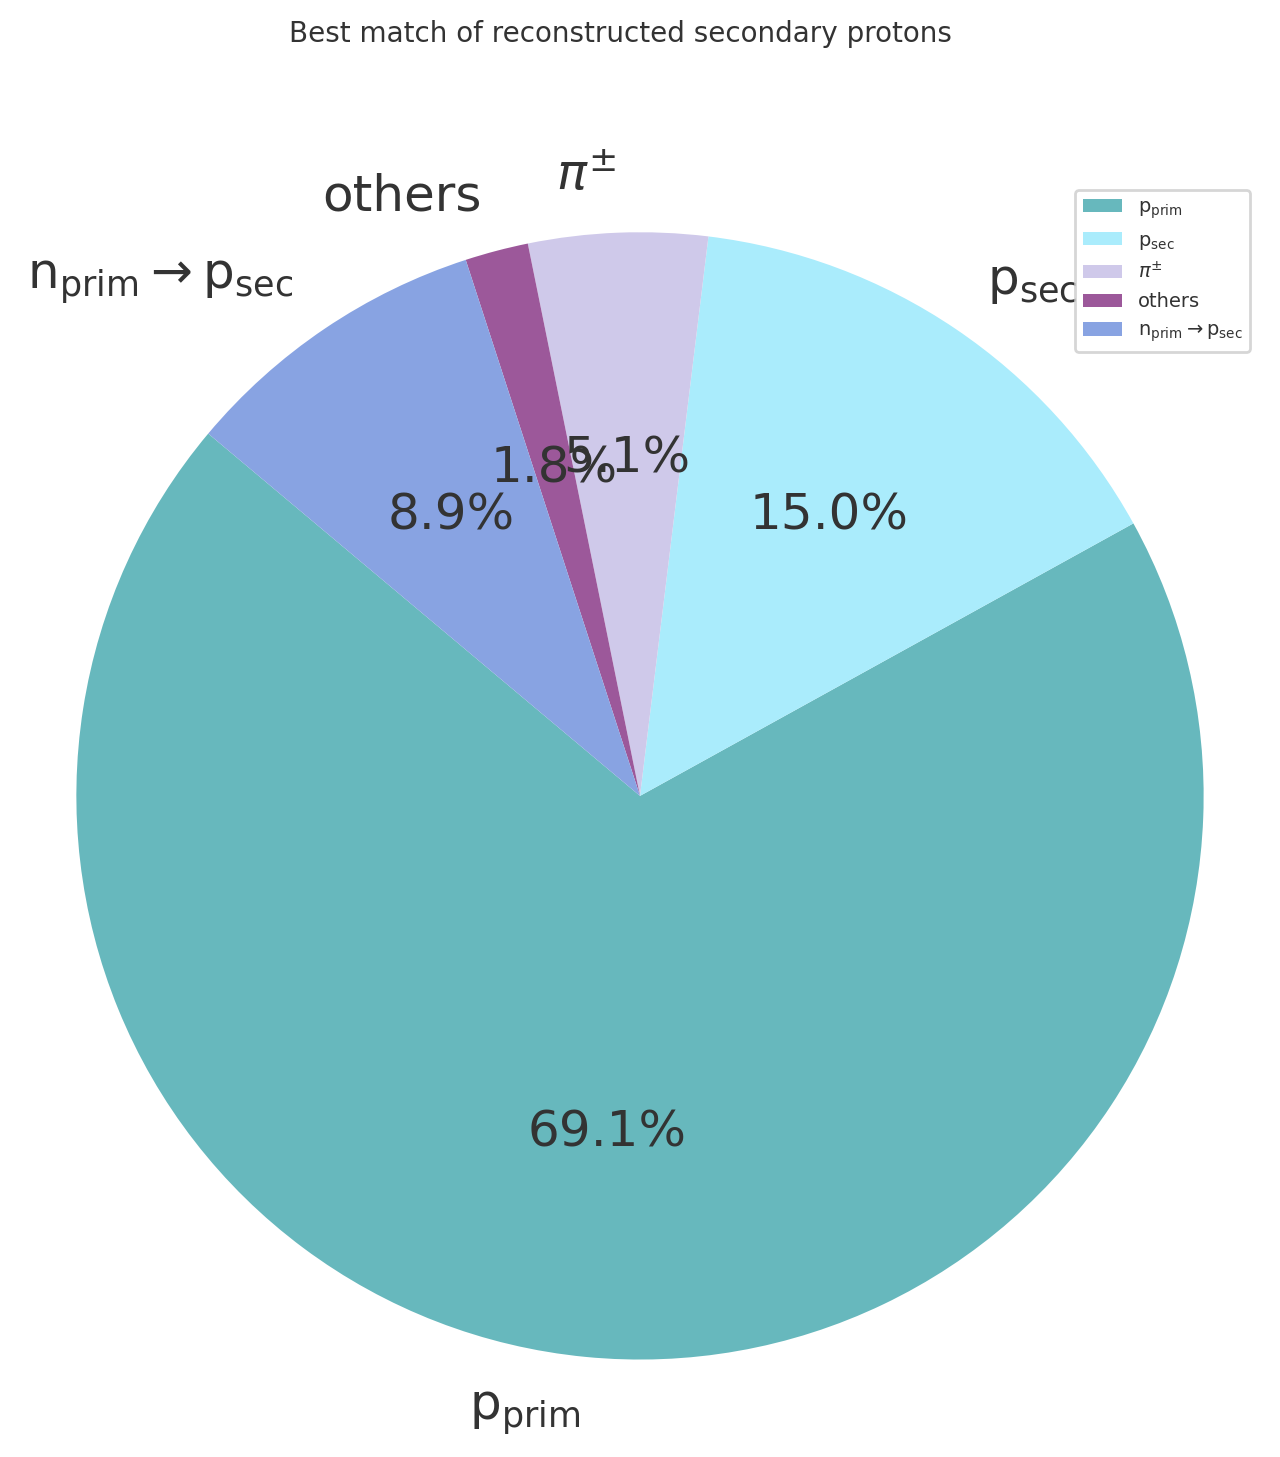

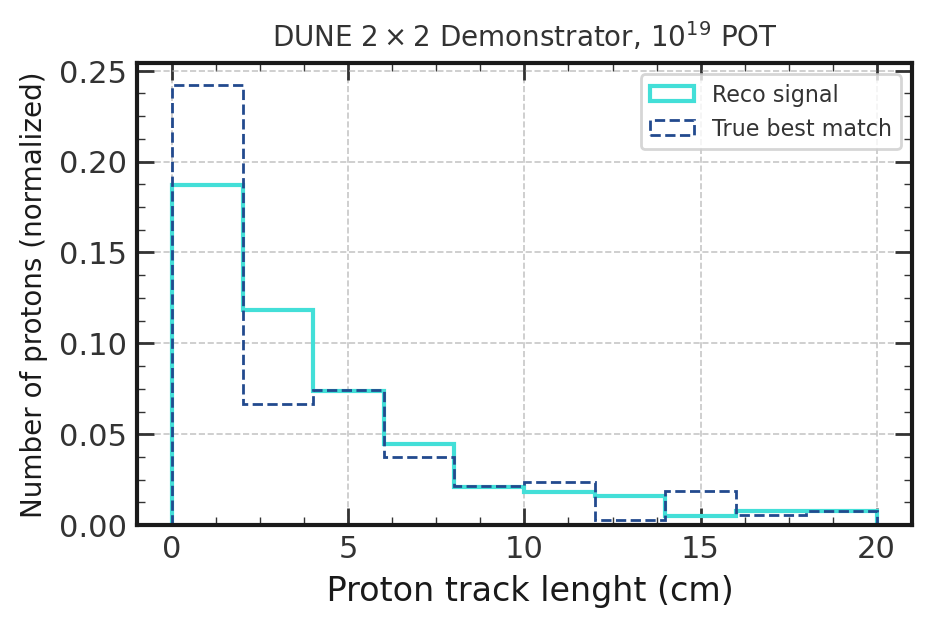

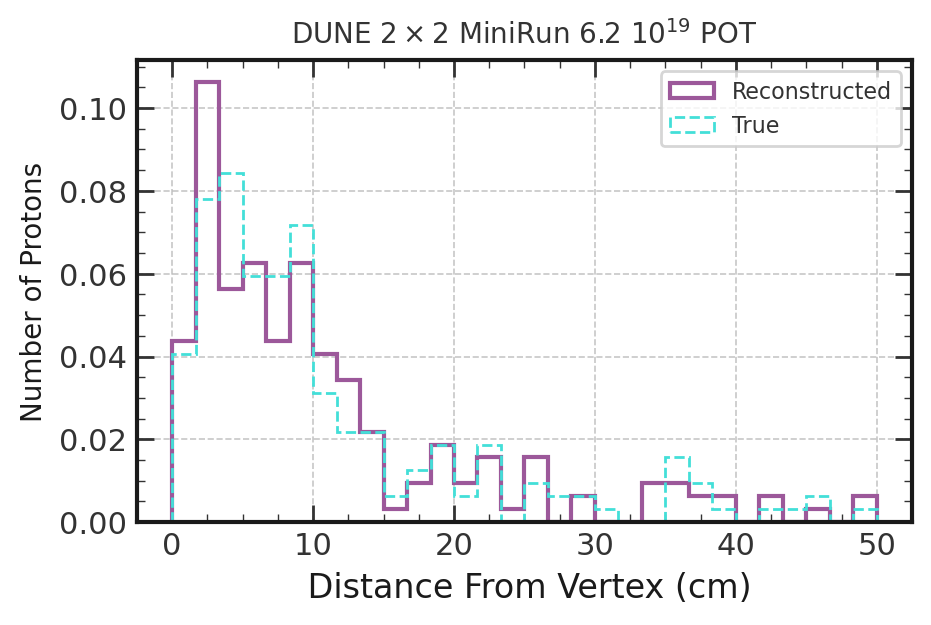

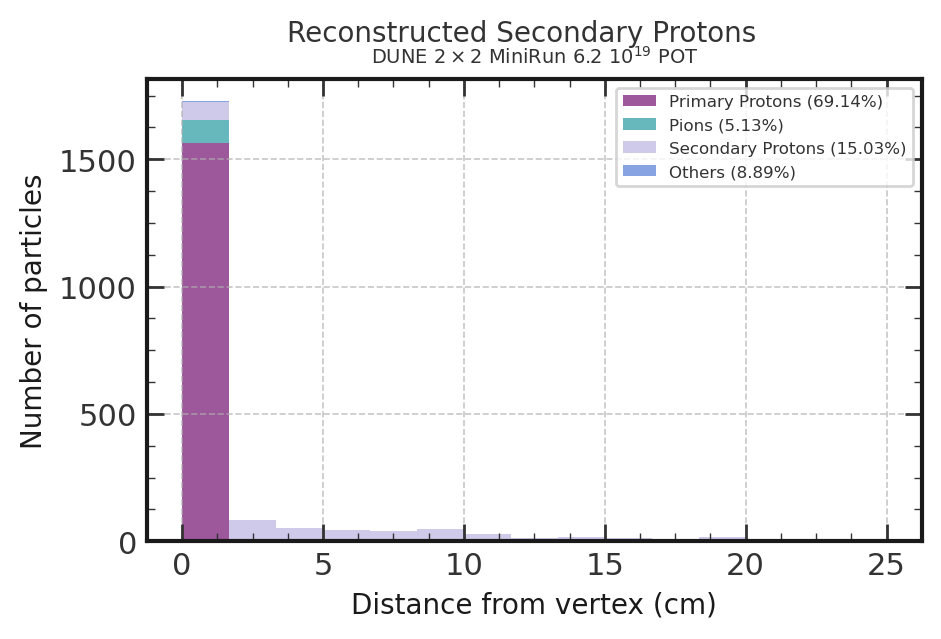

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 1.5_2025-02-26.pdf
Interaction Summary:

There are 5110 reconstructed vertices.
There are 3574 reco vertices matching true interaction signal.
There are 11400 true interactions
1: 19.92%
3: 31.12%
4: 38.02%
5: 2.34%
10: 7.03%
0: 1.56%
2: 0.00%

Efficiency: 31.35%
Purity: 69.94%


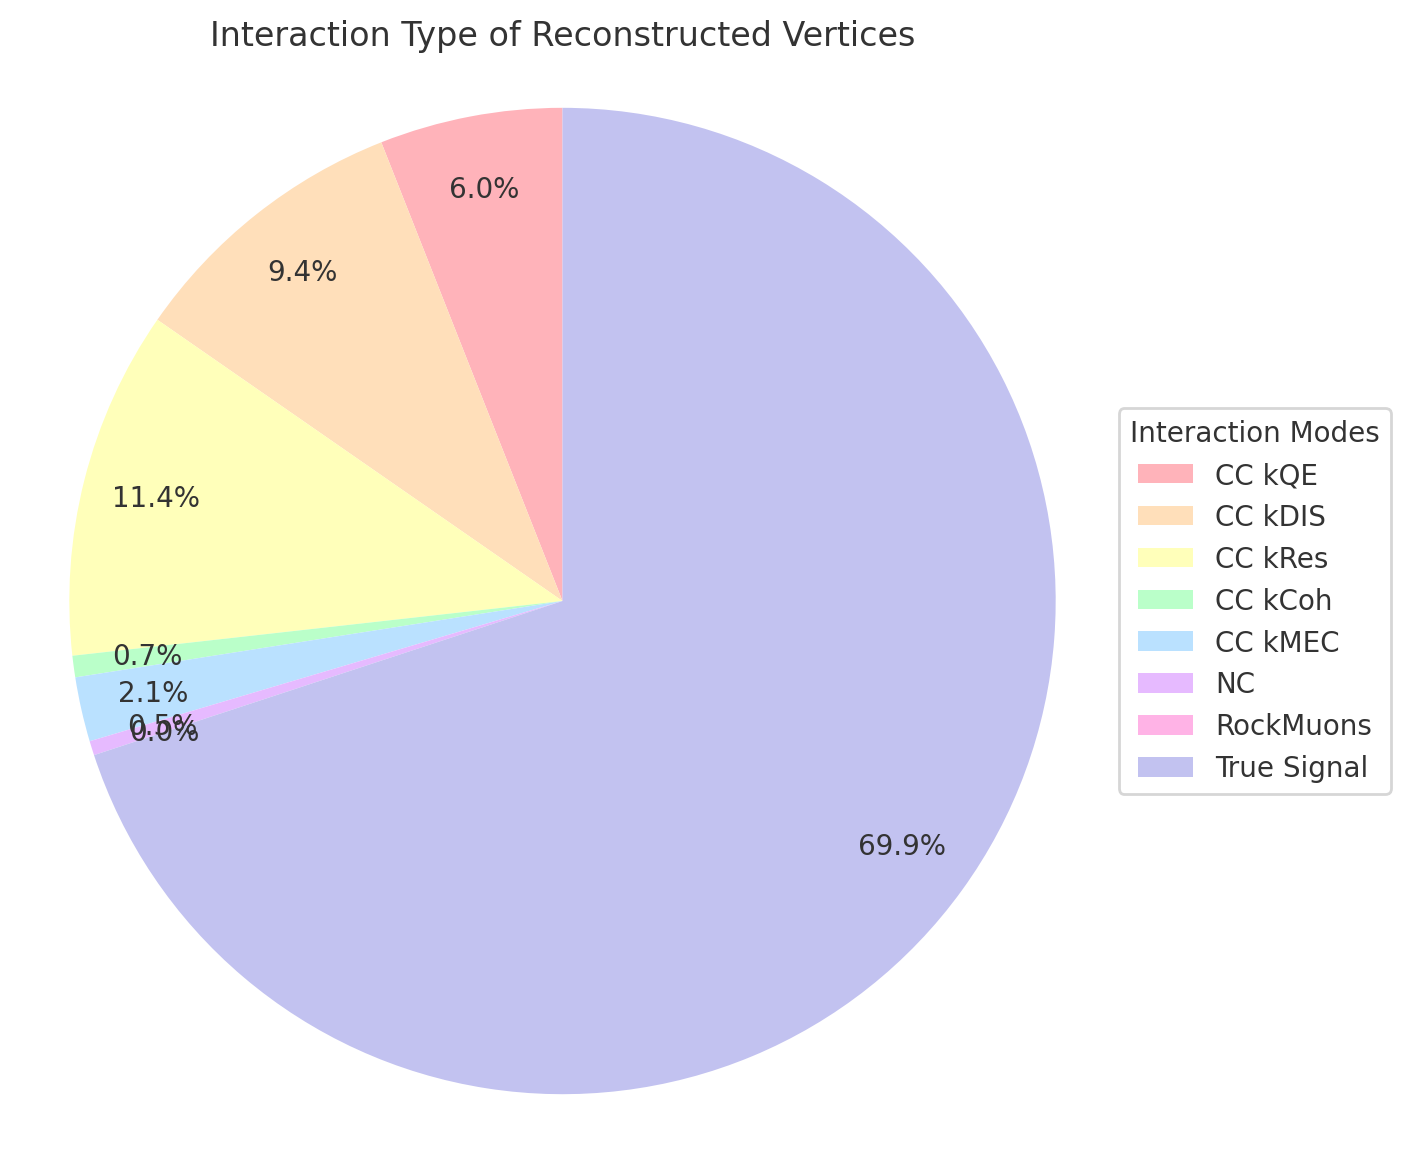

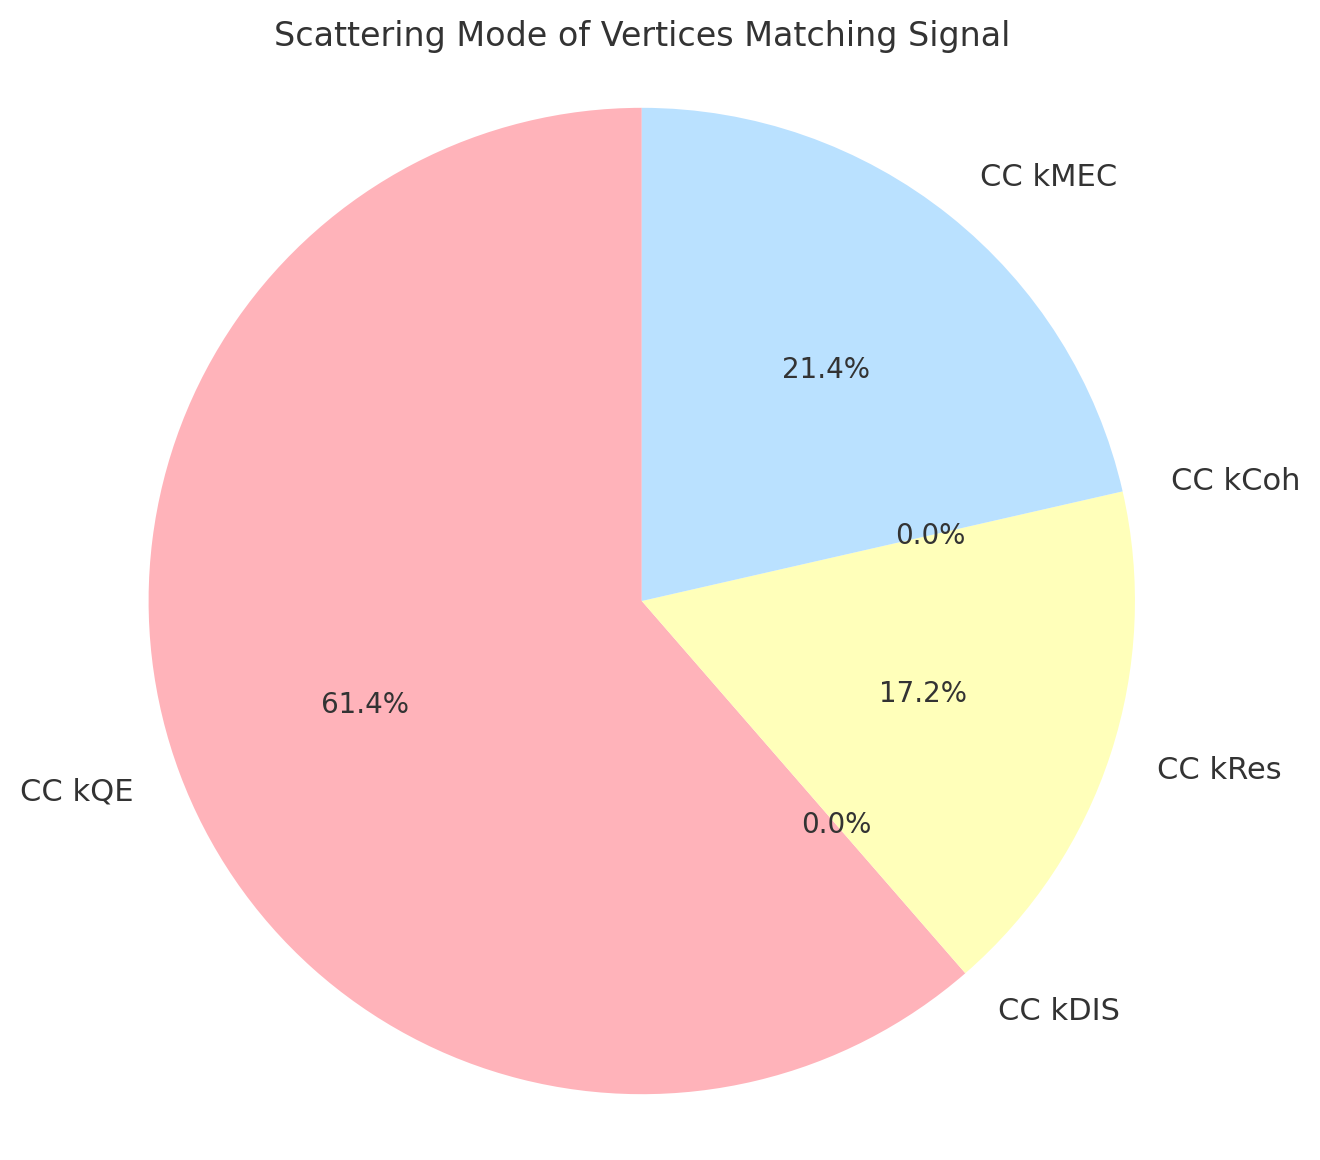

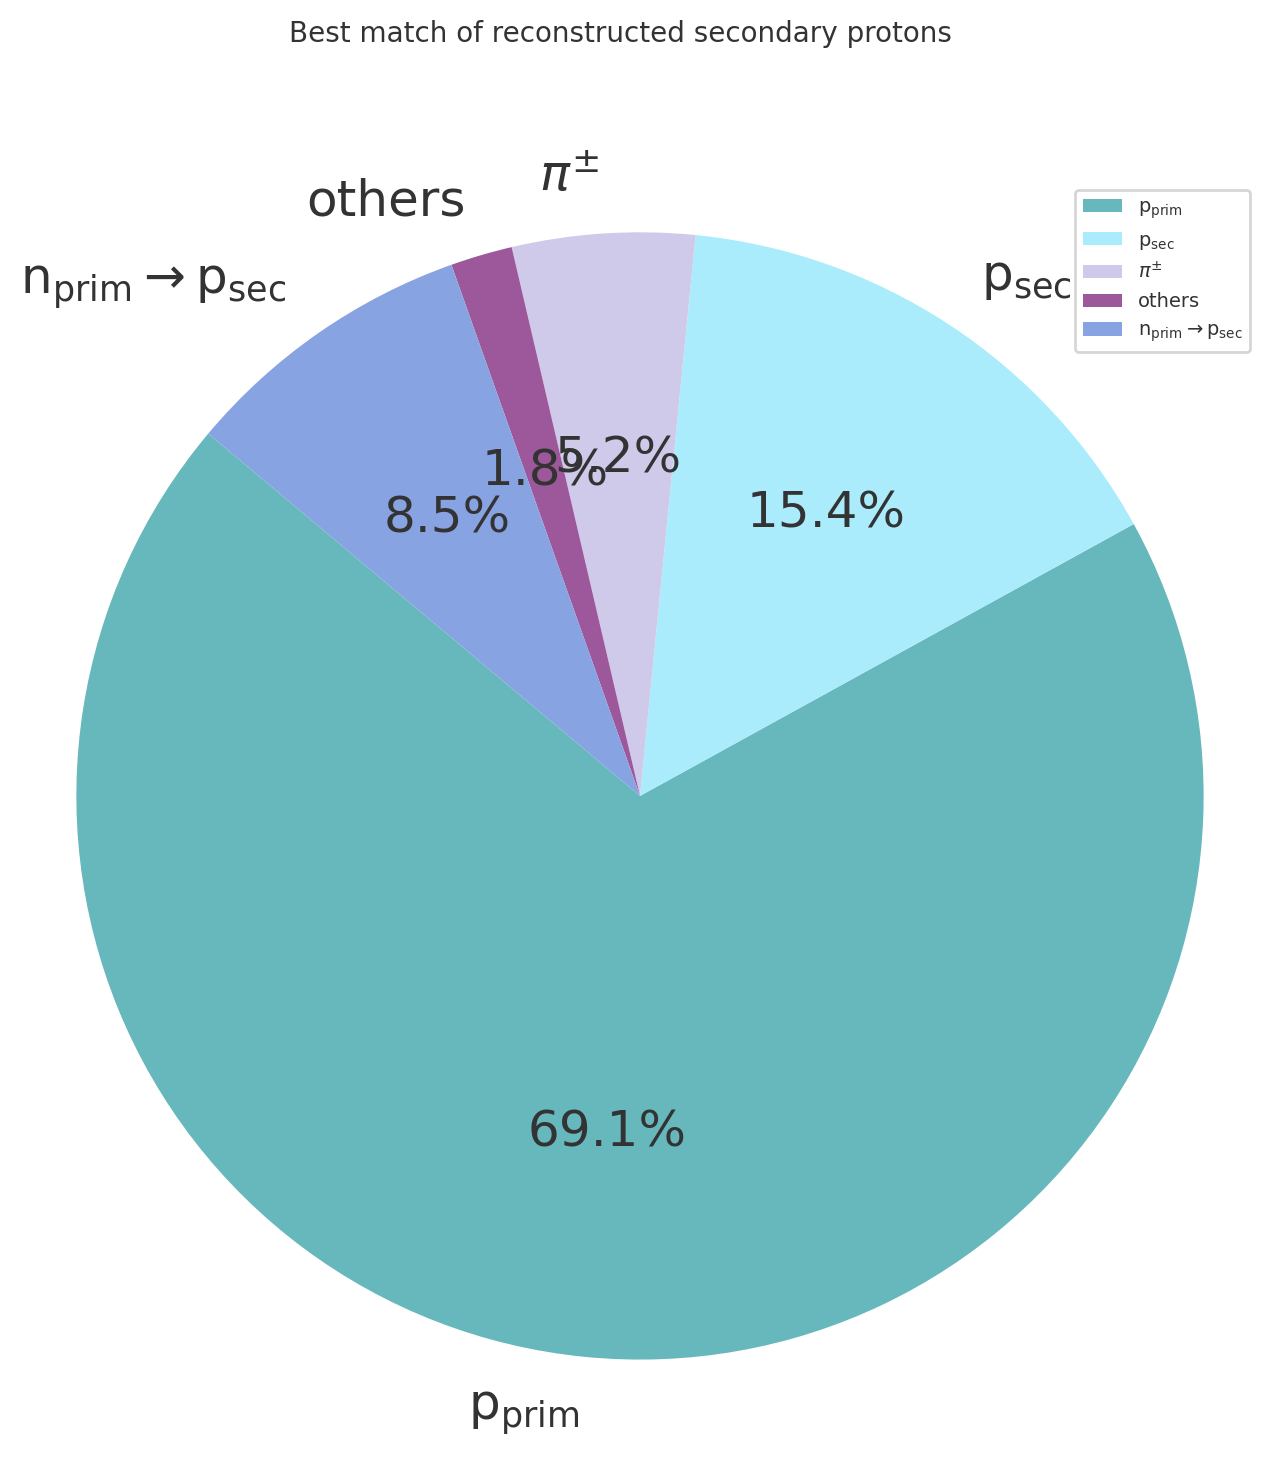

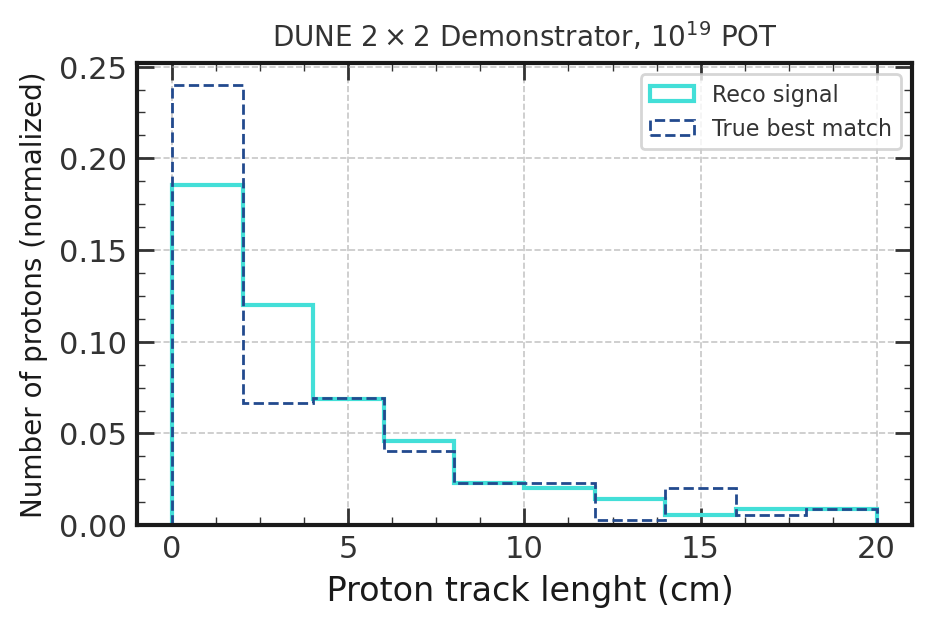

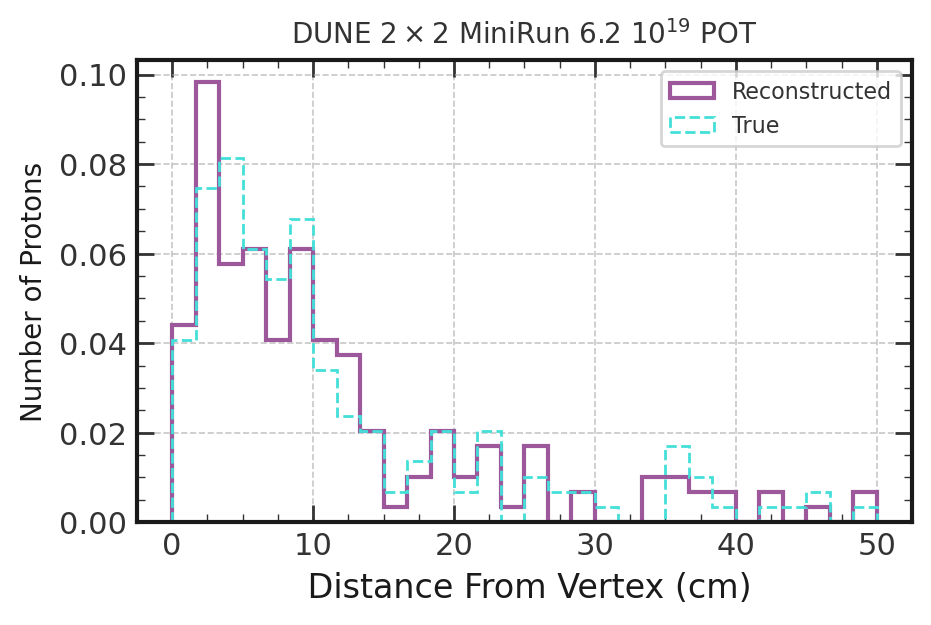

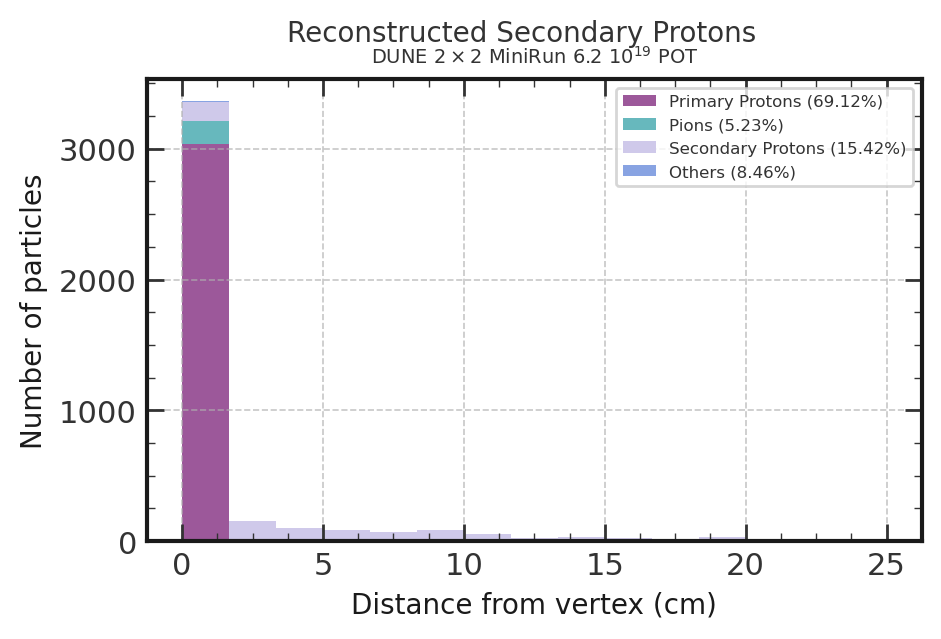

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 2.5_2025-02-26.pdf
Interaction Summary:

There are 13784 reconstructed vertices.
There are 11577 reco vertices matching true interaction signal.
There are 24046 true interactions
1: 16.36%
3: 36.29%
4: 32.26%
5: 1.90%
10: 5.98%
0: 7.20%
2: 0.00%

Efficiency: 48.15%
Purity: 83.99%


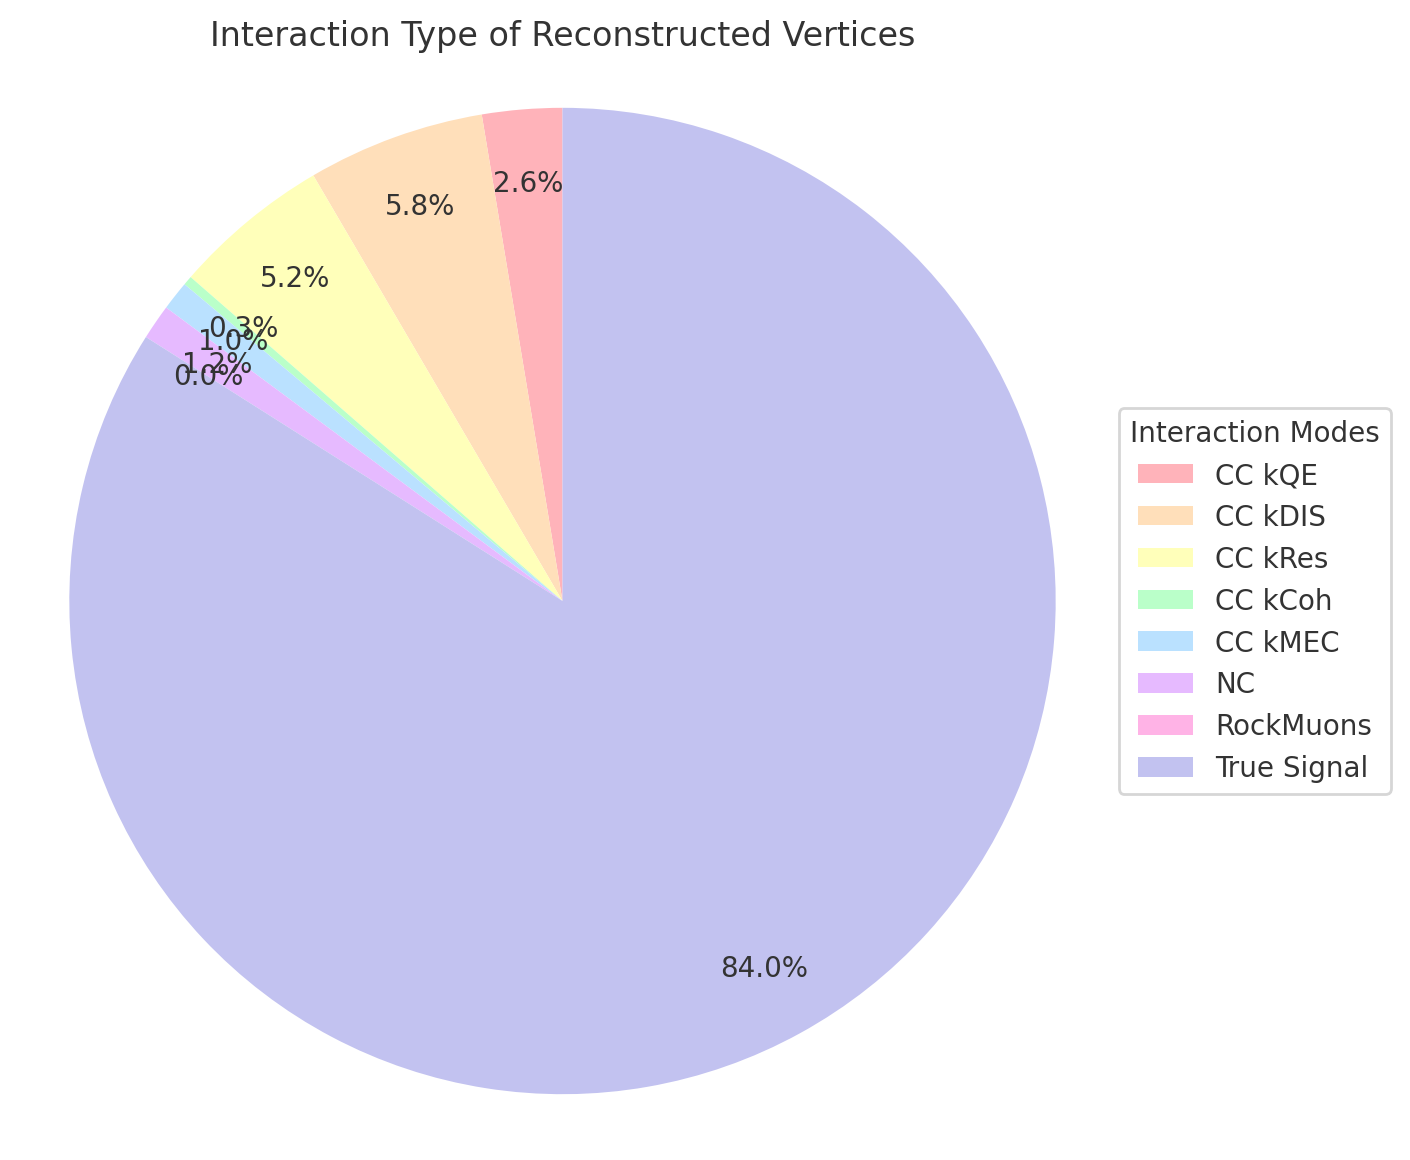

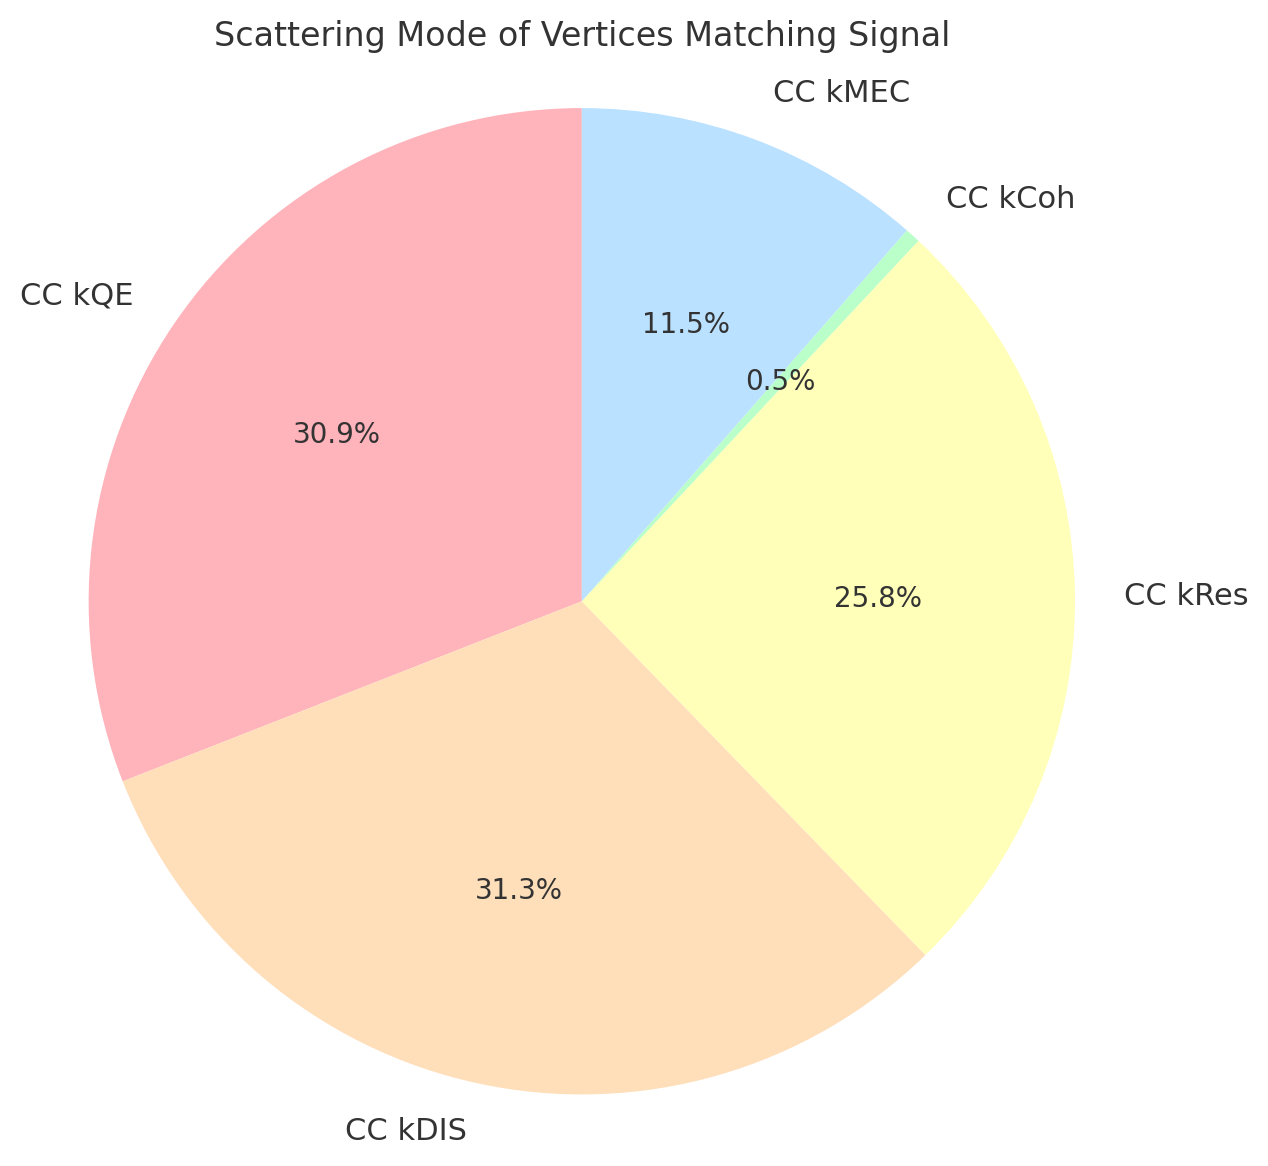

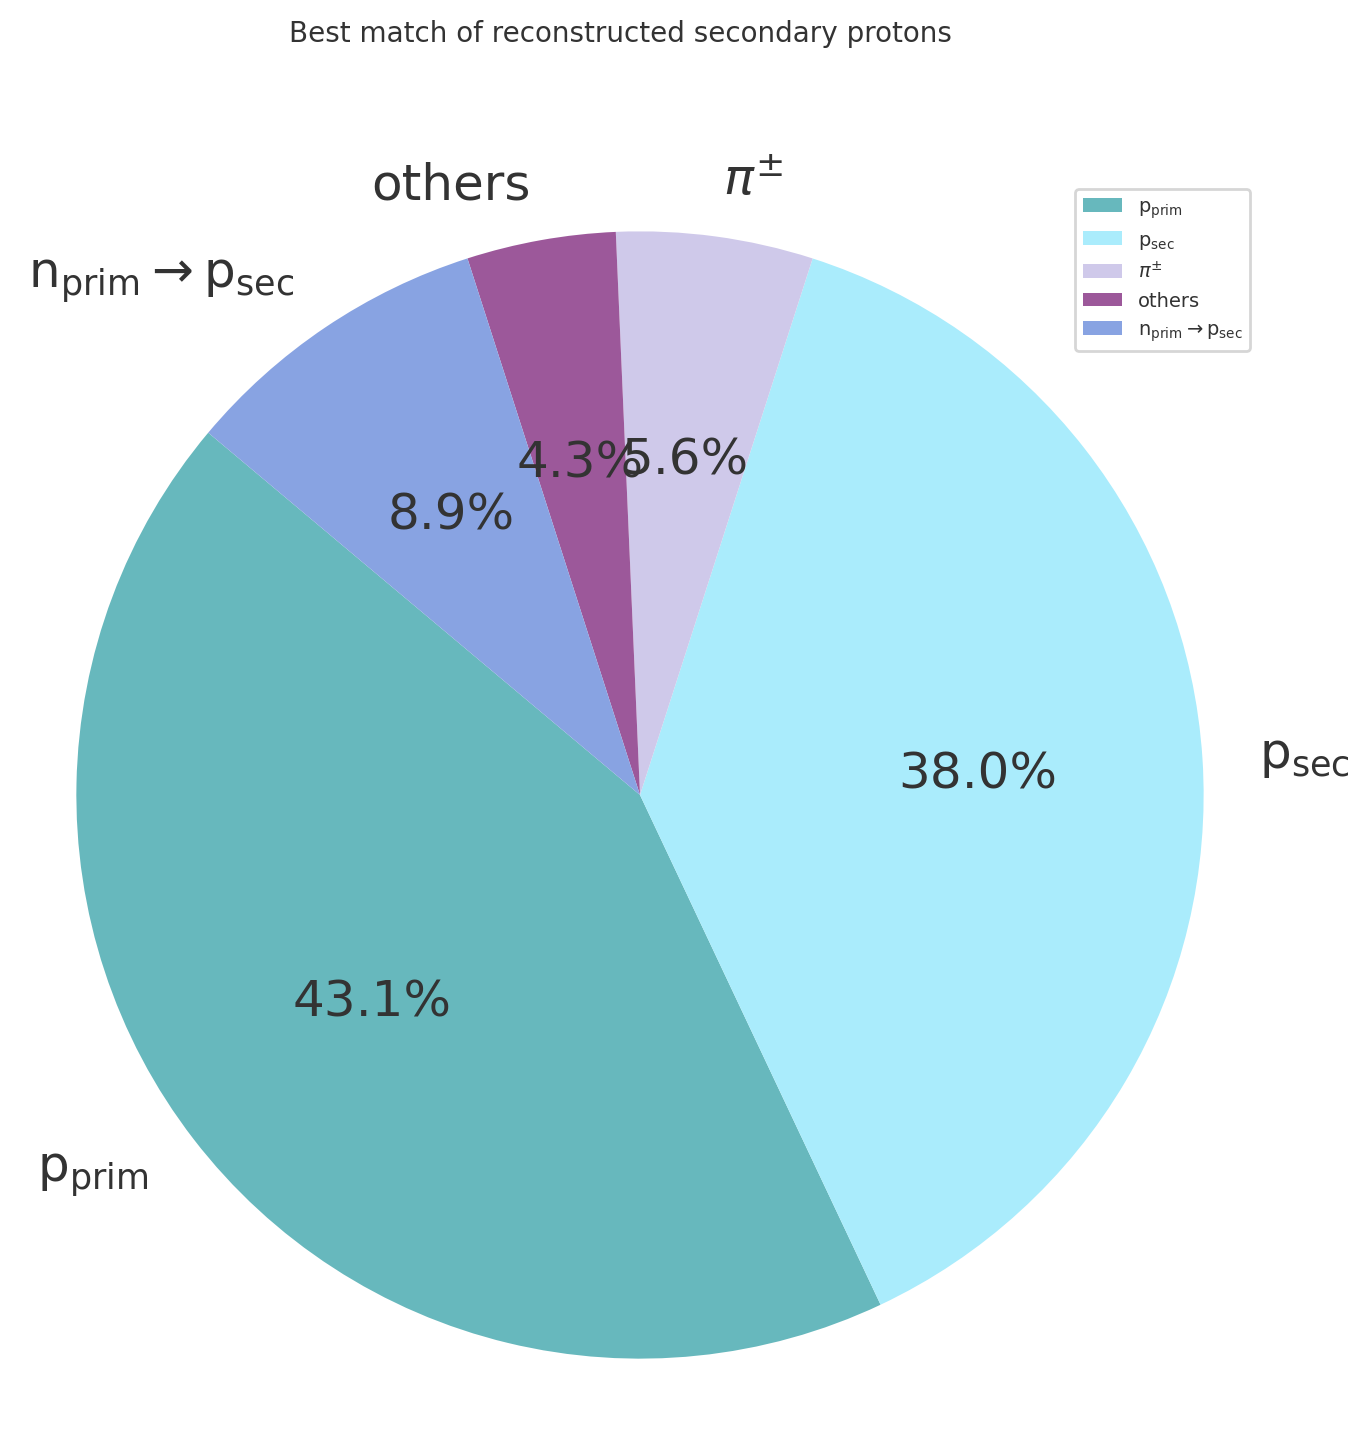

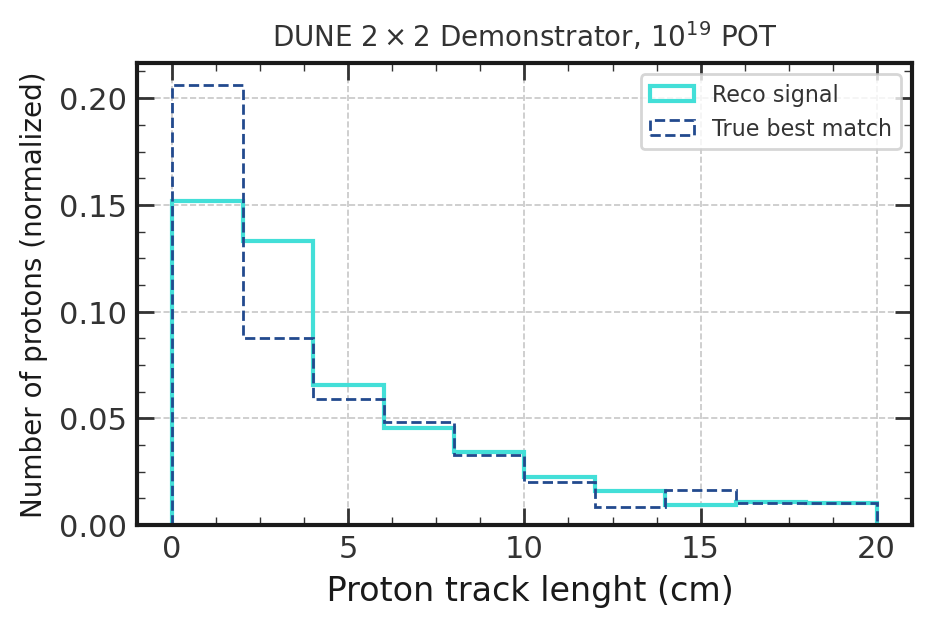

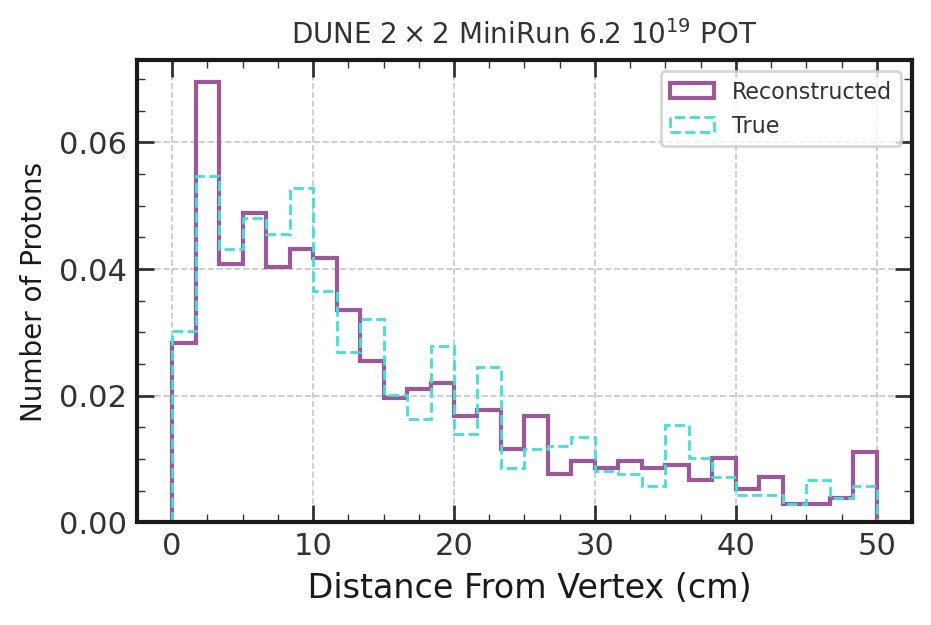

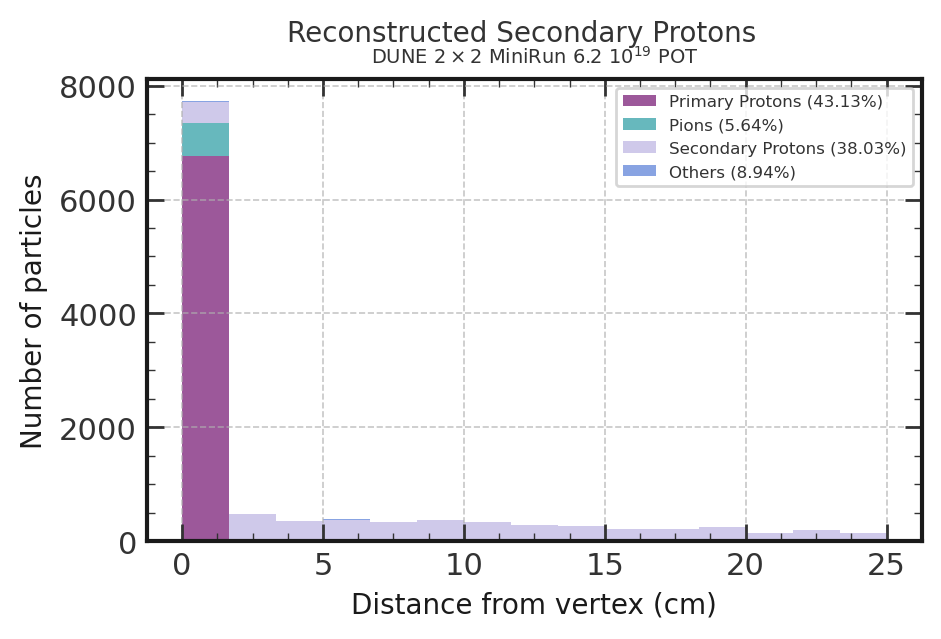

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 3_2025-02-26.pdf
Interaction Summary:

There are 22458 reconstructed vertices.
There are 19580 reco vertices matching true interaction signal.
There are 36692 true interactions
1: 14.45%
3: 39.05%
4: 29.19%
5: 1.67%
10: 5.42%
0: 10.22%
2: 0.00%

Efficiency: 53.36%
Purity: 87.18%


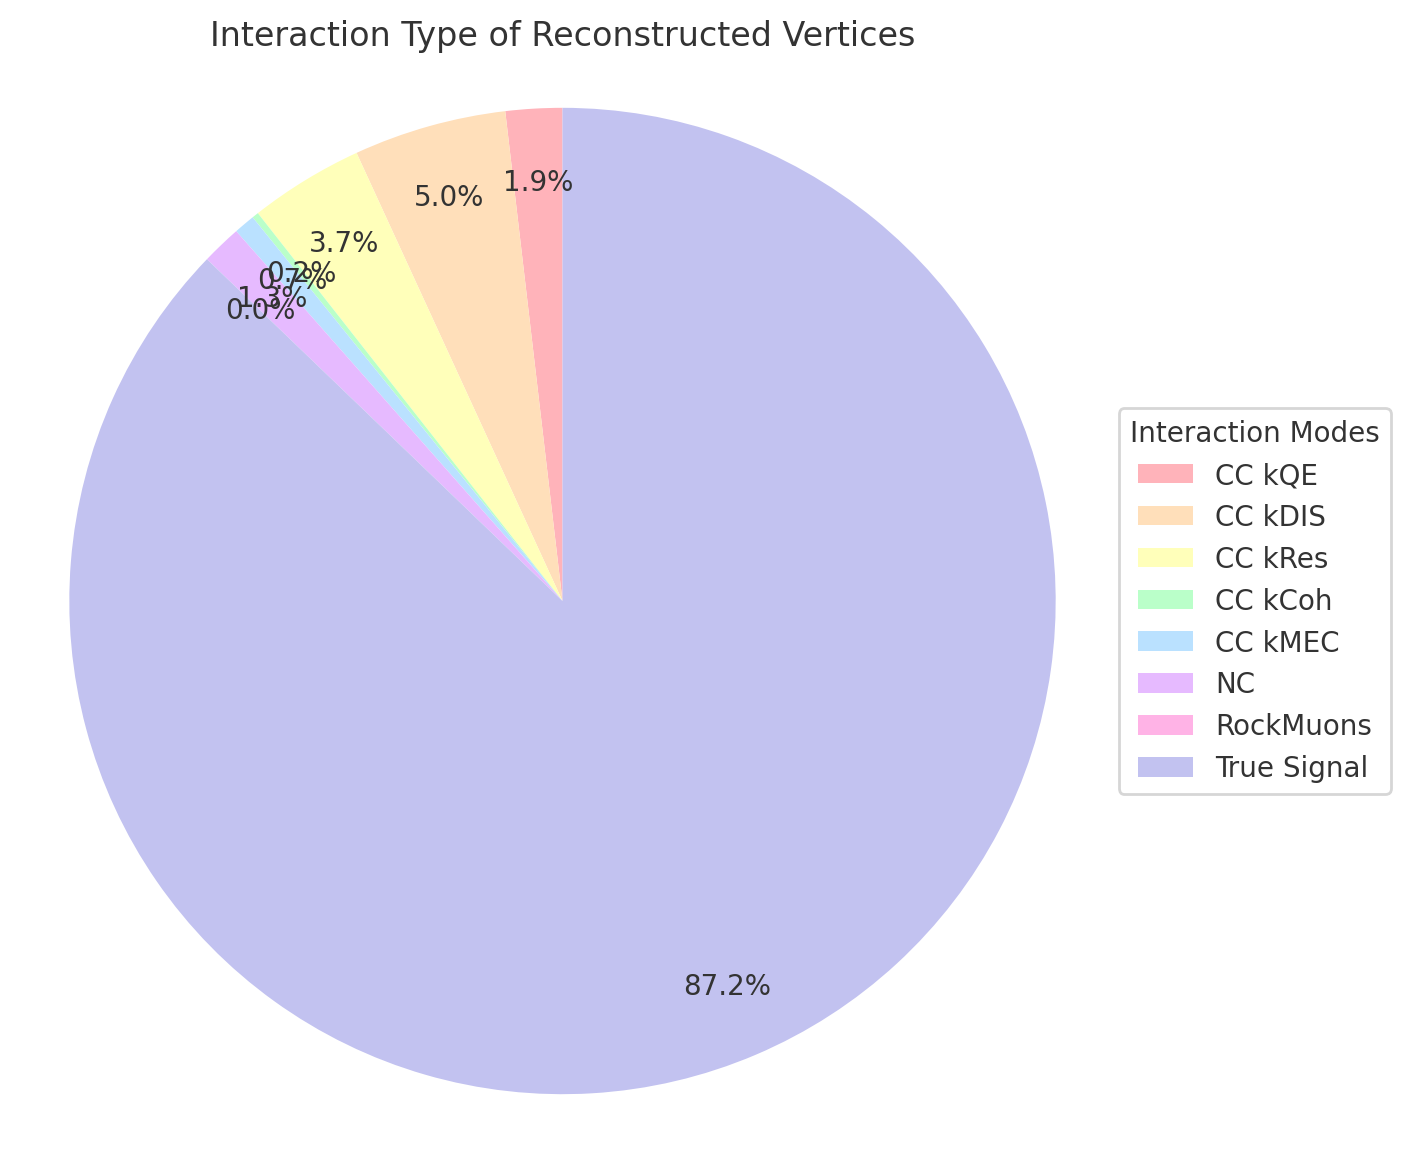

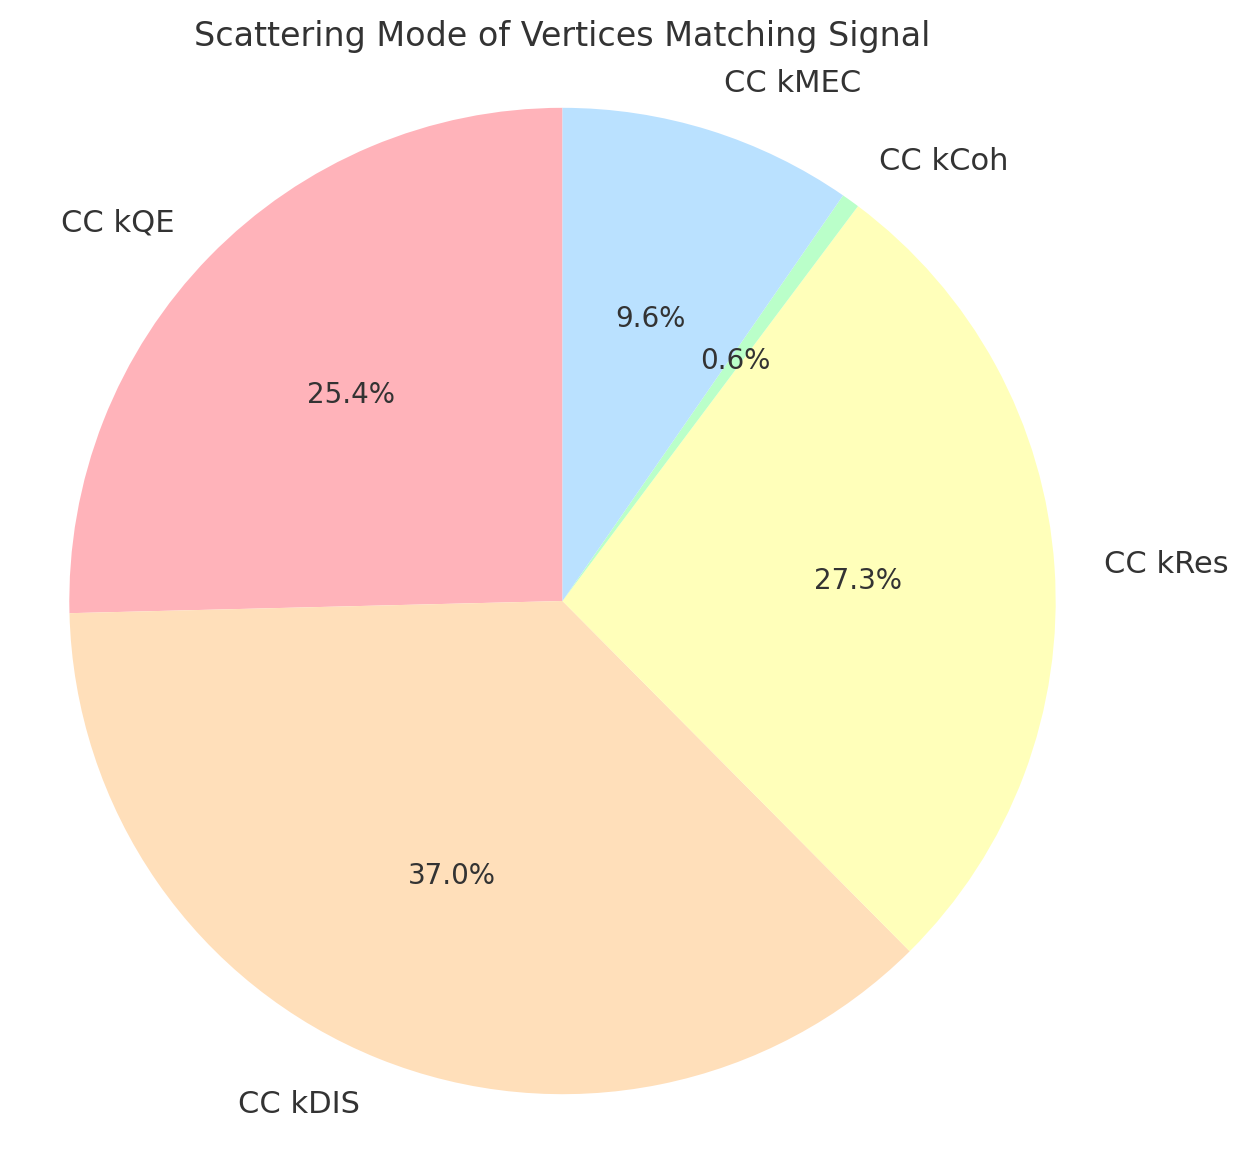

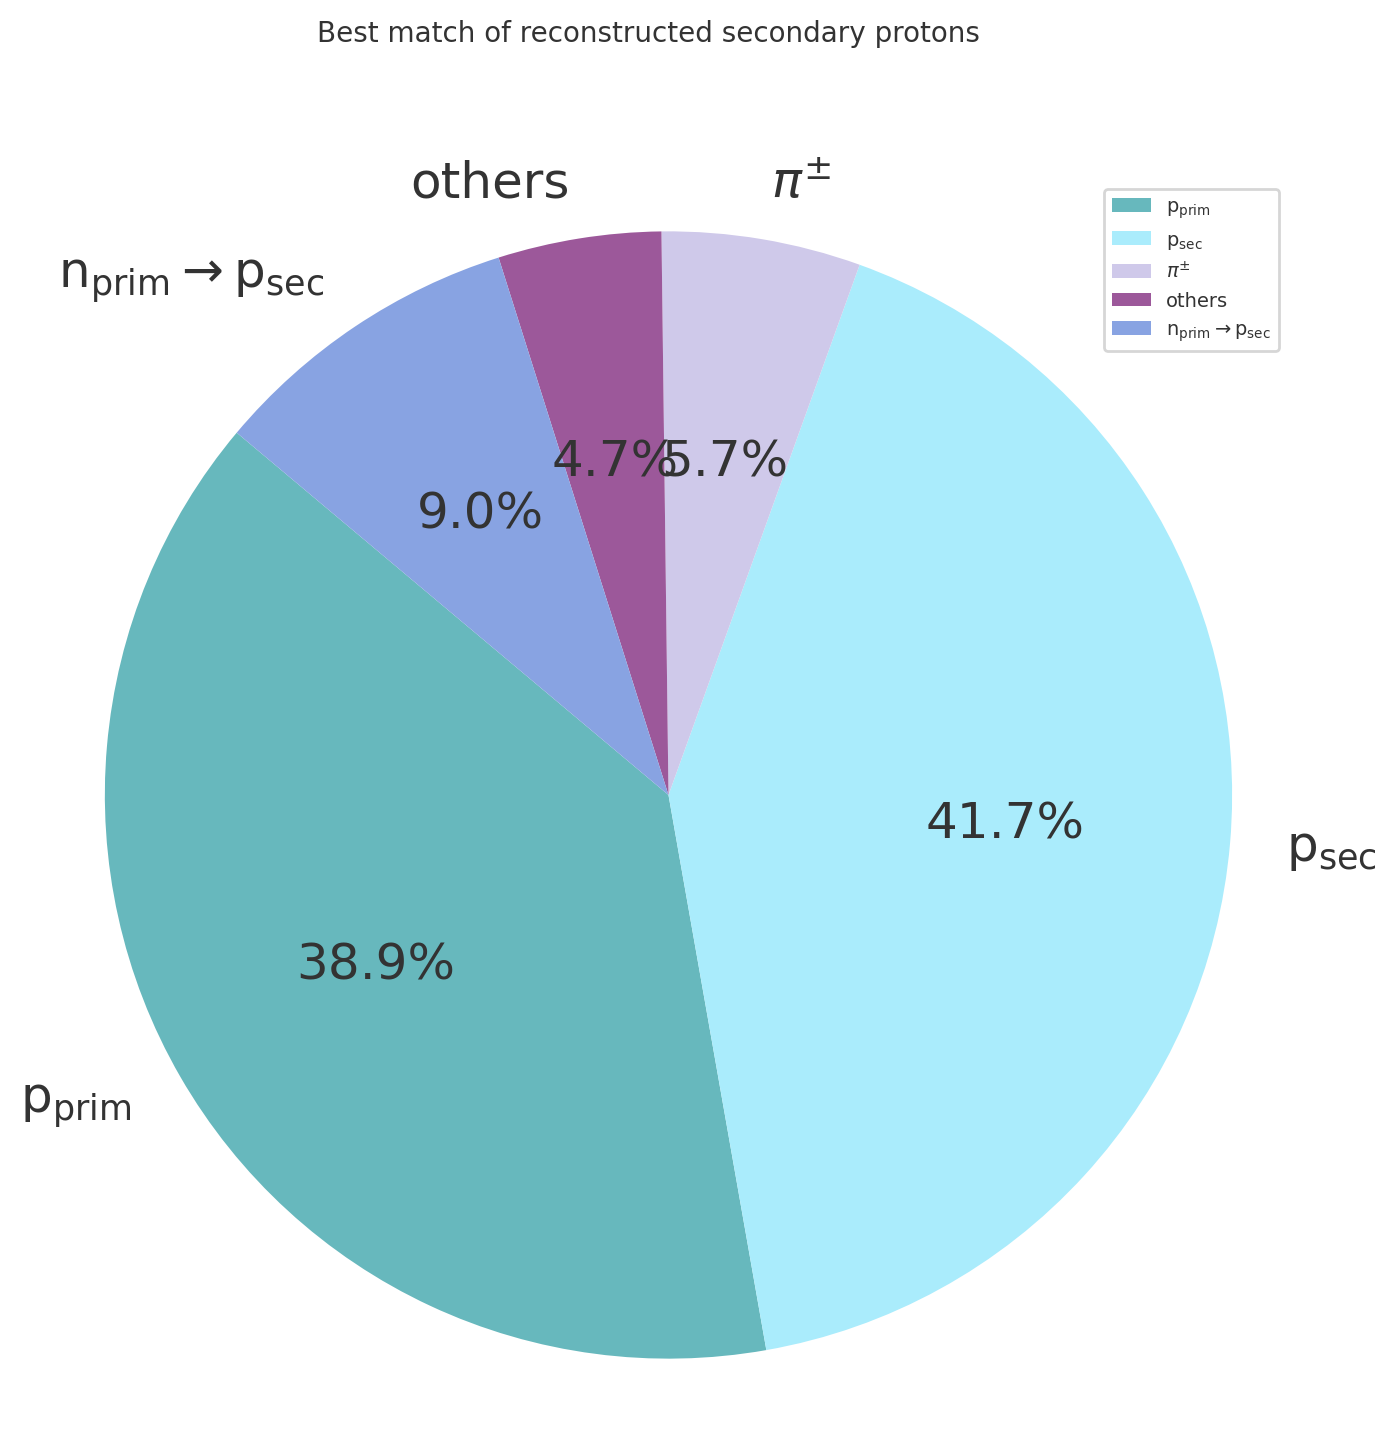

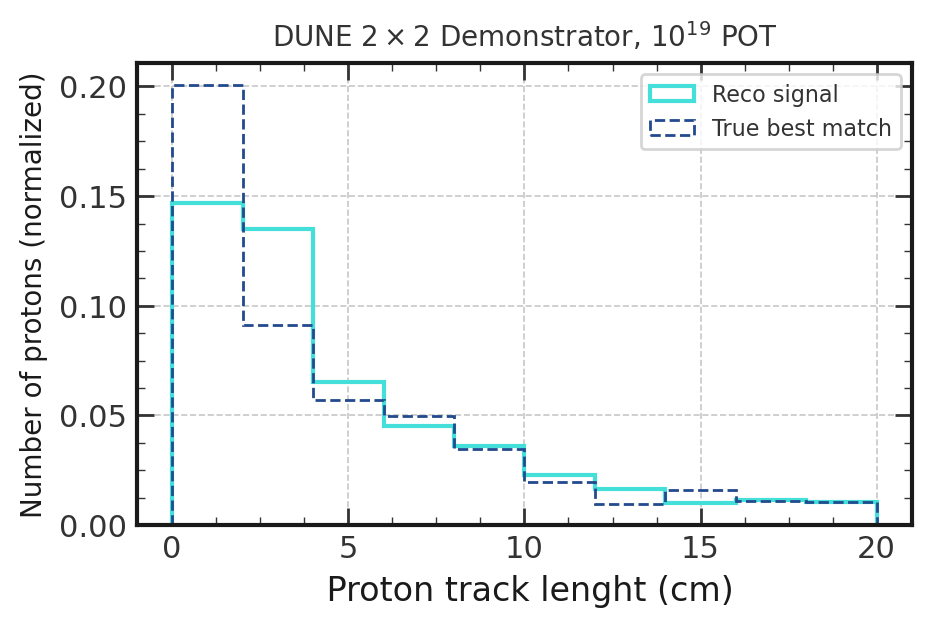

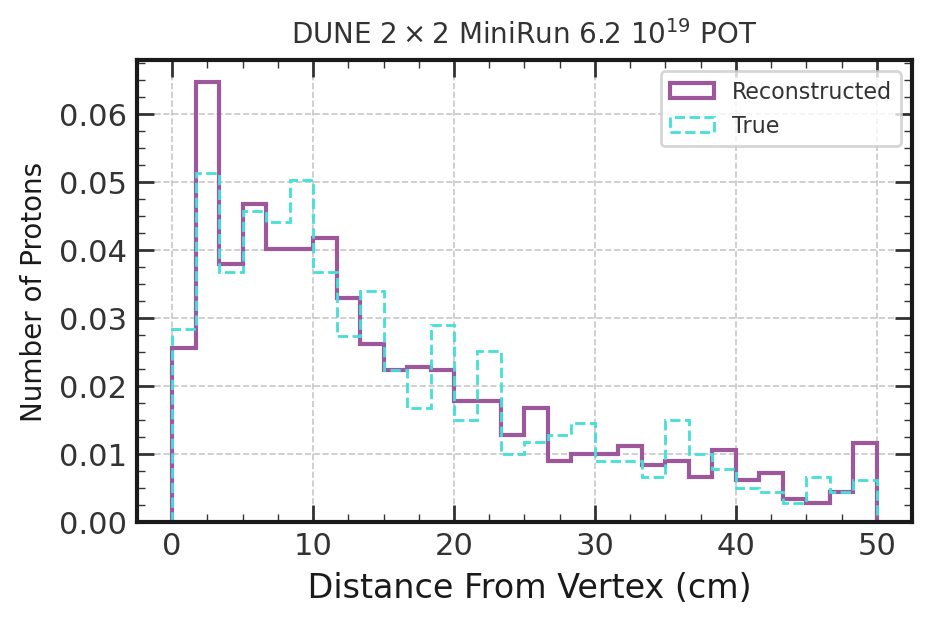

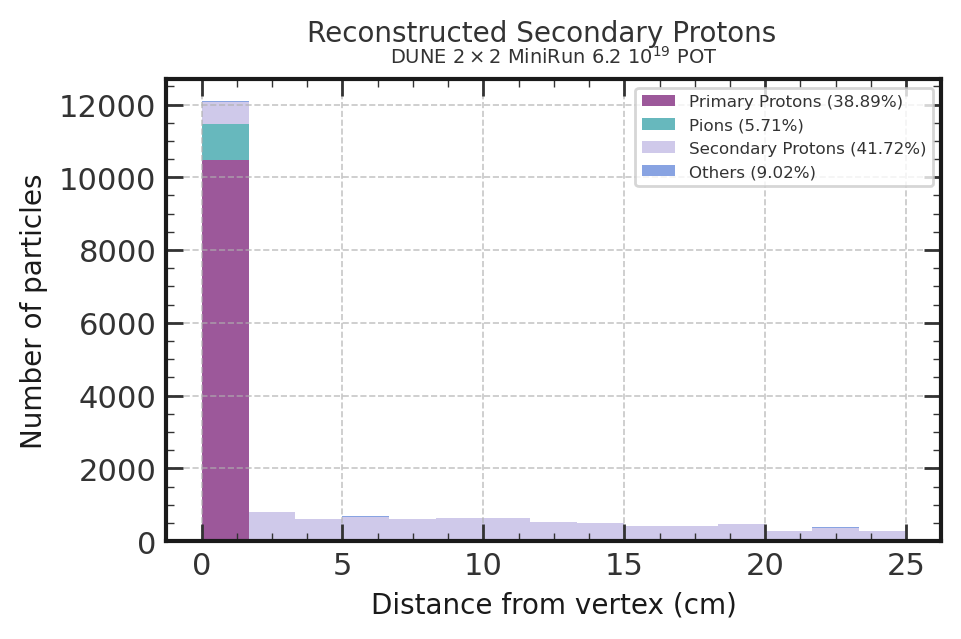

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 4_2025-02-26.pdf
Interaction Summary:

There are 31132 reconstructed vertices.
There are 27583 reco vertices matching true interaction signal.
There are 49338 true interactions
1: 13.27%
3: 40.77%
4: 27.28%
5: 1.52%
10: 5.07%
0: 12.09%
2: 0.00%

Efficiency: 55.91%
Purity: 88.60%


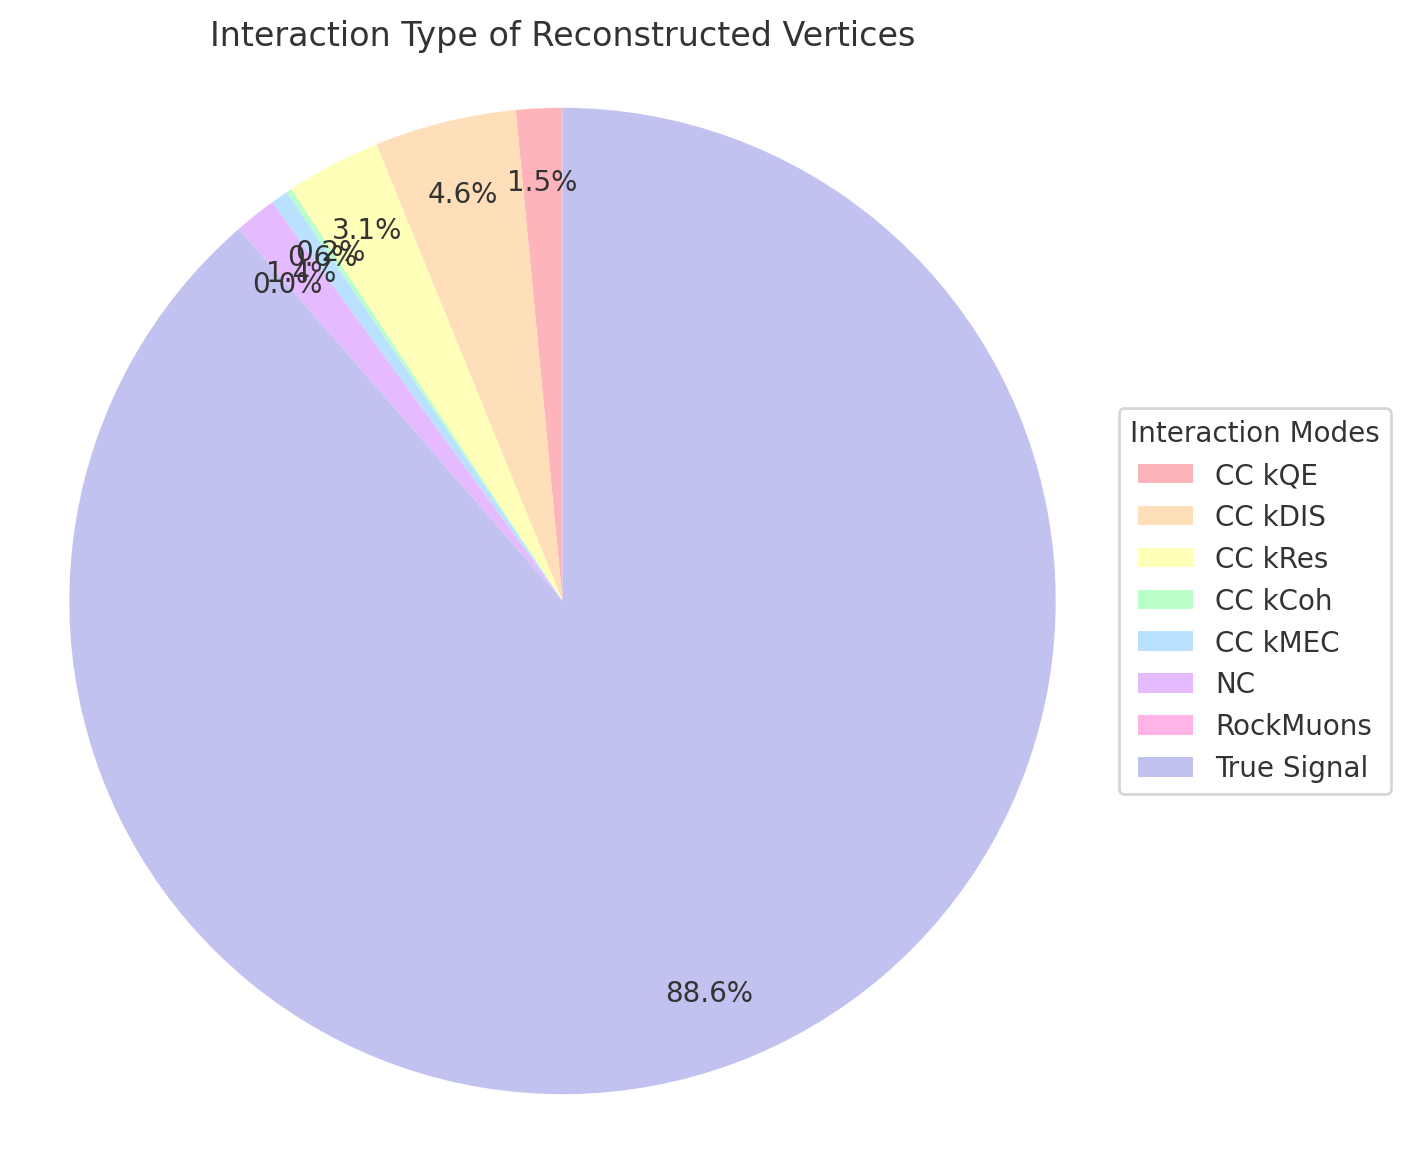

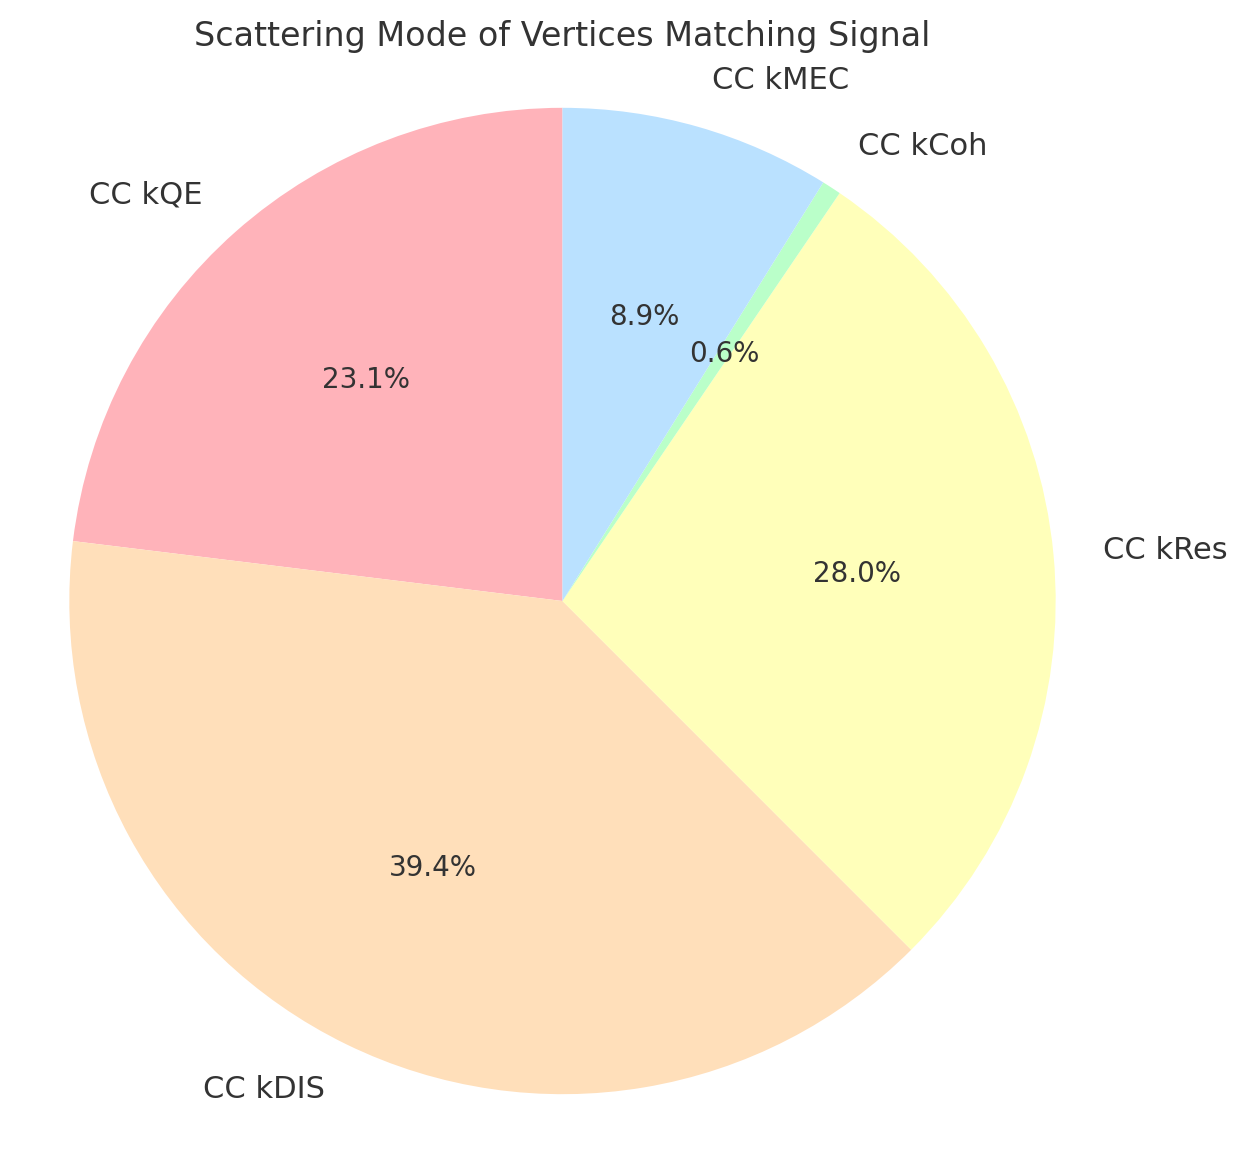

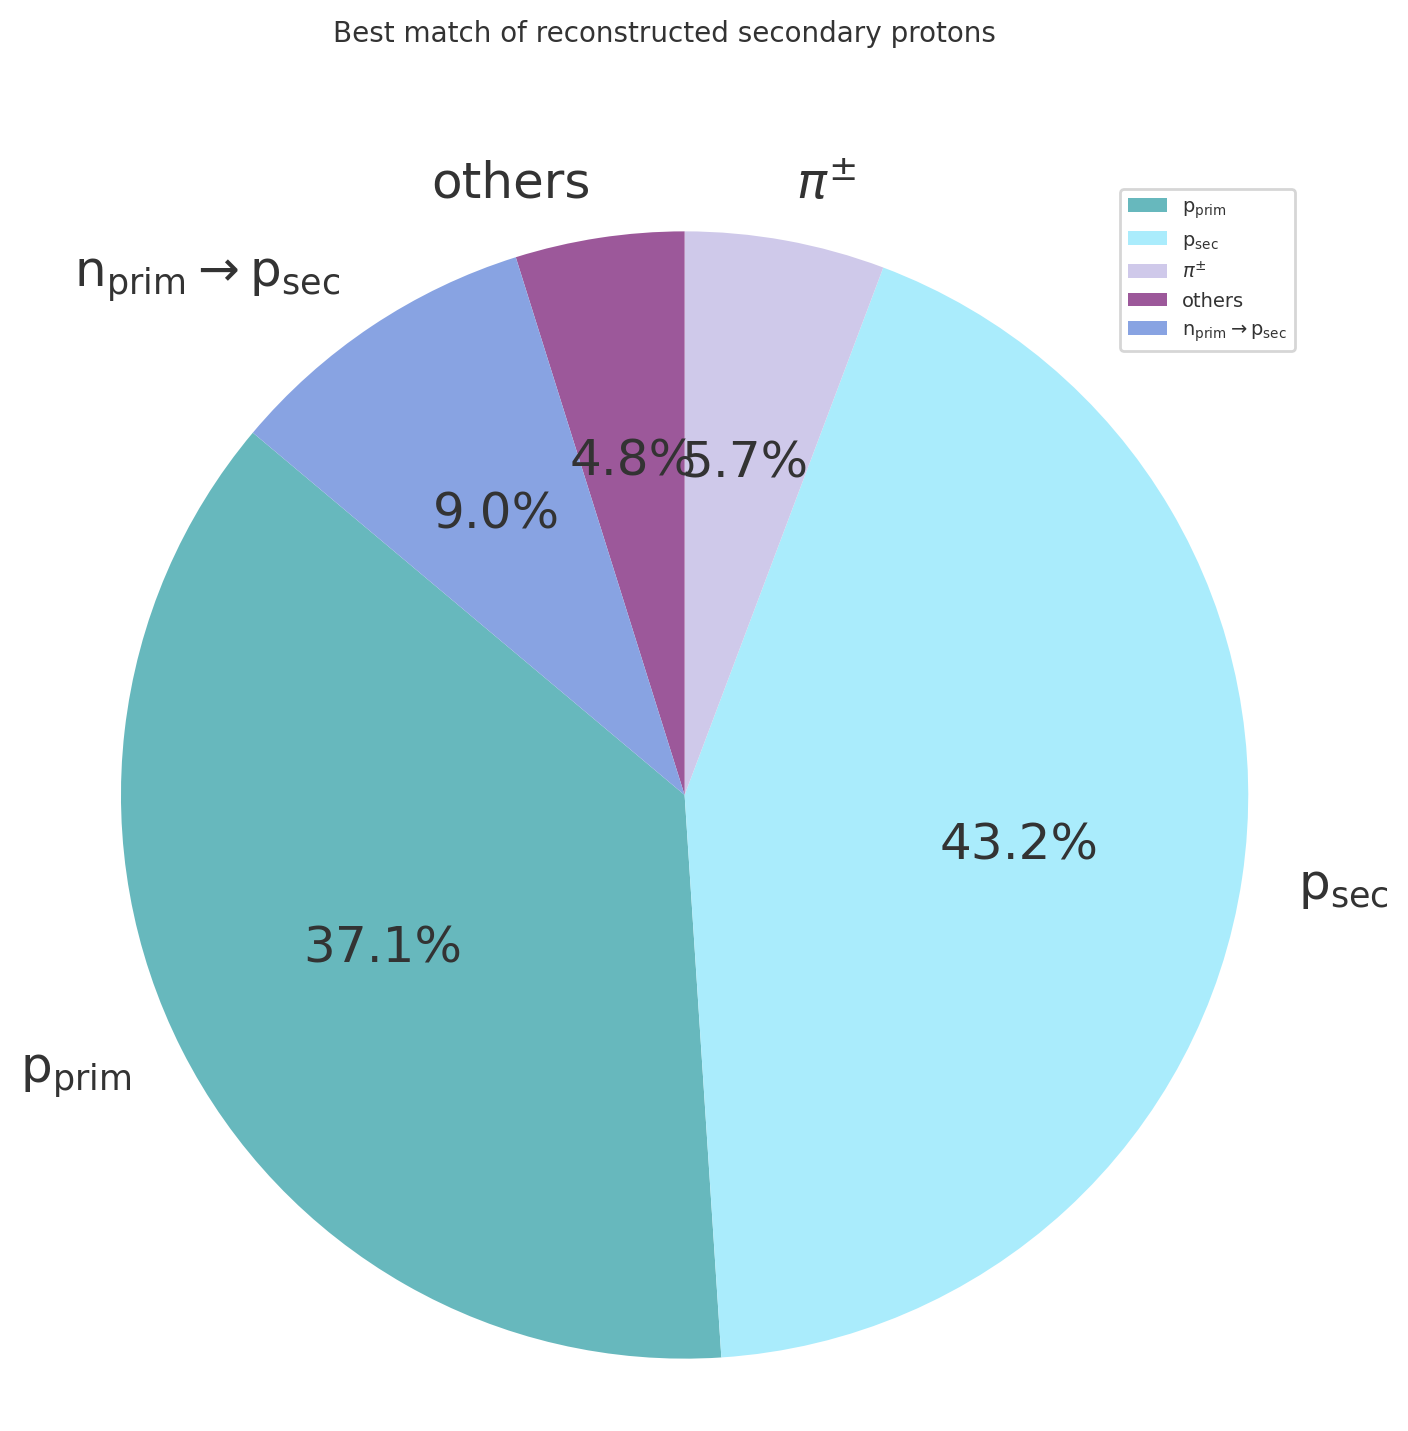

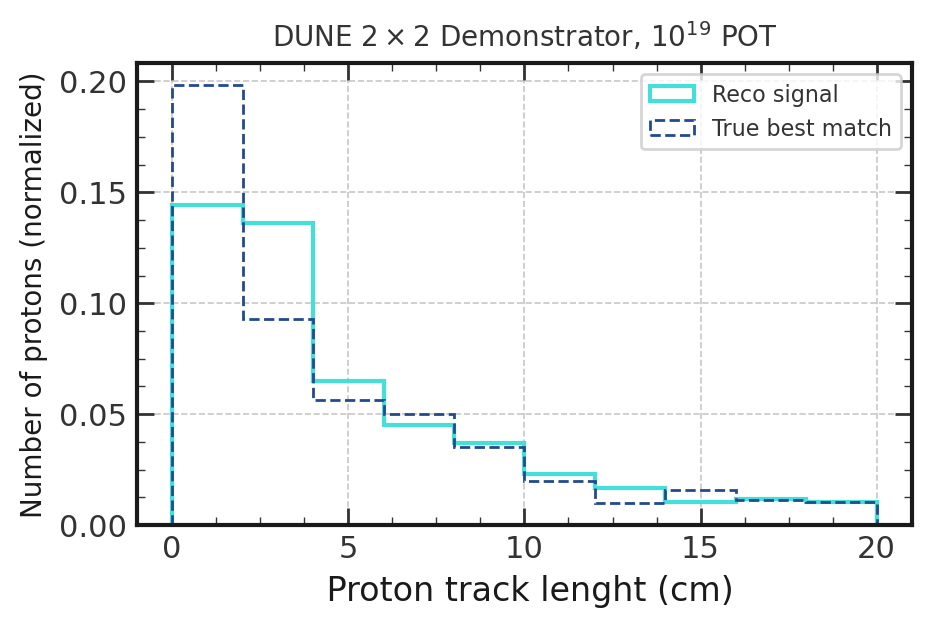

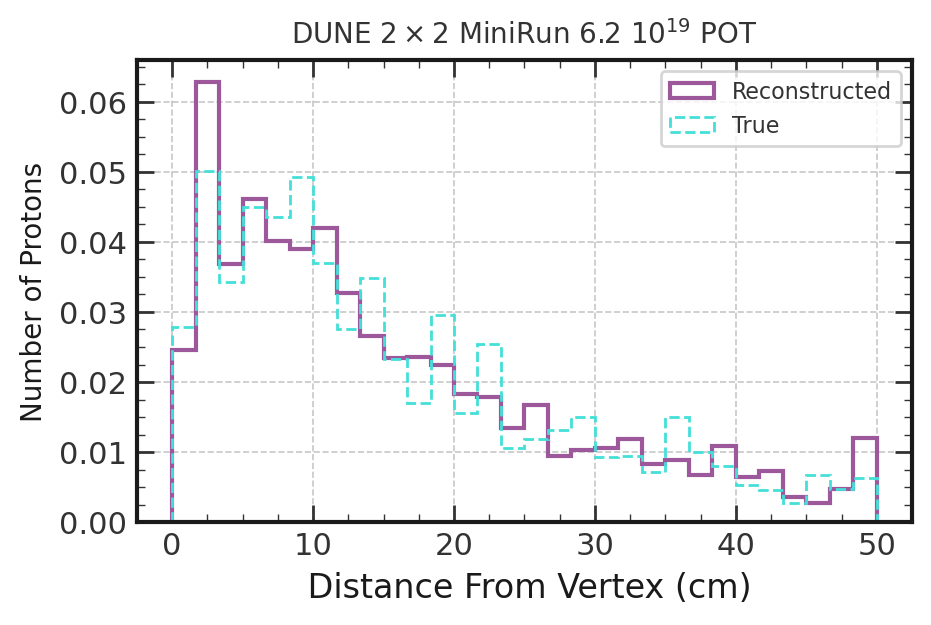

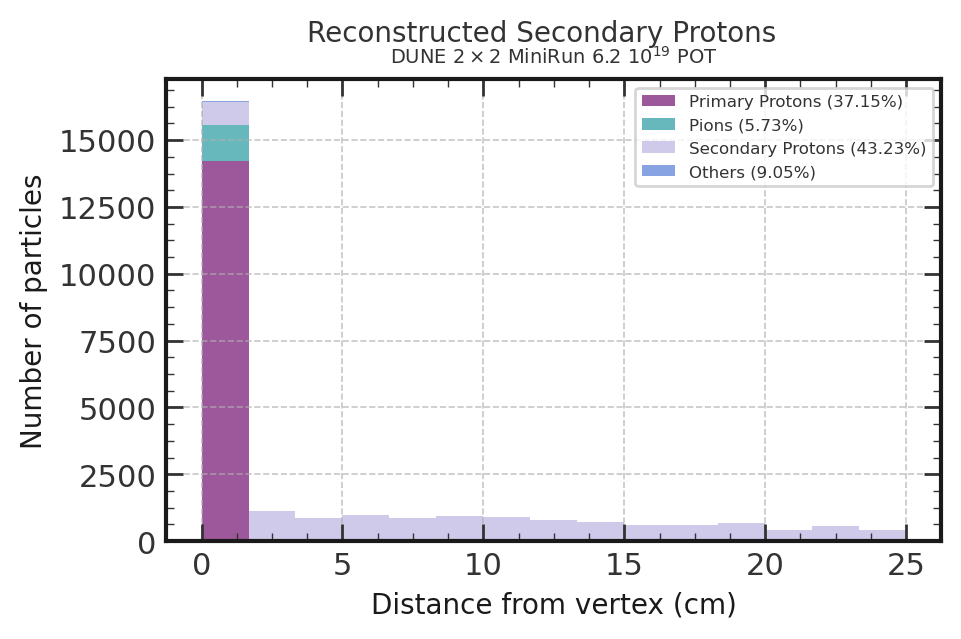

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 5_2025-02-26.pdf
Interaction Summary:

There are 39806 reconstructed vertices.
There are 35586 reco vertices matching true interaction signal.
There are 61984 true interactions
1: 12.46%
3: 41.94%
4: 25.97%
5: 1.42%
10: 4.83%
0: 13.36%
2: 0.00%

Efficiency: 57.41%
Purity: 89.40%


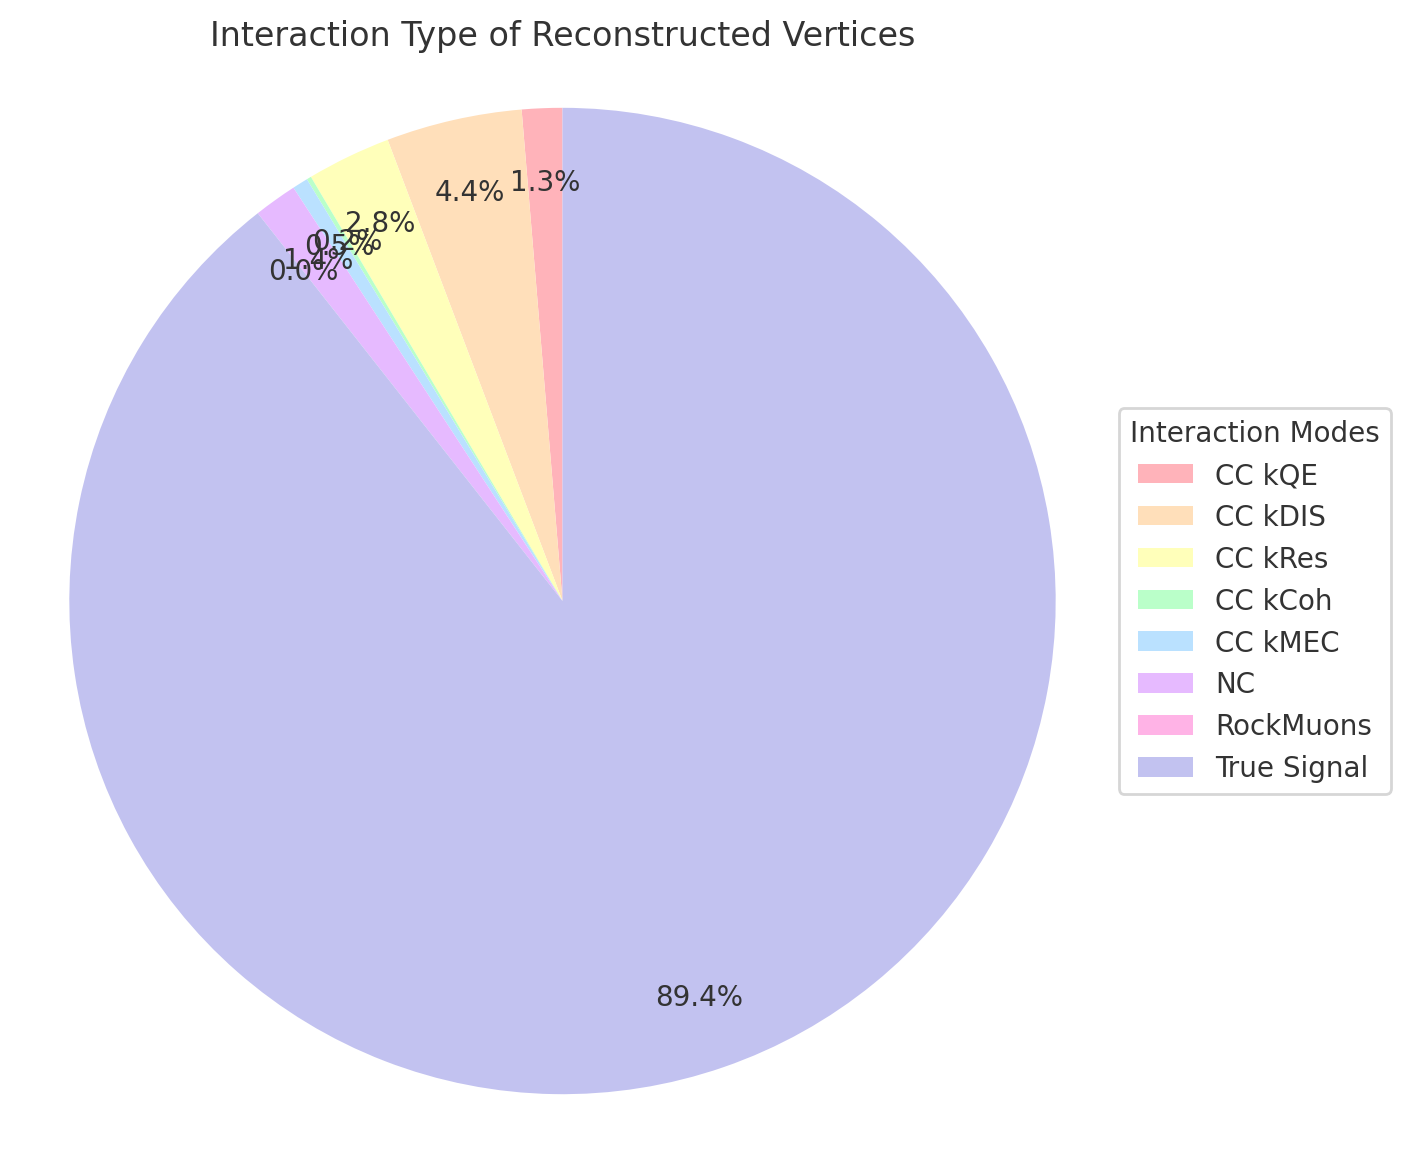

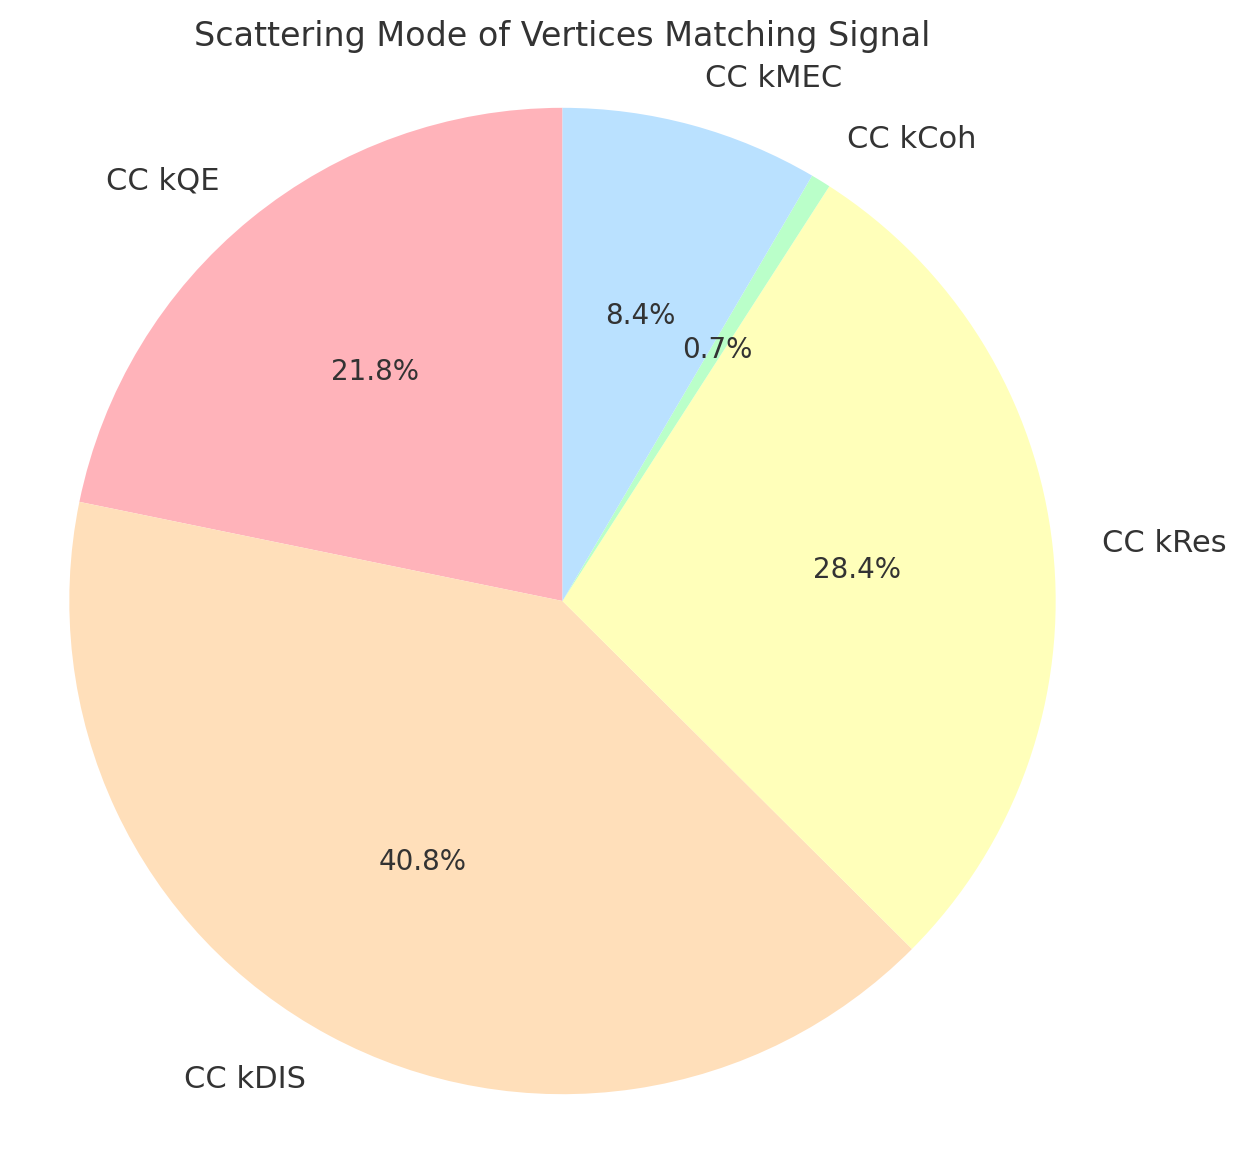

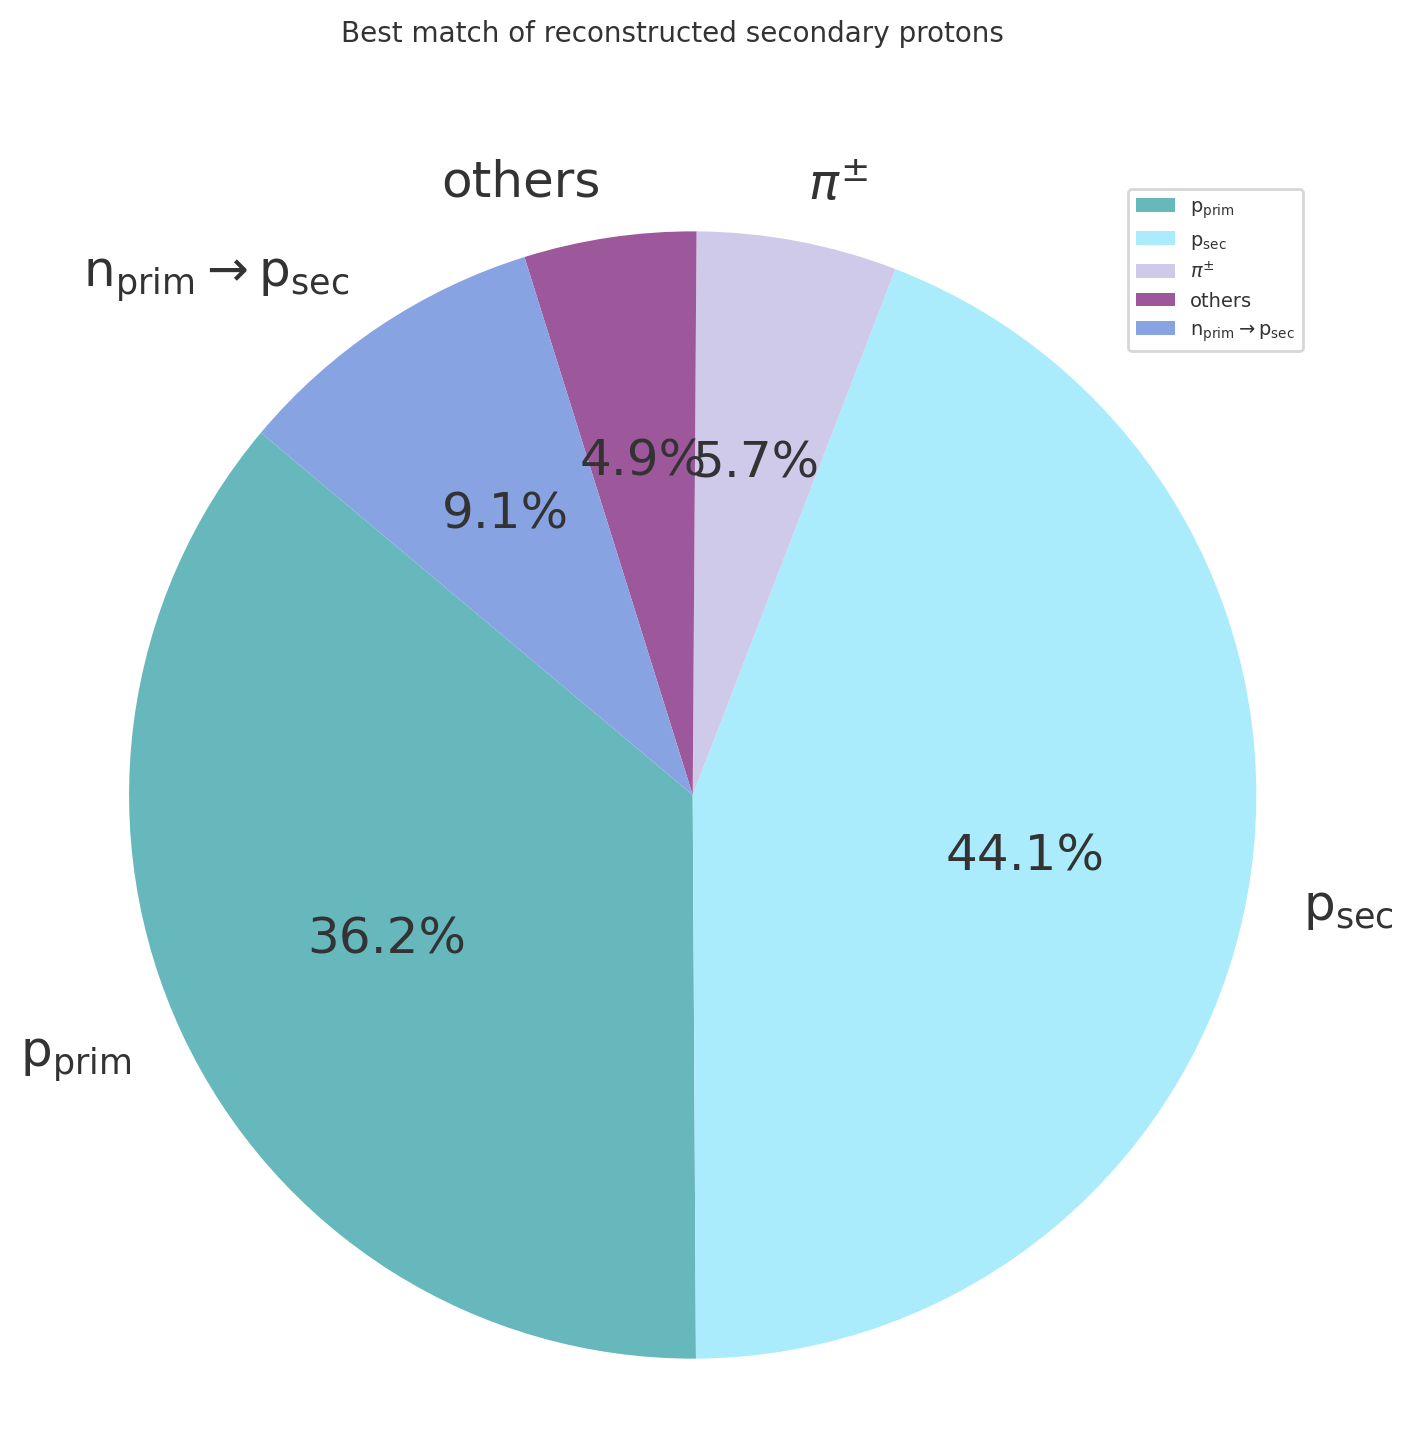

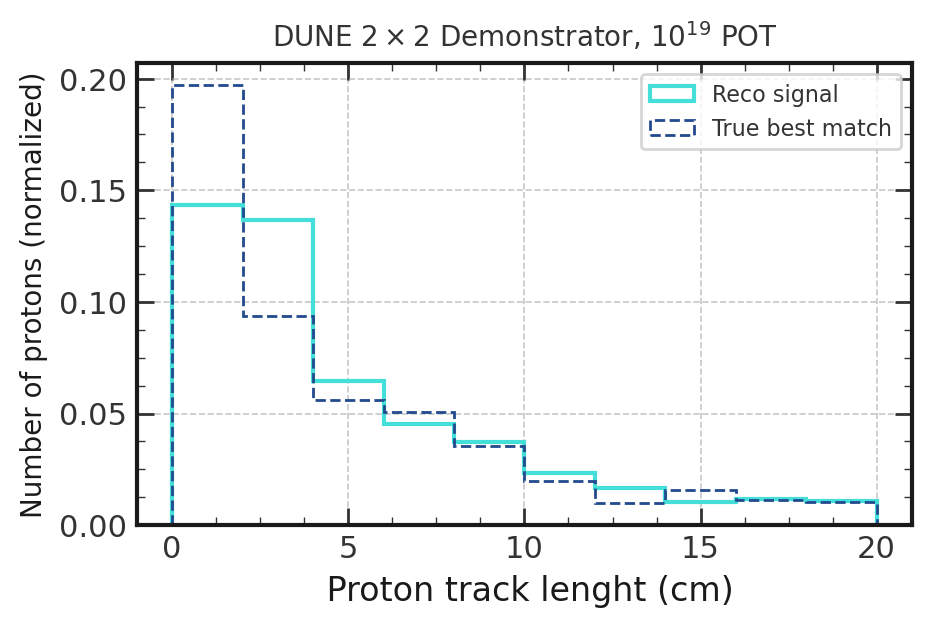

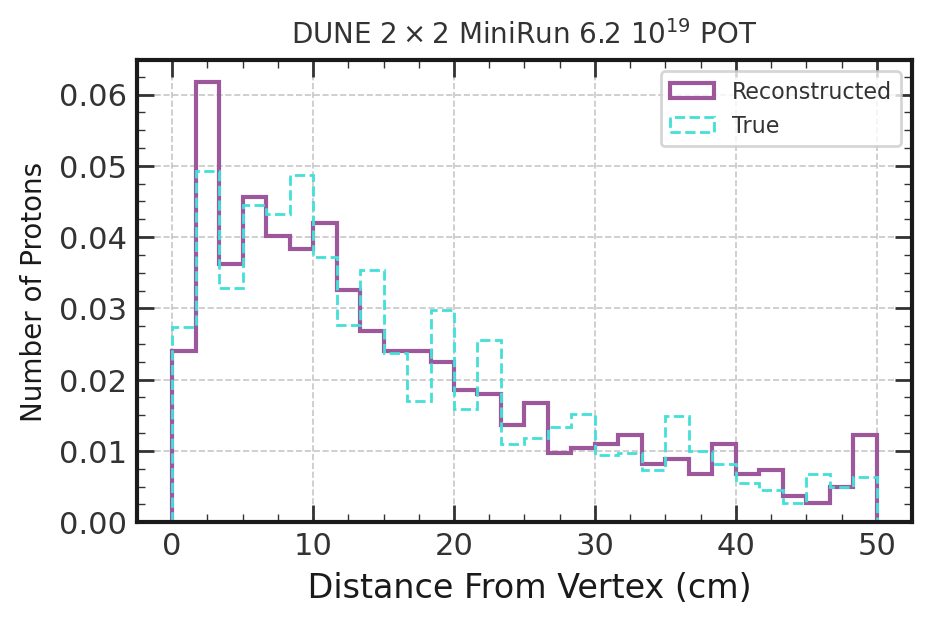

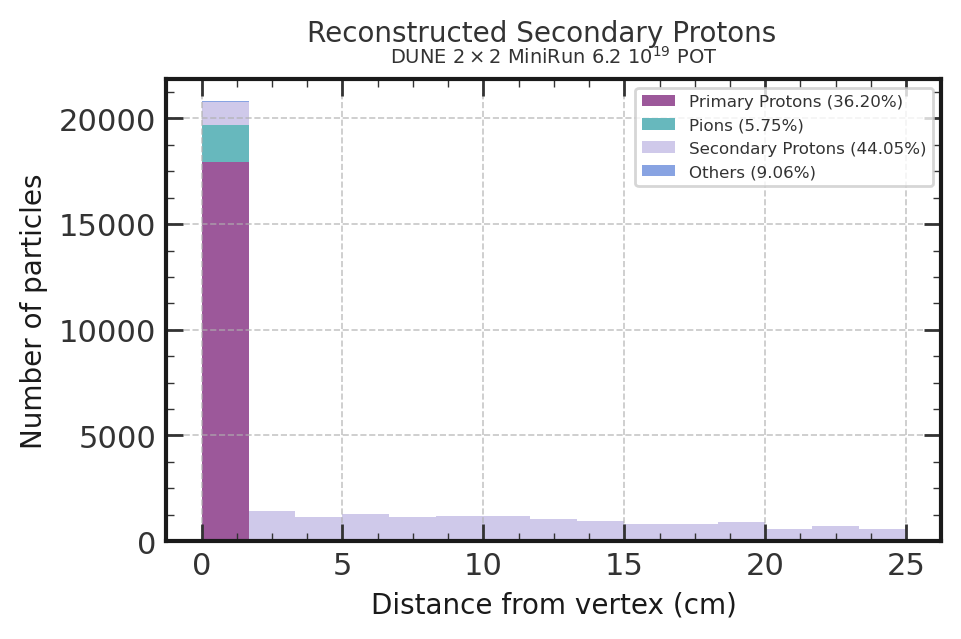

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 6_2025-02-26.pdf
Interaction Summary:

There are 48480 reconstructed vertices.
There are 43589 reco vertices matching true interaction signal.
There are 74630 true interactions
1: 11.88%
3: 42.79%
4: 25.03%
5: 1.35%
10: 4.66%
0: 14.29%
2: 0.00%

Efficiency: 58.41%
Purity: 89.91%


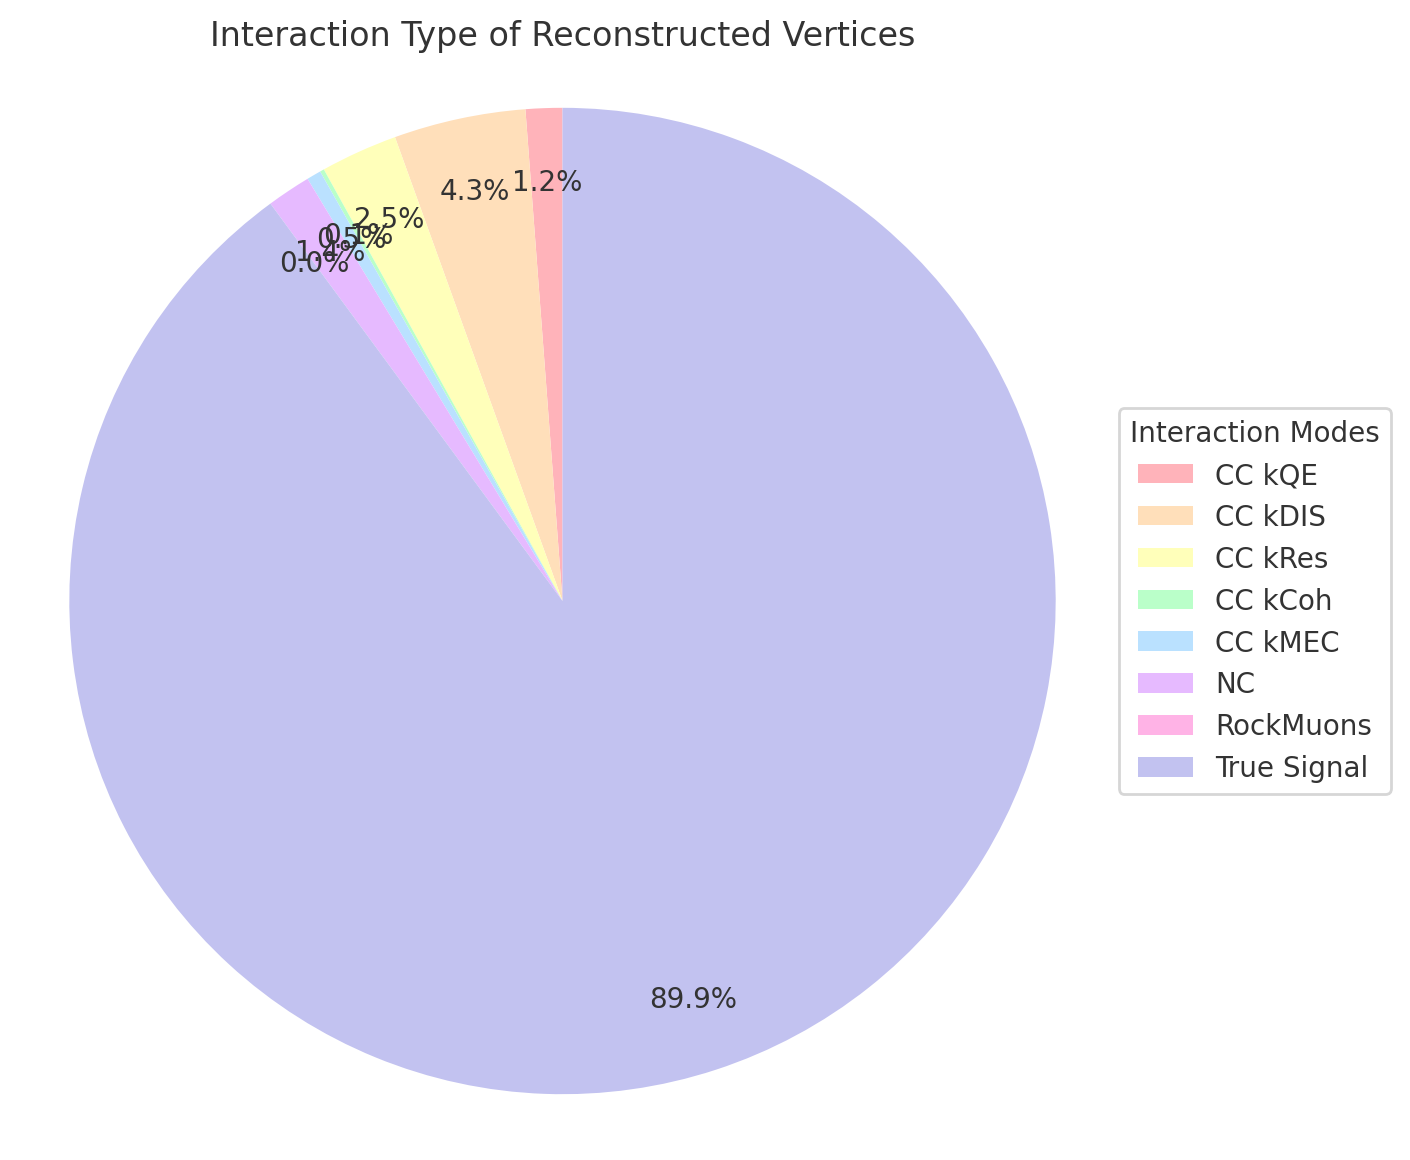

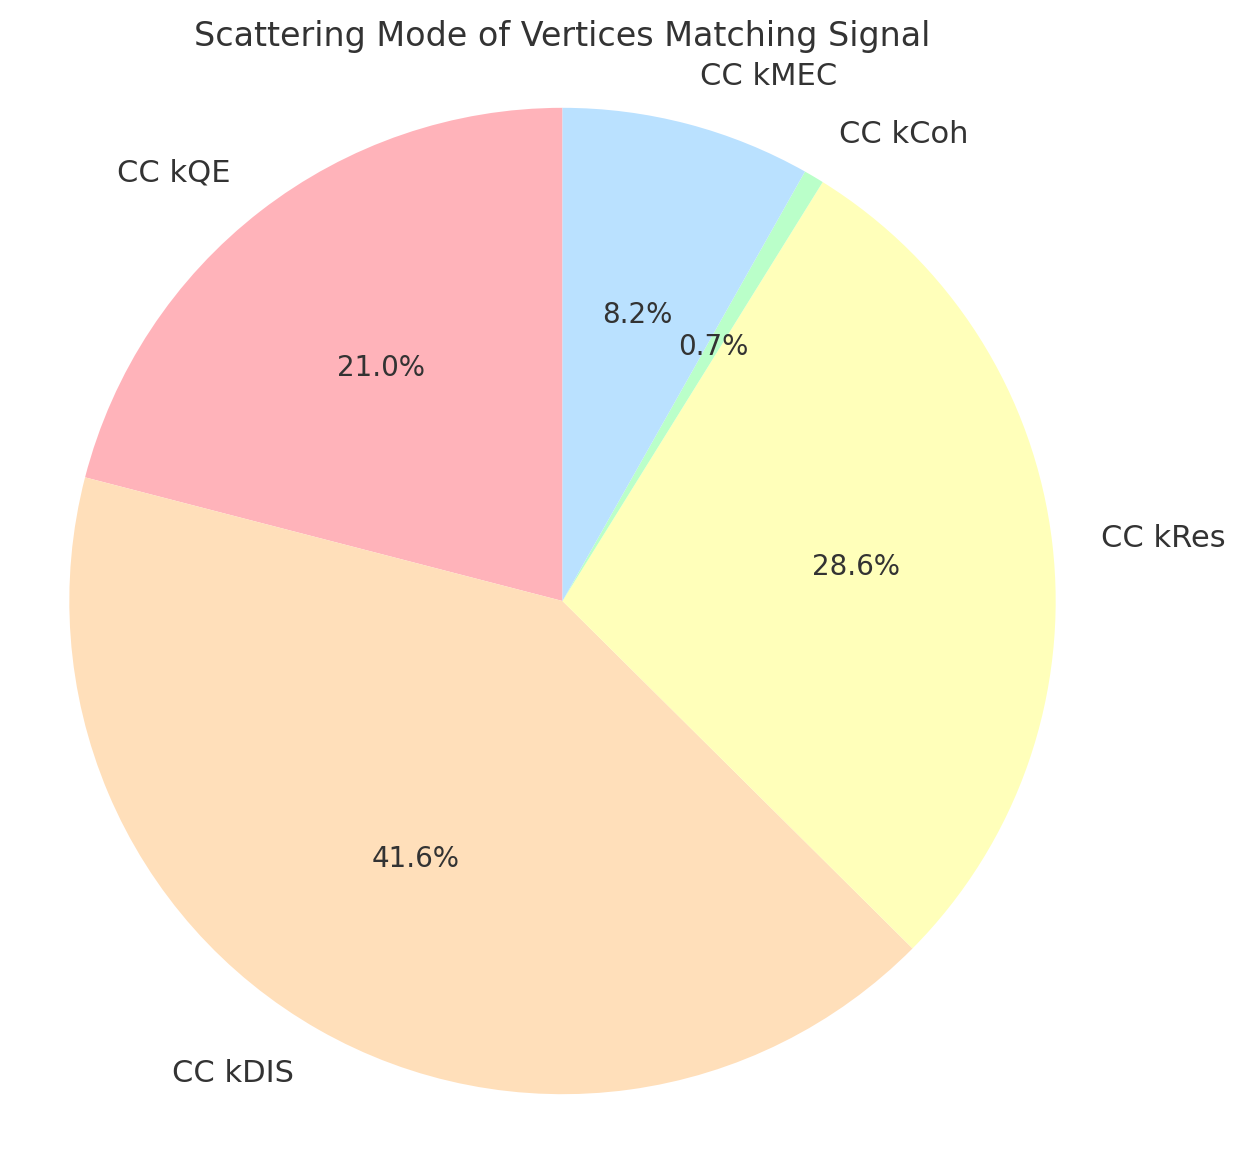

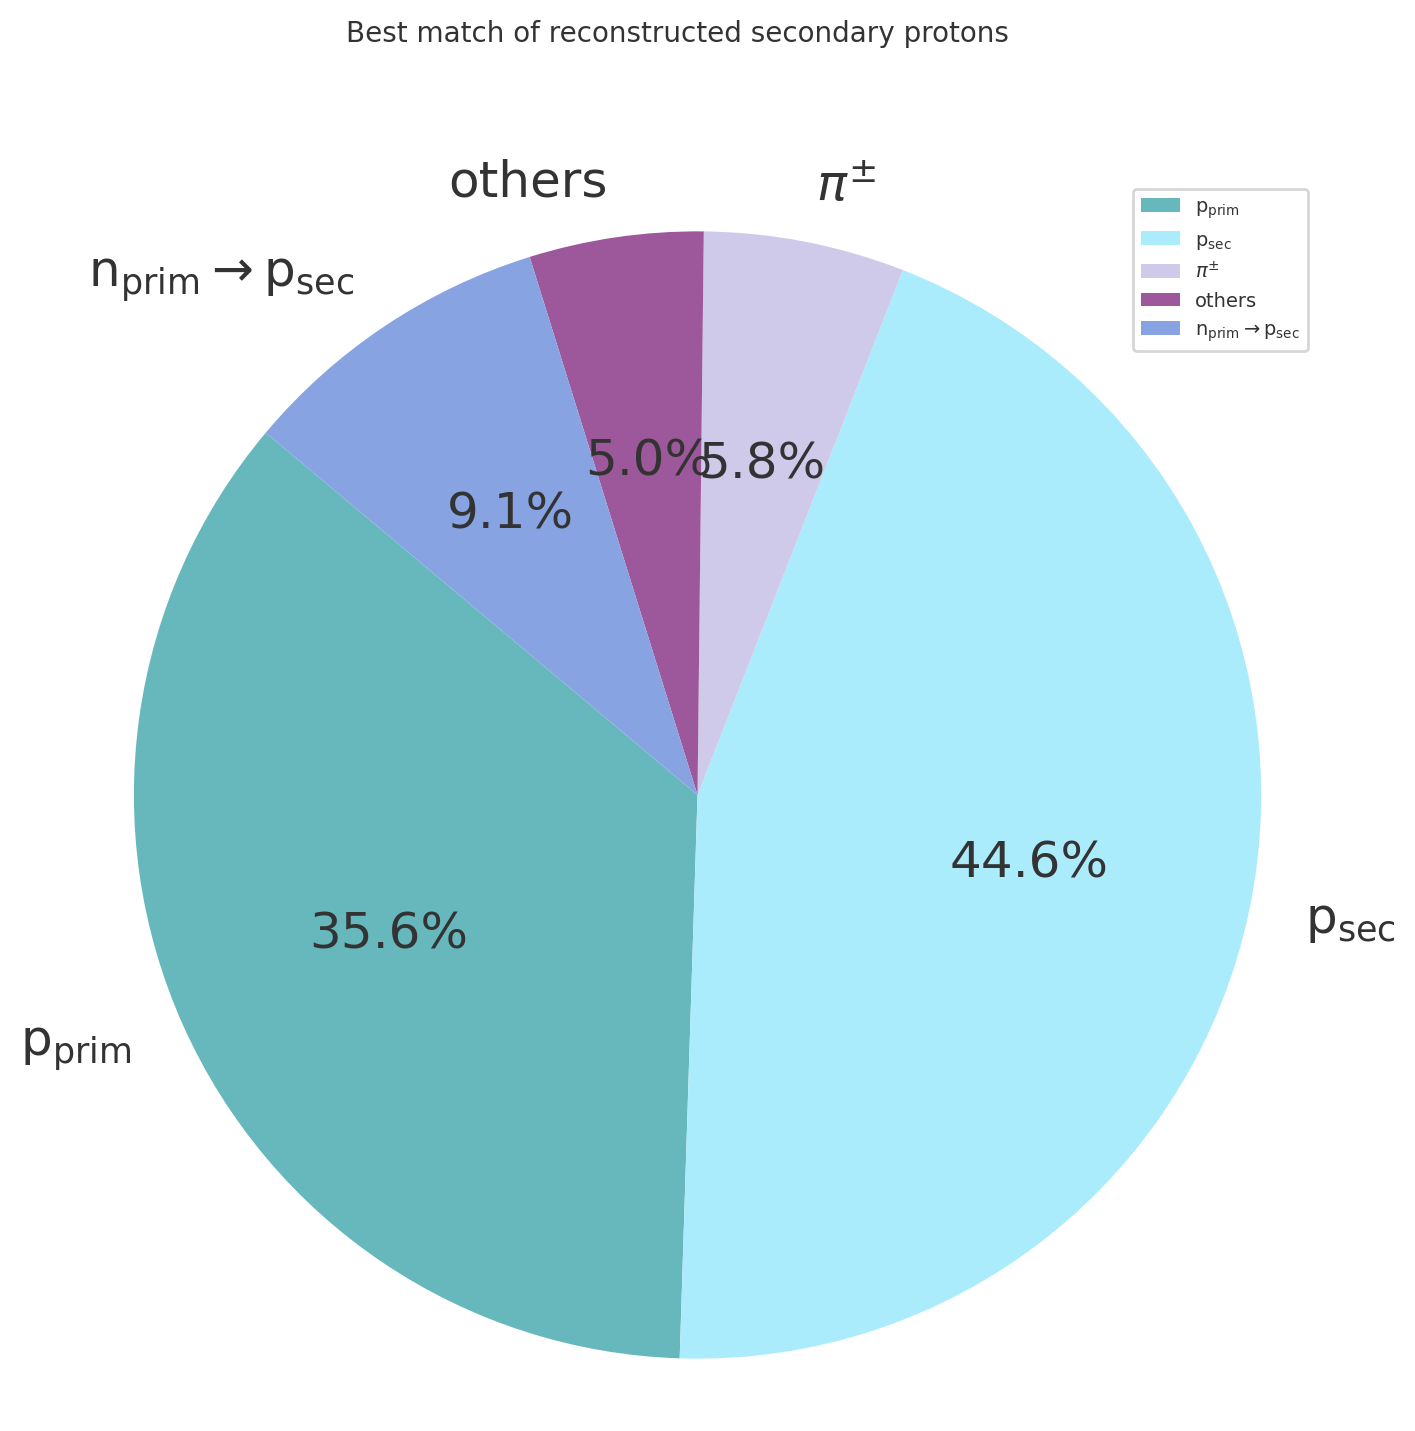

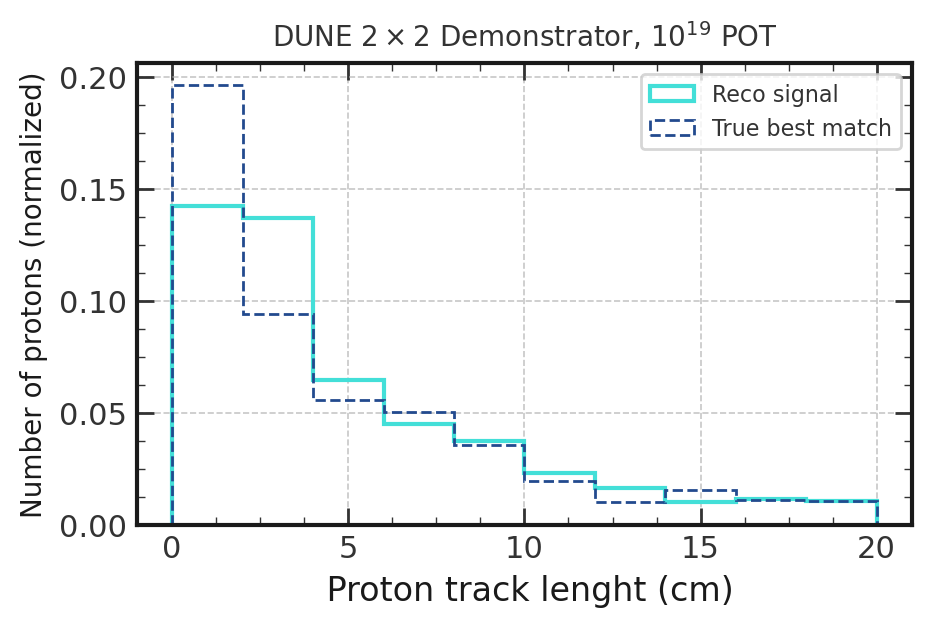

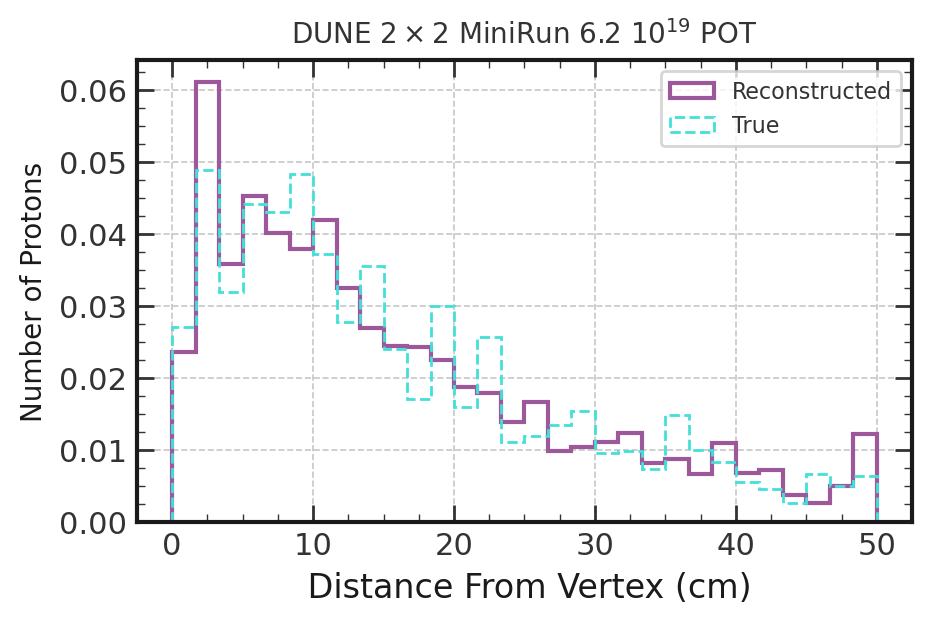

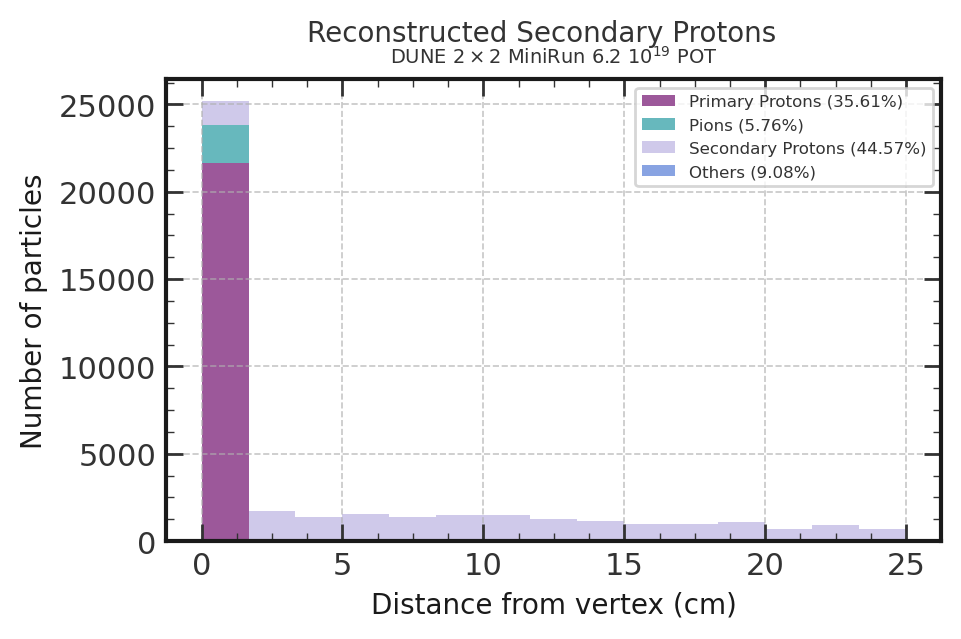

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 7_2025-02-26.pdf
Interaction Summary:

There are 57154 reconstructed vertices.
There are 51592 reco vertices matching true interaction signal.
There are 87276 true interactions
1: 11.43%
3: 43.44%
4: 24.31%
5: 1.29%
10: 4.53%
0: 14.99%
2: 0.00%

Efficiency: 59.11%
Purity: 90.27%


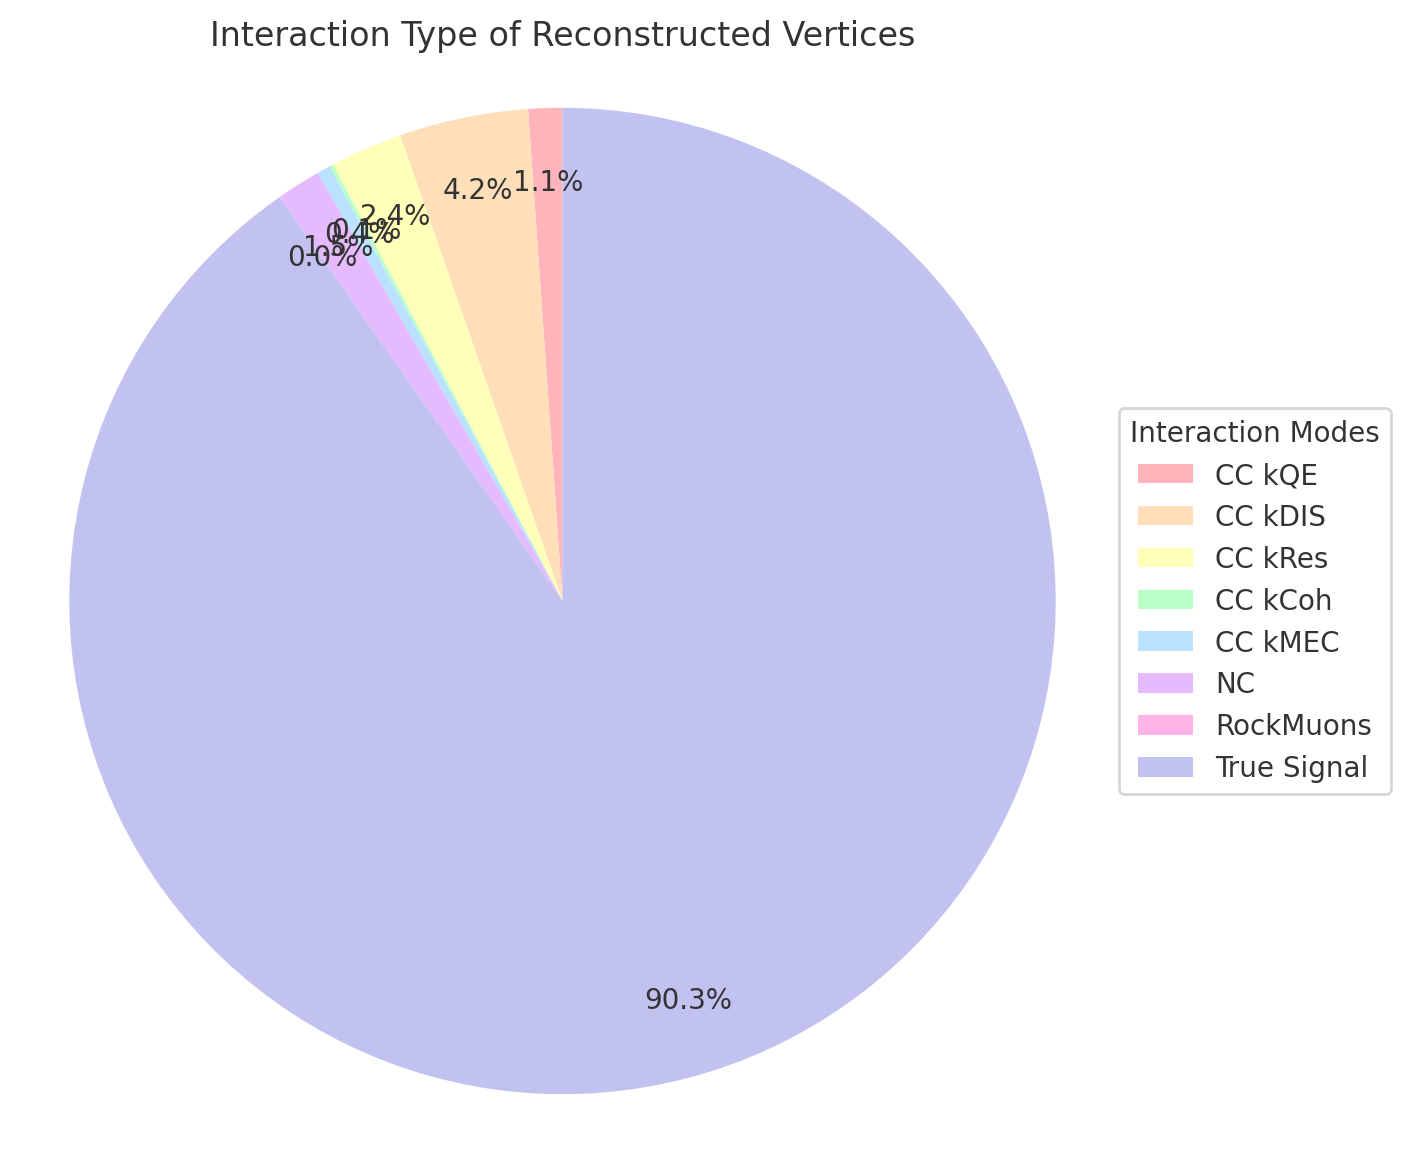

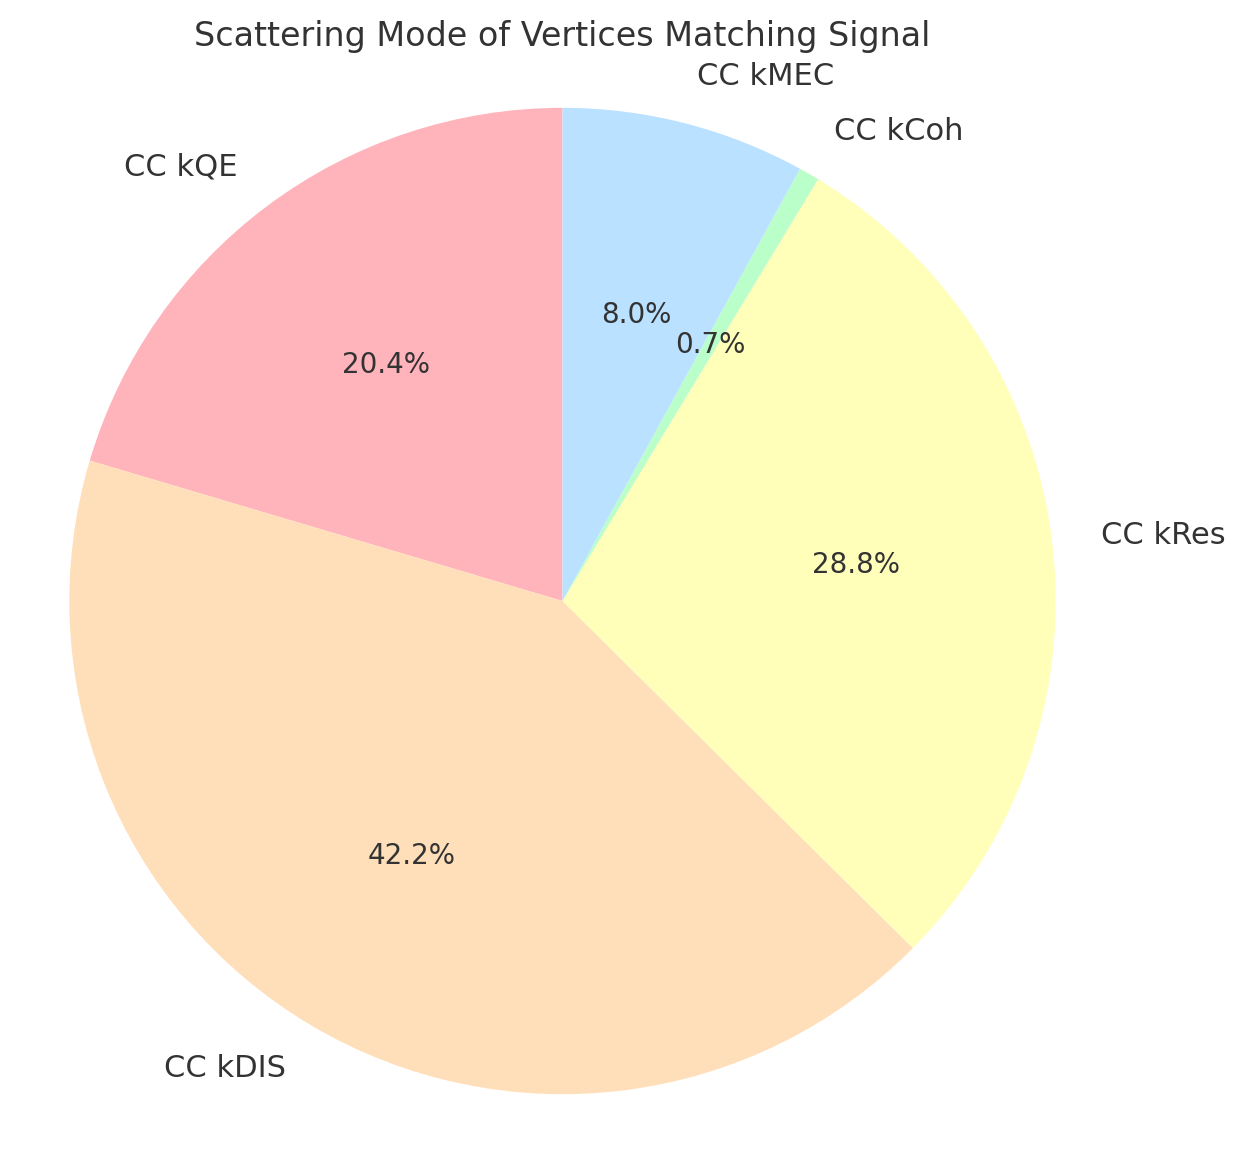

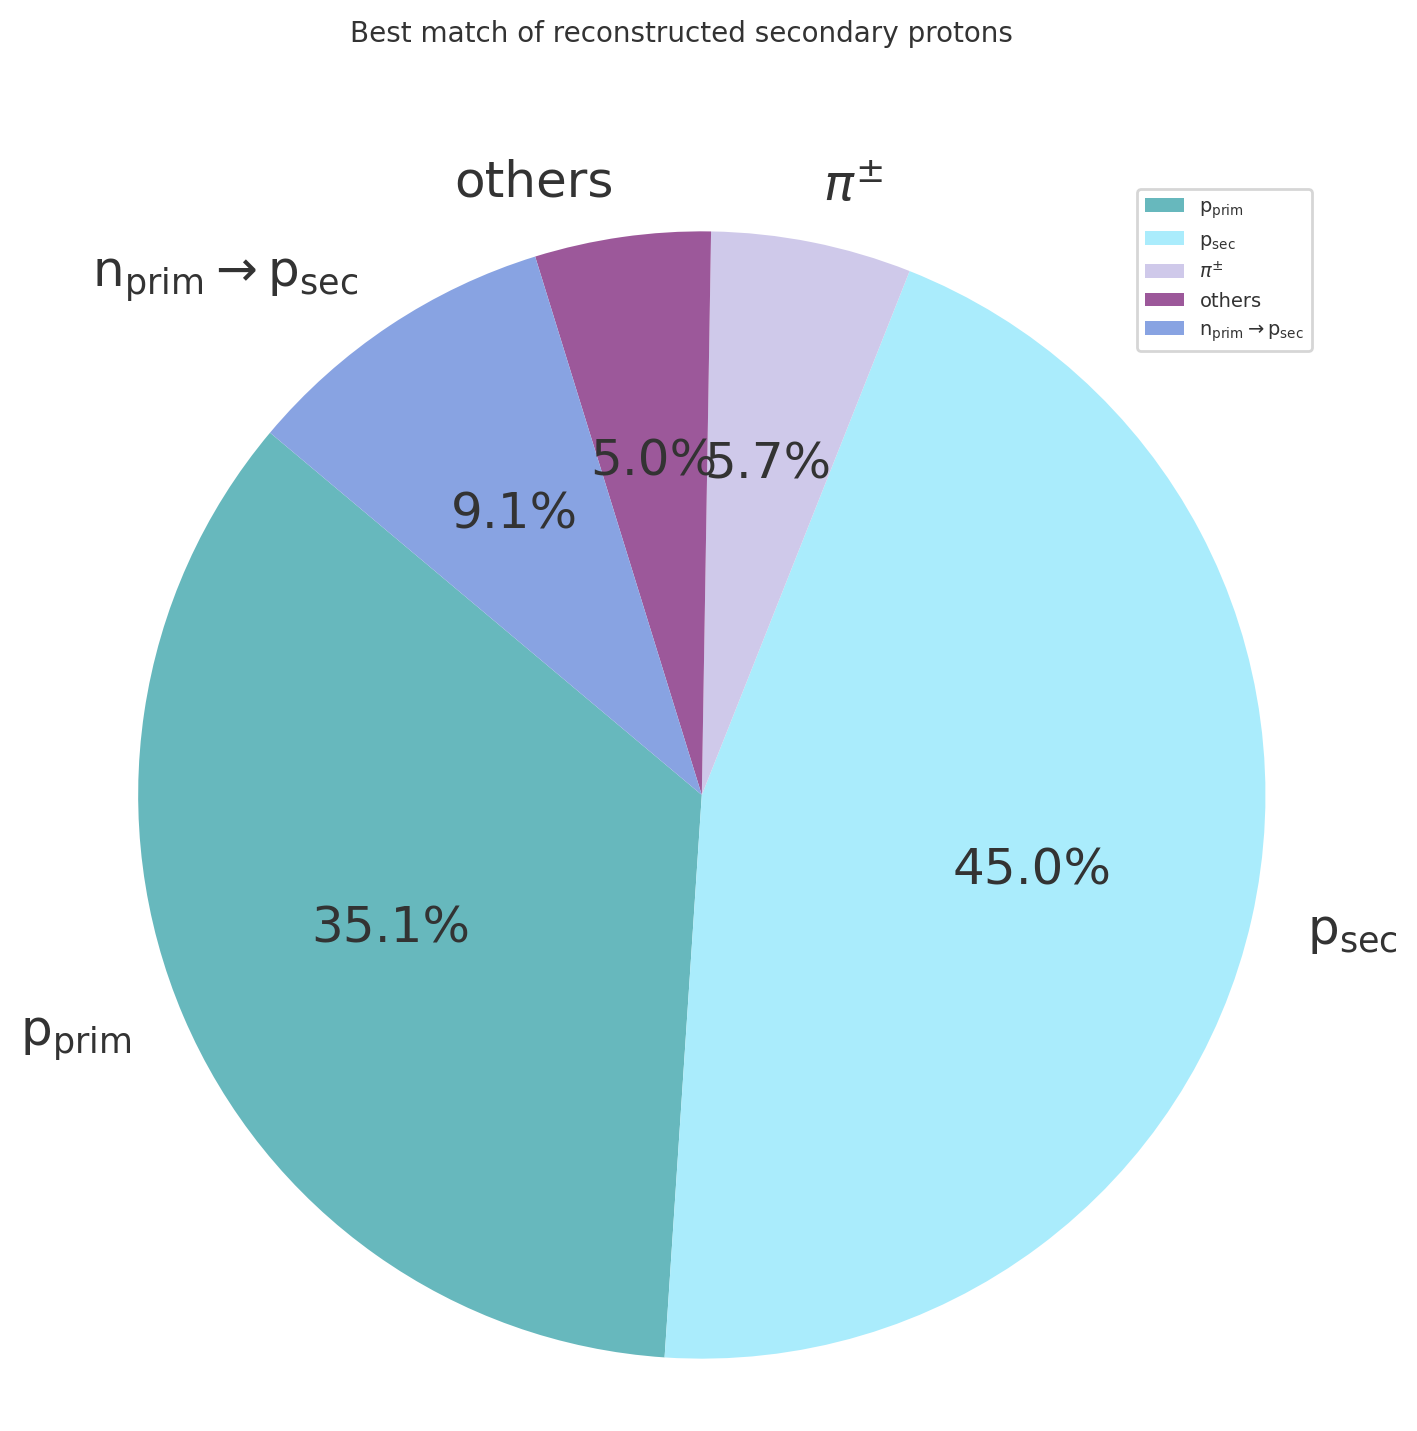

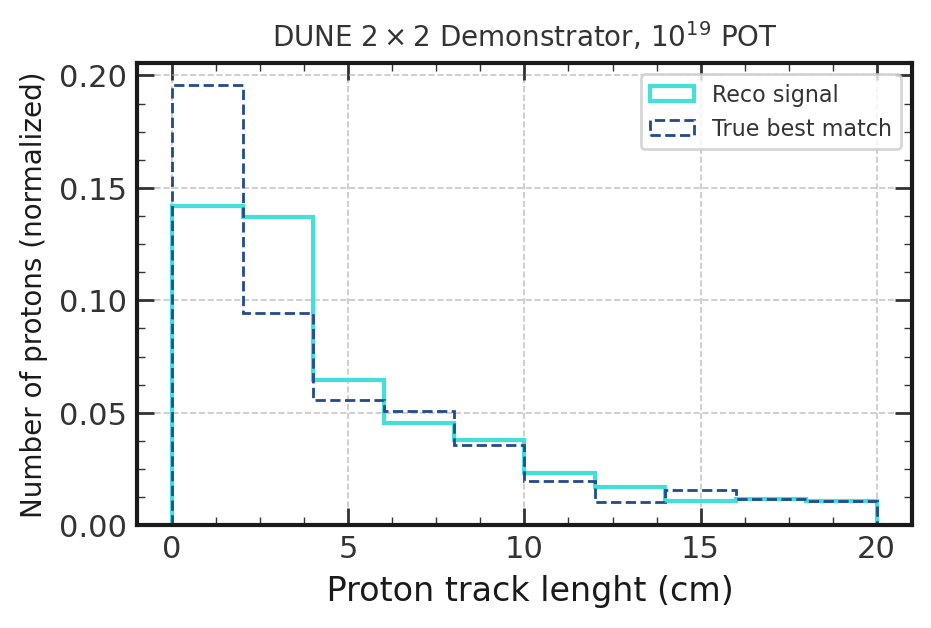

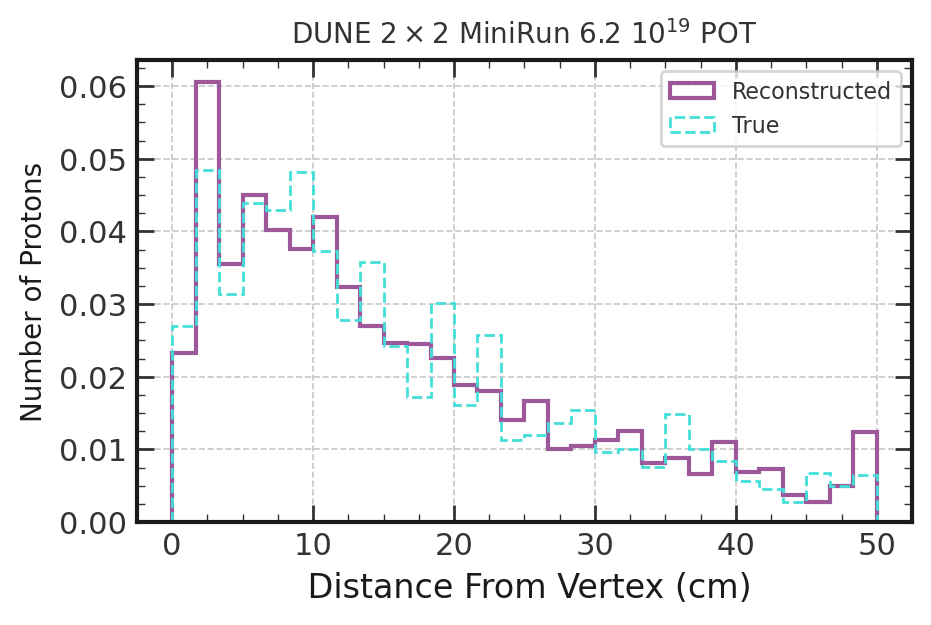

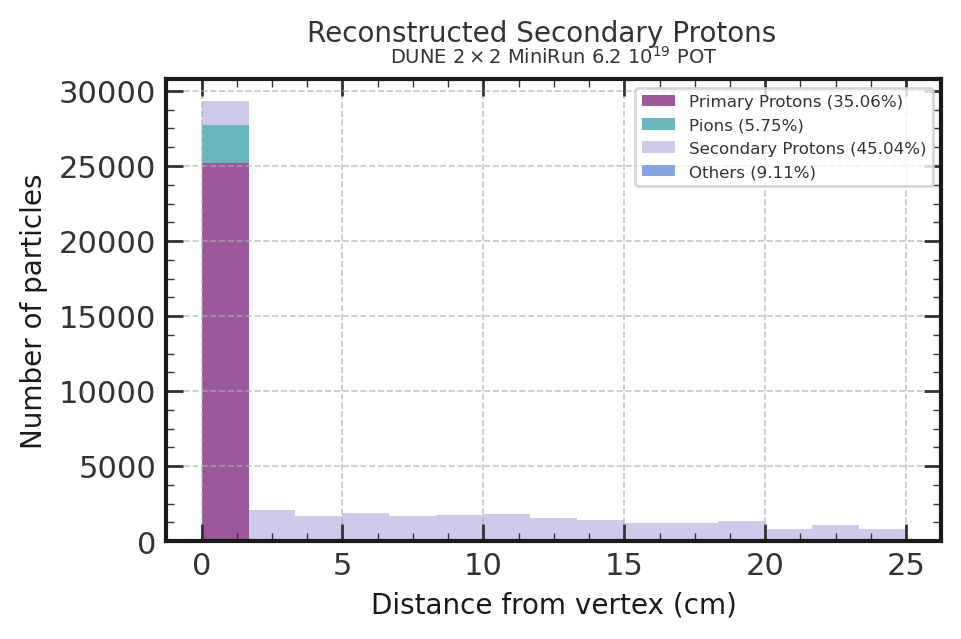

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 8_2025-02-26.pdf
Interaction Summary:

There are 65828 reconstructed vertices.
There are 59595 reco vertices matching true interaction signal.
There are 99922 true interactions
1: 11.09%
3: 43.94%
4: 23.74%
5: 1.25%
10: 4.43%
0: 15.55%
2: 0.00%

Efficiency: 59.64%
Purity: 90.53%


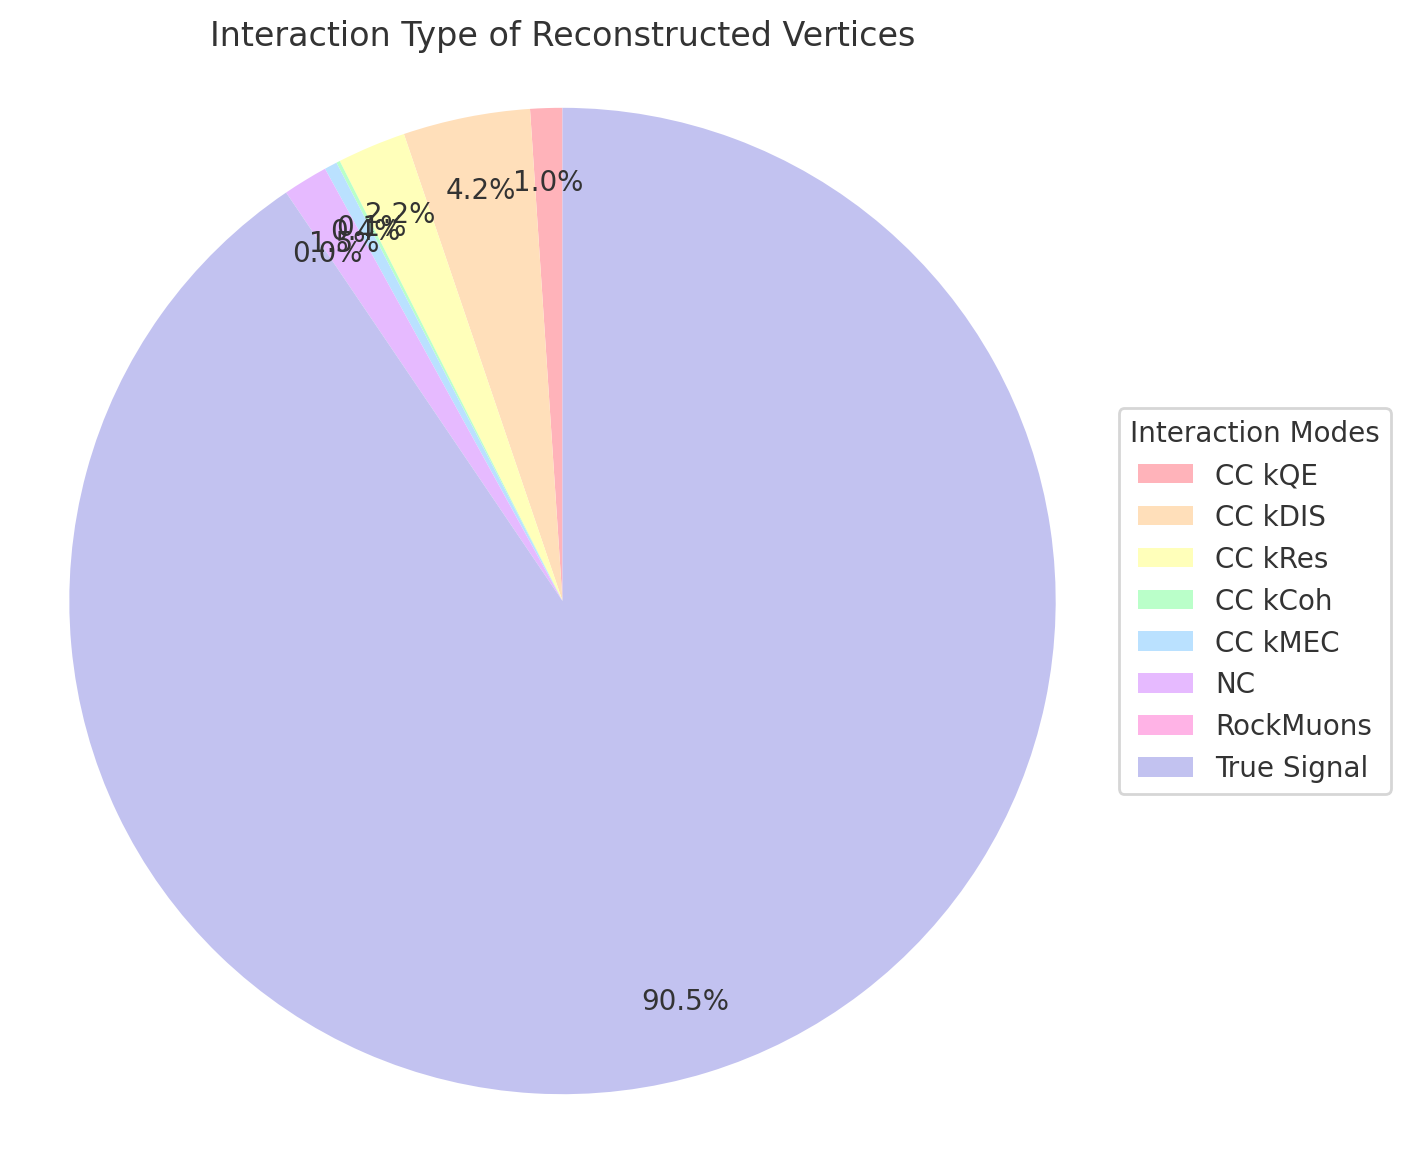

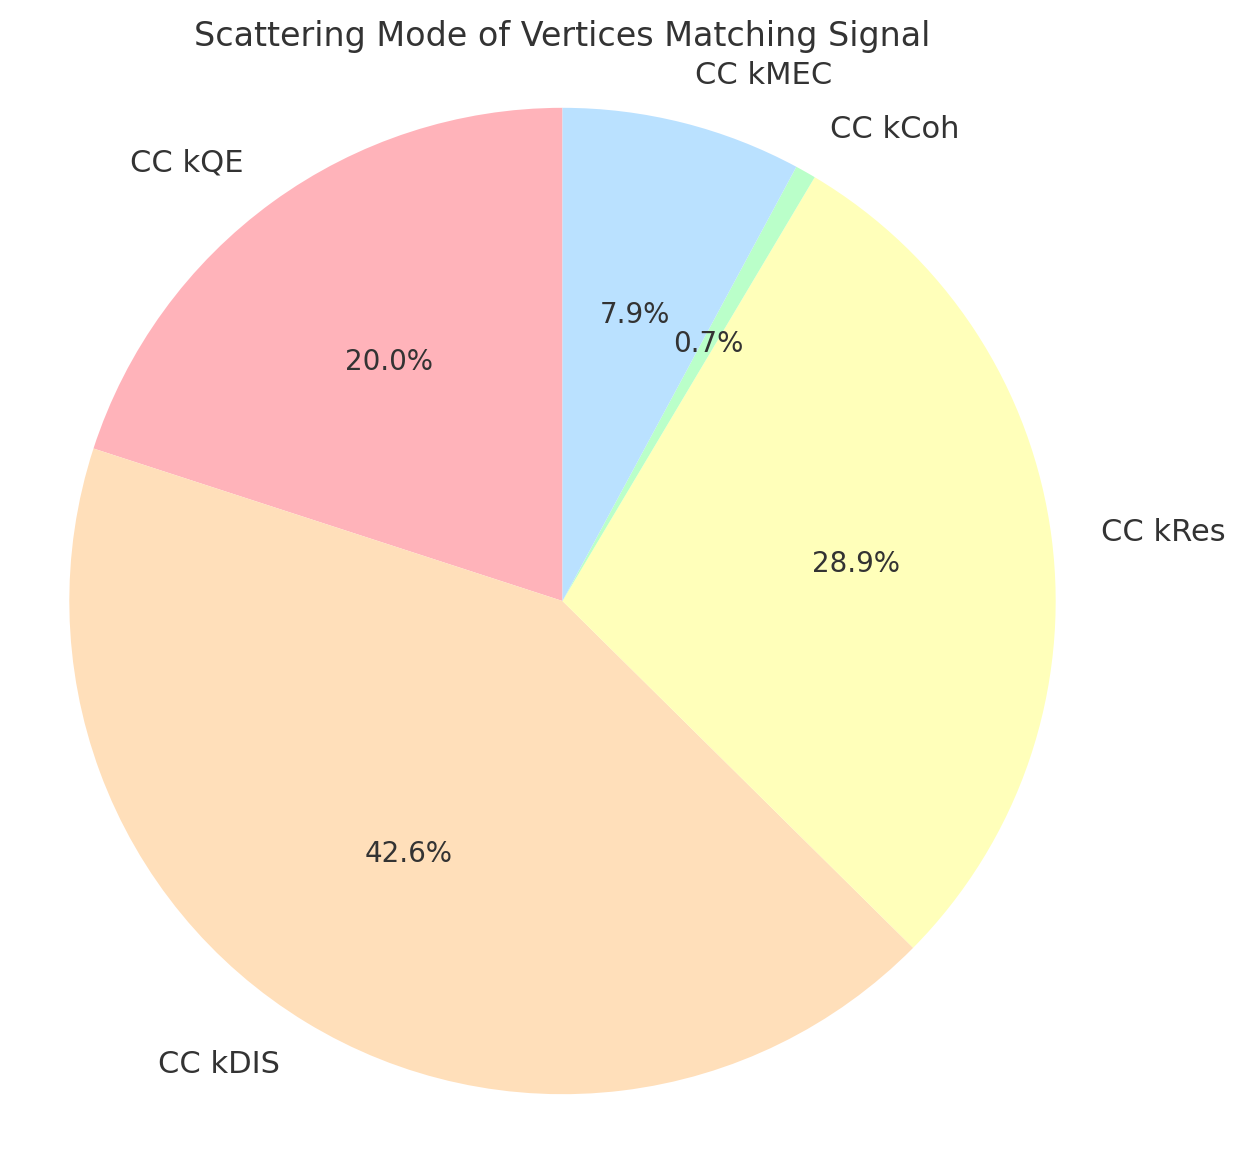

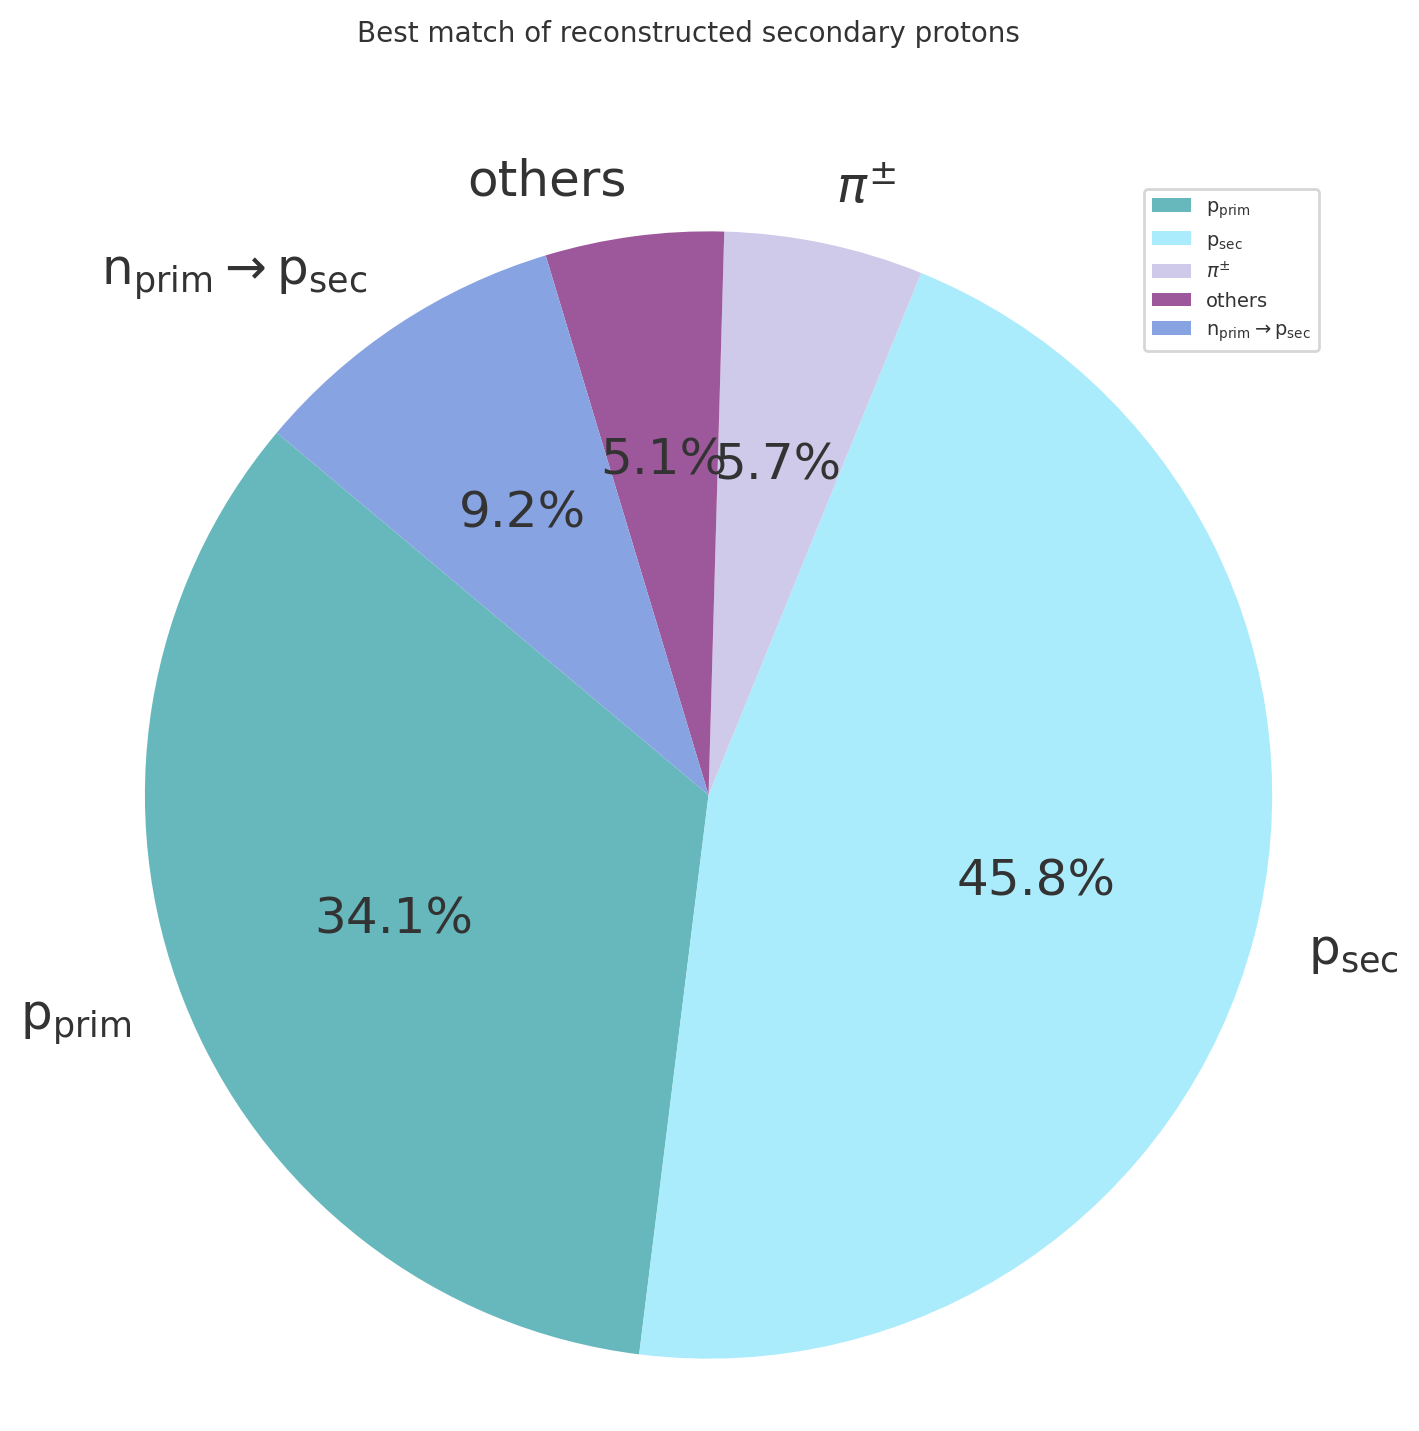

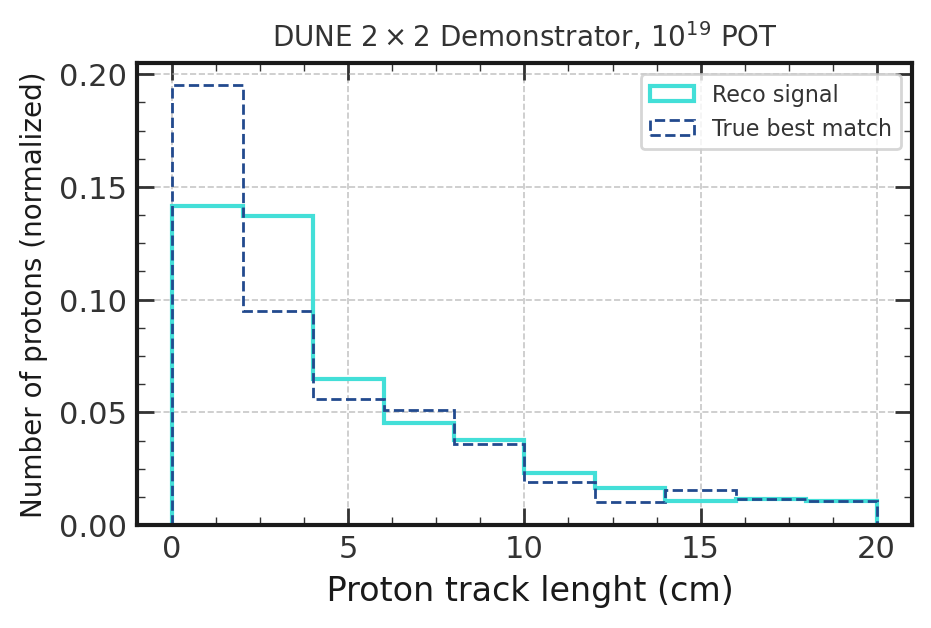

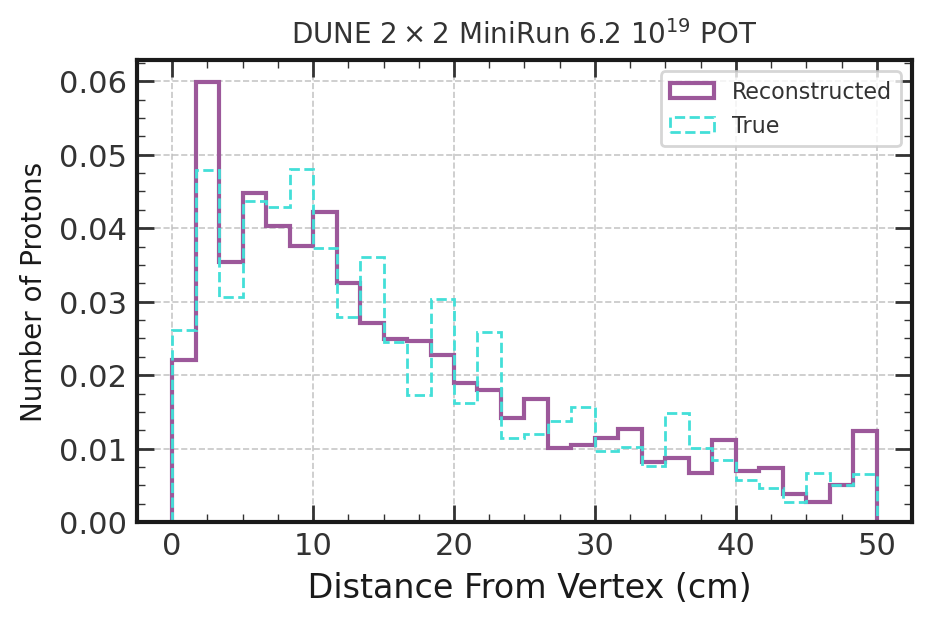

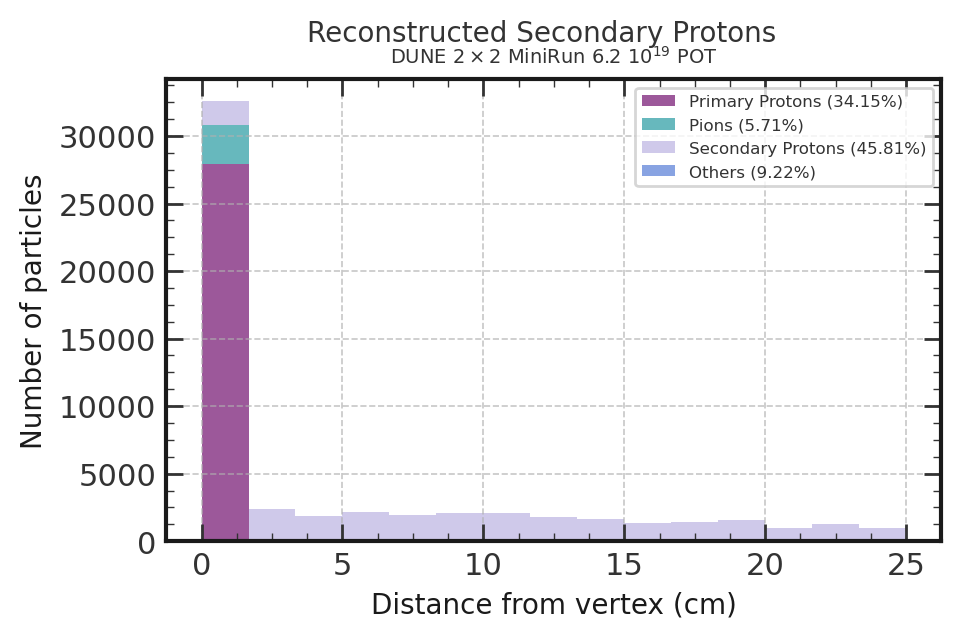

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 9_2025-02-26.pdf
Interaction Summary:

There are 74502 reconstructed vertices.
There are 67598 reco vertices matching true interaction signal.
There are 112568 true interactions
1: 10.81%
3: 44.35%
4: 23.29%
5: 1.22%
10: 4.35%
0: 15.99%
2: 0.00%

Efficiency: 60.05%
Purity: 90.73%


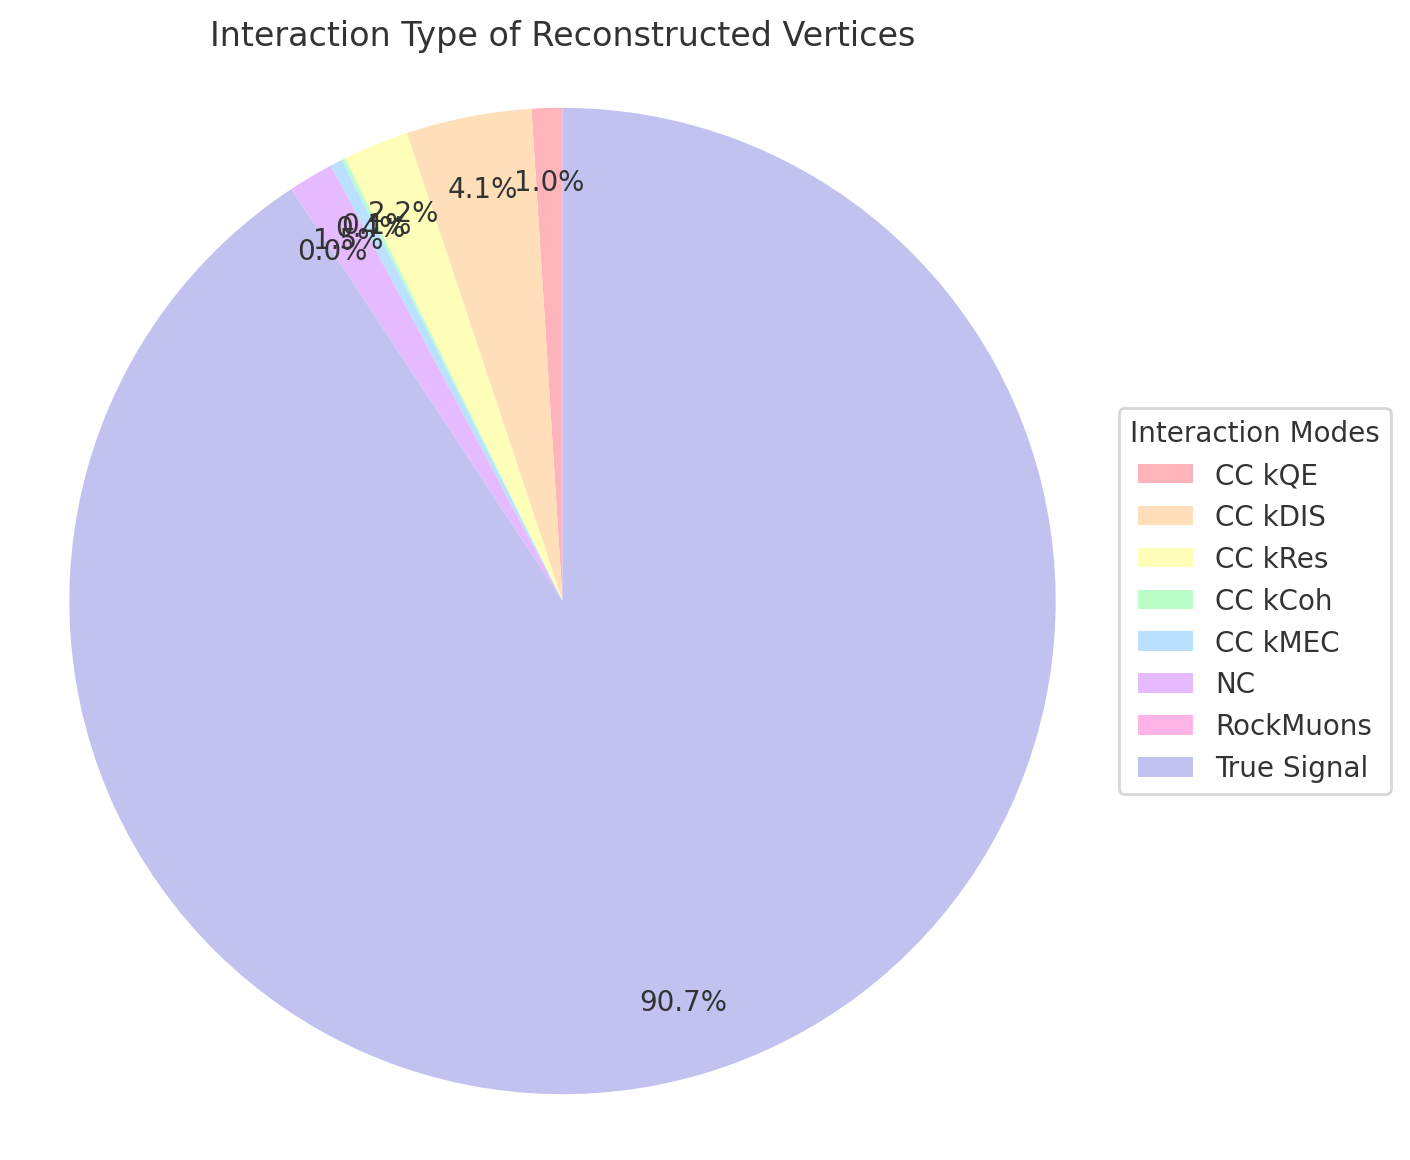

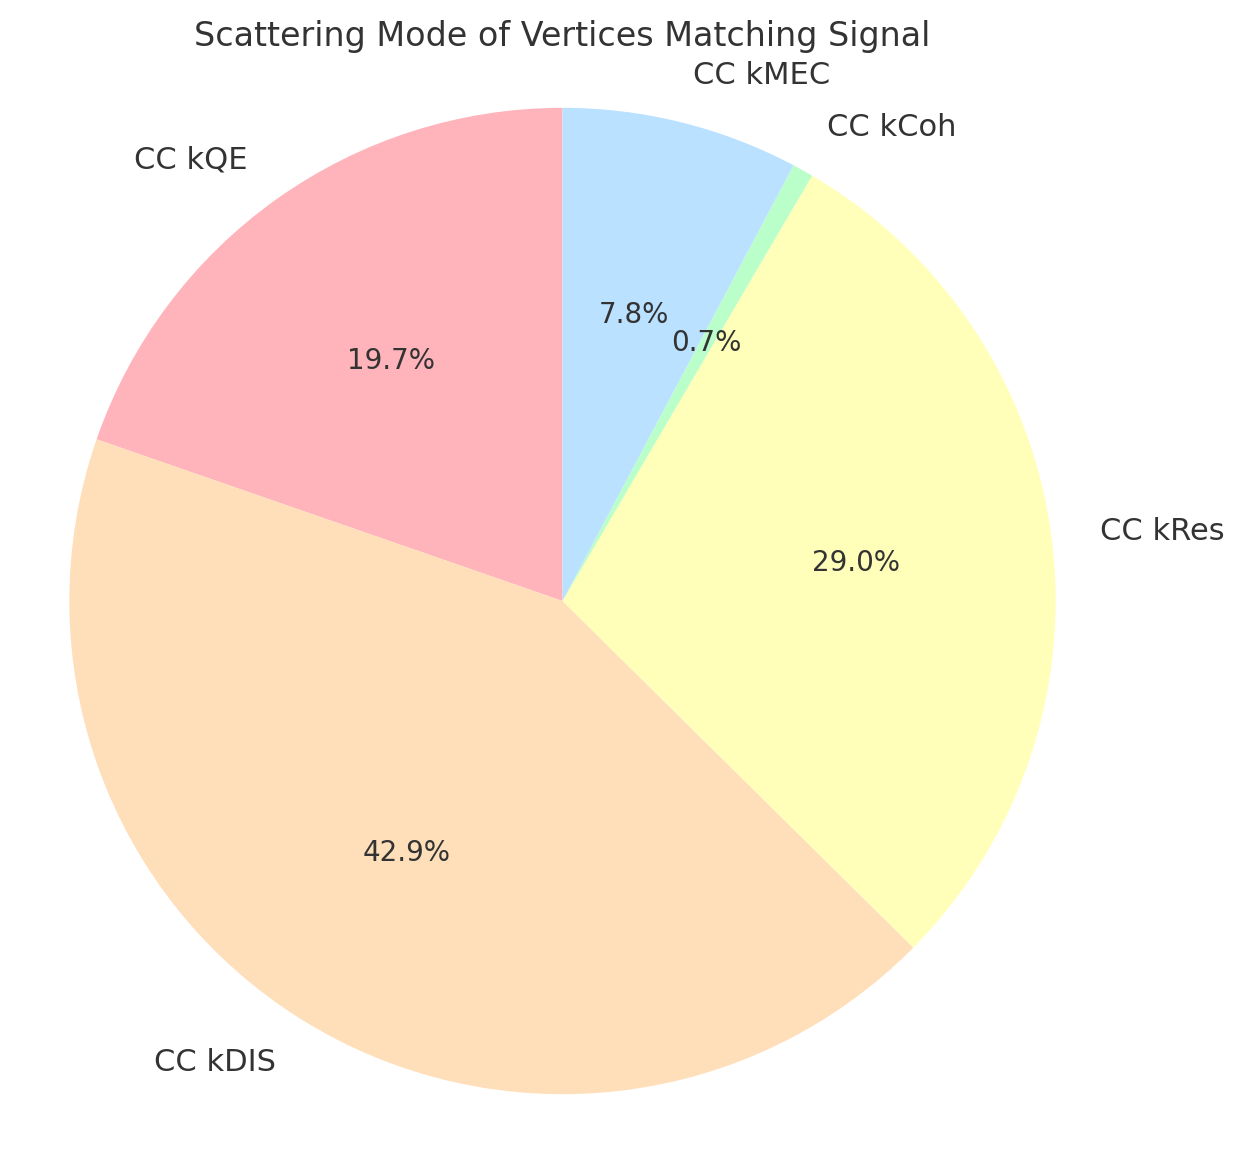

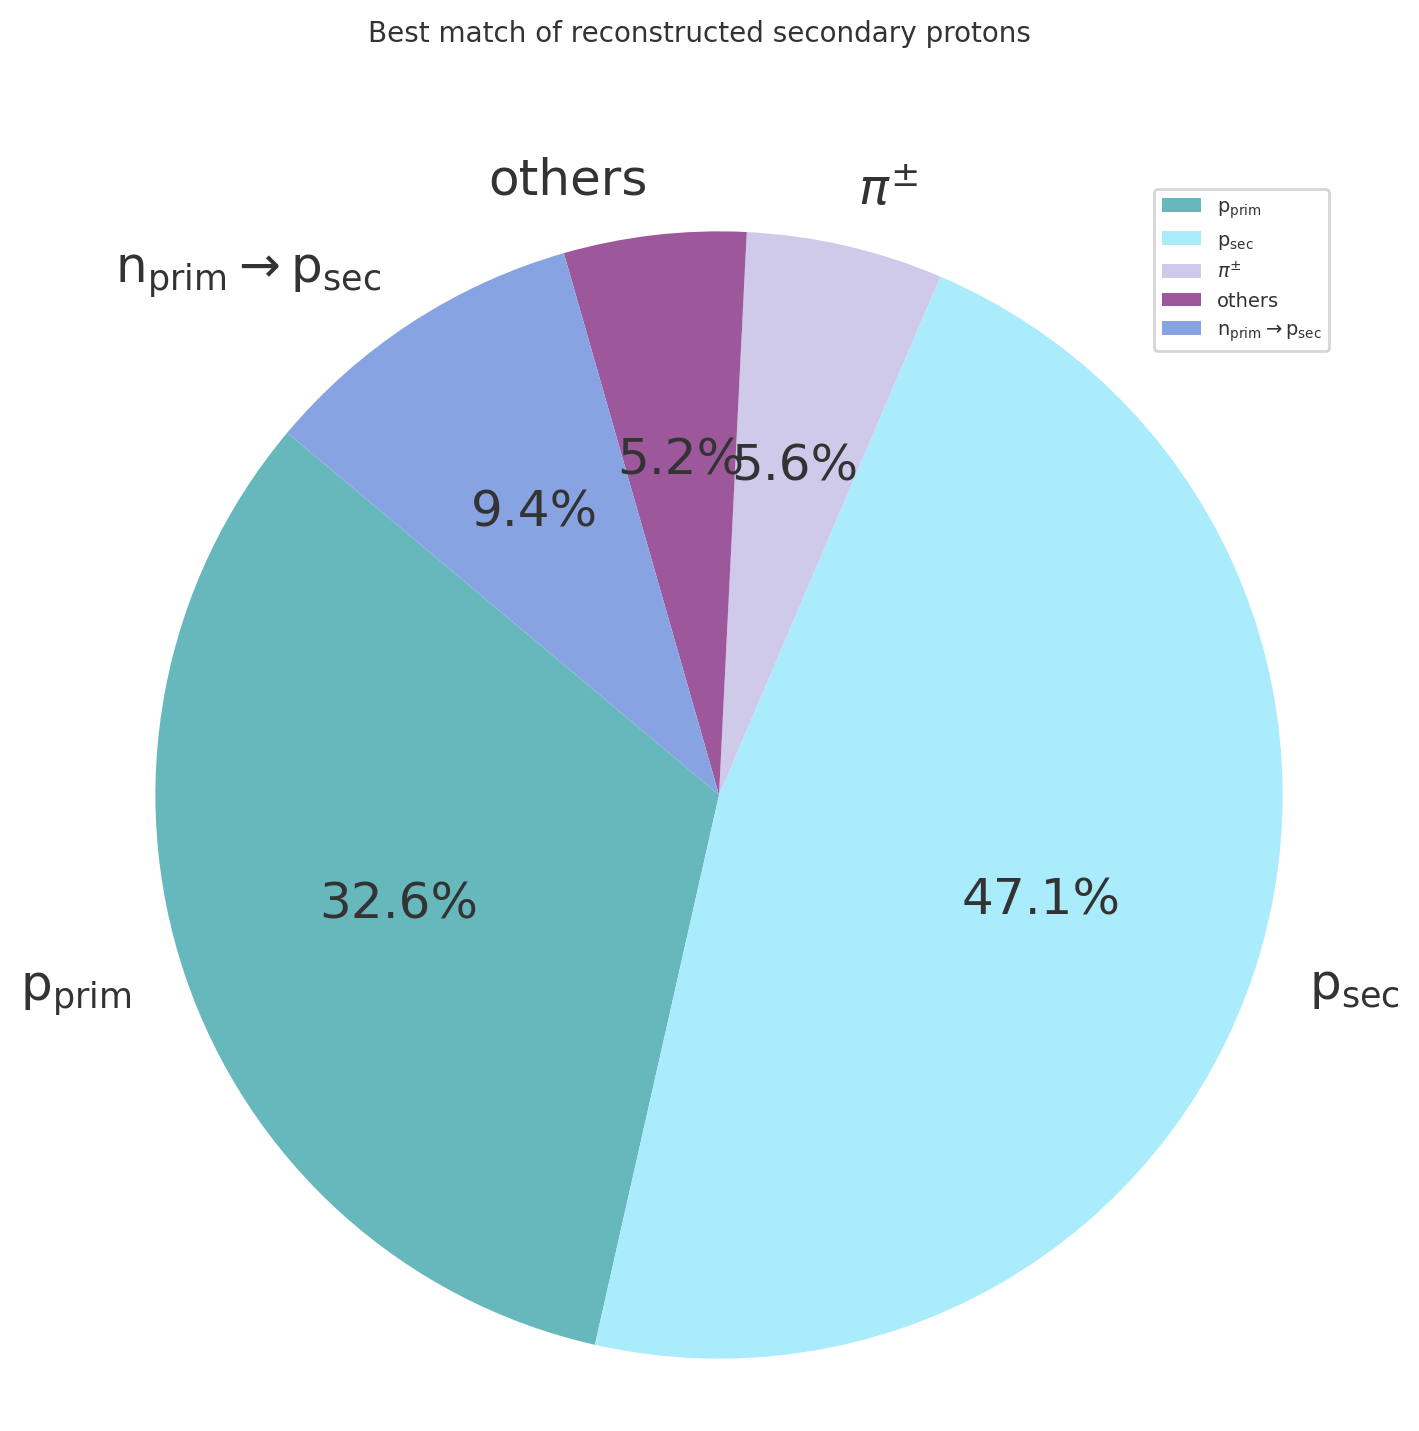

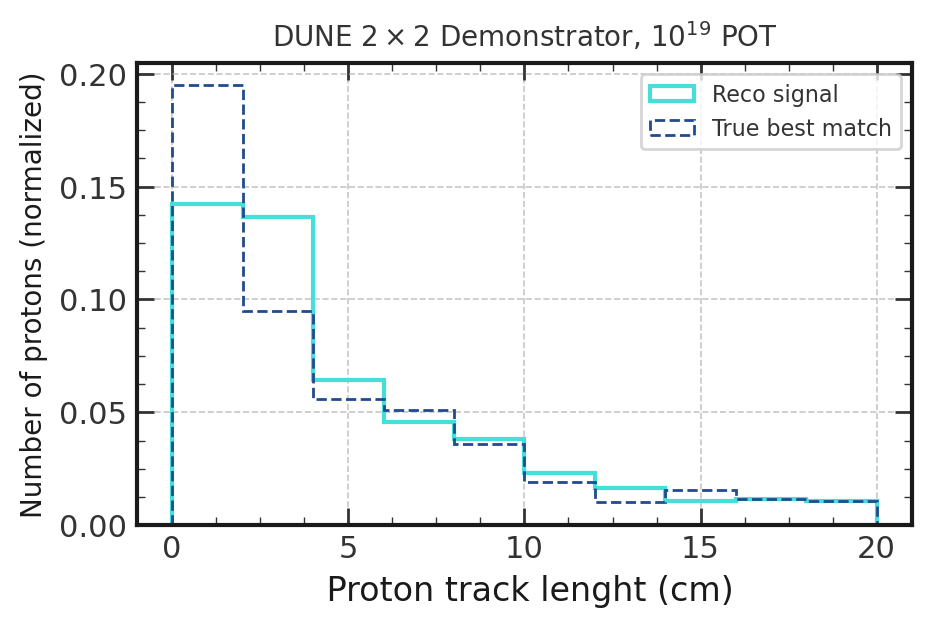

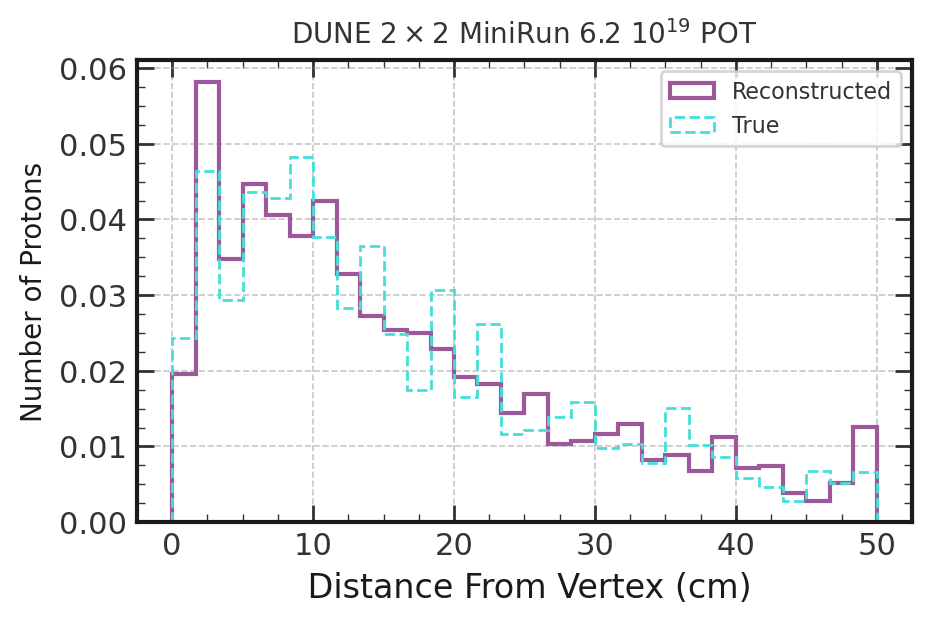

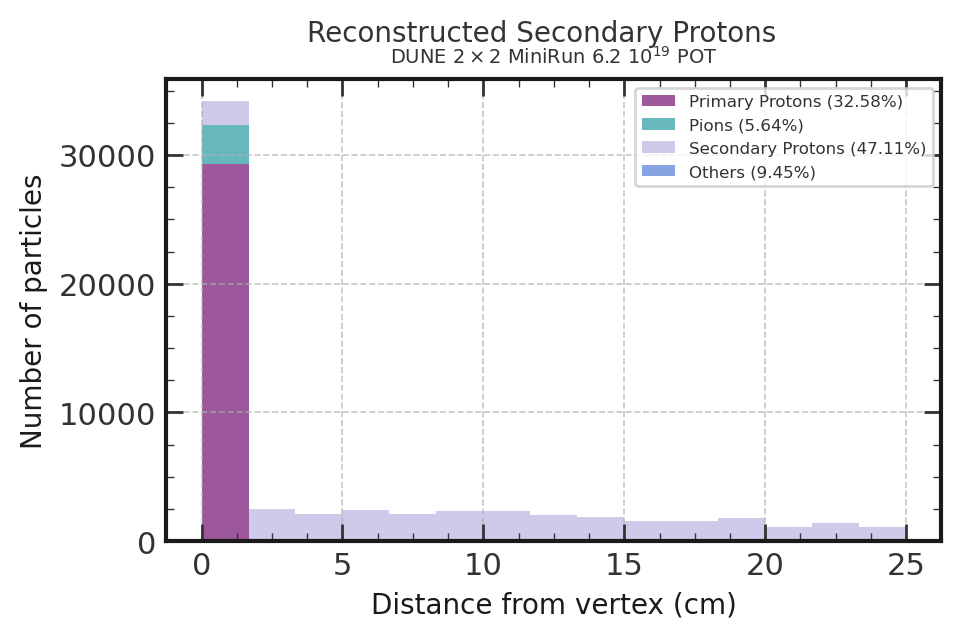

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 10_2025-02-26.pdf


In [30]:
analysis = NeutrinoAnalysis()
pdg_tab = ParticleCode()

ixn_dict= {
    'file_number': [], 'event_number': [], 'ixn_number': [], 'true_ixn_number': [], 'cc': [], 'nprim': [], 'nsec': [], 'nneutron': [], 'nproton': [],
    'npip': [], 'npim': [], 'npi0': [], 'mode': [], 'match': []
}

reco_proton_dic = {
     'best_match_idx': [] , 'best_match_pdg': [], 'best_match_type': [], 'best_match_length':[], 'best_match_distance':[],'best_match_energy':[], 
    'reco_distance':[], 'reco_energy':[], 'reco_length':[],'parent_id' :[],'vtx_t': [], 'vtx_r': [],'ev': []
}

sample_dic = {
     'best_match_idx': [] , 'best_match_pdg': [], 'best_match_type': [], 'best_match_length':[], 'best_match_distance':[],'best_match_energy':[], 
    'reco_distance':[], 'reco_energy':[], 'reco_length':[],'parent_id' :[],'vtx_t': [], 'vtx_r': [],'ev': []
}

results = [] # List to store the results for each mode
prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi, single, inx,secprotons, secprotons_true  = 0, 0,0,0,0

conditions ={
    'Case 1':[True, True, 0,0], 'Case 2':[True, False, 0,0],'Case 1.5':[True, True, 0.5,0], 'Case 2.5':[True, False, 0.5,0], 
    'Case 3':[False, False, 0,0],'Case 4':[False, False, 0.5,0], 'Case 5':[False, False, 1,0], 'Case 6':[False, False, 1.5,0],  'Case 7':[False, False, 2,0], 
    'Case 8':[False, False, 0.5,0.5], 'Case 9':[False, False, 1,1], 'Case 10':[False, False, 1.5,2]
}#,  'Case 11':[False, False, 2,2] }

for case,condition in conditions.items():
    
    for ev in range(len(df)):
        ev_data = df.iloc[ev]
        neutrino_selector = NeutrinoSelection(ev_data, pdg_tab, QE=condition[0], exclusive=condition[1], proton_threshold=2)
        reco_vertices, muon_track = neutrino_selector.reco_neutrino_signal(mode='mx2') 
        true_interactions = neutrino_selector.true_neutrino_signal()
        analysis.num_vertices += np.sum(reco_vertices)
        analysis.num_interactions += np.sum(true_interactions)
        
        for vtx_index, value in enumerate(reco_vertices): 
            if value:  
                match, best_match_idx, match_vertices_signal = neutrino_selector.matching(vtx_index)
                if best_match_idx is not None:
                    neutrino_selector.save_inx_info(vtx_index)
                    #get inx and vtx data  
                    true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                    reco_data = caf_reader.get_reco_ixn_data(ev_data, vtx_index)
                    neutron_selector = NeutronSelection( pdg_tab,ev_data, vtx_index, reco_data, muon_track, tpc_dist = 5, radius=condition[2], cyl=condition[3])
                    reco_dic = neutron_selector.part_scanner()
                    num_recoprotons = len(reco_dic['best_match_type'])
                    
                    for index in range(num_recoprotons):
                        bm_ixn=reco_dic['best_match_ixn'][index]
                        bm_type=reco_dic['best_match_type'][index]
                        bm_idx=reco_dic['best_match_idx'][index]
                        parent_id = reco_dic['parent_id'][index]
                        reco_energy=reco_dic['energy'][index]
                        track_length=reco_dic['length'][index]
                        vtx_distance=reco_dic['distance'][index]
                        bm_truth_data = caf_reader.get_true_ixn_data(ev_data, bm_ixn)
                        bm_dic = neutron_selector.get_bm_truth_data(bm_truth_data,bm_type, bm_idx)
                        #save the bm true info
                        reco_proton_dic['best_match_pdg'].append(bm_dic['pdg'])
                        reco_proton_dic['best_match_type'].append(bm_dic['type'])
                        reco_proton_dic['best_match_energy'].append(bm_dic['energy'])
                        reco_proton_dic['best_match_length'].append(bm_dic['length'])
                        reco_proton_dic['best_match_distance'].append(bm_dic['distance'])
                        reco_proton_dic['best_match_idx'].append(bm_idx)
                        reco_proton_dic['vtx_t'].append(bm_ixn)
                        reco_proton_dic['parent_id'].append(parent_id)
                        #reco info
                        reco_proton_dic['reco_energy'].append(reco_energy)
                        reco_proton_dic['reco_length'].append(track_length)
                        reco_proton_dic['reco_distance'].append(vtx_distance)
                        reco_proton_dic['vtx_r'].append(vtx_index)
                        reco_proton_dic['ev'].append(ev)
                        #filter the proton secondaries
                        if (bm_dic['pdg']==pdg_tab.proton) and (bm_type ==3): 
                            secprotons+=1
                            neutron_induced=neutron_selector.was_neutron_induced(bm_ixn, parent_id)
                            if neutron_induced:
                                sample_dic['best_match_pdg'].append(bm_dic['pdg'])
                                sample_dic['best_match_type'].append(bm_dic['type'])
                                sample_dic['best_match_energy'].append(bm_dic['energy'])
                                sample_dic['best_match_length'].append(bm_dic['length'])
                                sample_dic['best_match_distance'].append(bm_dic['distance'])
                                sample_dic['best_match_idx'].append(bm_idx)
                                sample_dic['vtx_t'].append(bm_ixn)
                                sample_dic['parent_id'].append(parent_id)
                                #reco info
                                sample_dic['reco_energy'].append(reco_energy)
                                sample_dic['reco_length'].append(track_length)
                                sample_dic['reco_distance'].append(vtx_distance)
                                sample_dic['vtx_r'].append(vtx_index)
                                sample_dic['ev'].append(ev)
                    if match: 
                        analysis.count_match_FV += 1
                        analysis.insignal_counters[ev_data['rec.mc.nu.mode'][best_match_idx]] += 1
                    else:
                        scattering_counters, current_counters = analysis.type_interaction(ev_data, best_match_idx)

        # Save interaction data
        for key in ixn_dict.keys():
            ixn_dict[key].extend(neutrino_selector.ixn_dict[key])
            
        #true neutron multiplicity for all true interactions
        for vtx_t, interaction_value in enumerate(true_interactions):
            if interaction_value:
                secprotons_true += np.sum(ev_data['rec.mc.nu.sec.pdg']==pdg_tab.proton)
        
                inx +=1 
                sec_dic['track_neutron'] = []
                prim_dic = neutrino_selector.particles_inx( vtx_t, 'prim', prim_dic)
                sec_dic = neutrino_selector.particles_inx(vtx_t,'sec', sec_dic)
                neutron_particle_count = Counter(sec_dic['track_neutron'])
                for count in neutron_particle_count.values():
                    if count > 1: multi += 1
                    elif count == 1: single += 1
        pdg_counter = Counter(sec_dic['pdg'])
      
    # Compute efficiency and purity
    efficiency, purity = analysis.efficiency_purity()
    # Display results
    analysis.display_summary()
    analysis.plot_interactions()
    analysis.plot_signal_interactions()
    
    # Generate the PDF with all plots of neutron selection
    global_analyzer_pdf = GlobalAnalyzer(reco_proton_dic, sample_dic, case)
    global_analyzer_pdf.particle_predictions()
    global_analyzer_pdf.plot_track_lenght()
    global_analyzer_pdf.plot_part_dis()
    pdf_filename = global_analyzer_pdf.save_pdf()
    print(f'Results are saved in {pdf_filename}')
       
    results.append({
        'case':f'QE:{neutrino_selector.QE} - Exc:{neutrino_selector.exclusive}',
        'conditions': condition,
        'sph_radius': f' {neutron_selector.radius} cm',
        'cyl_radius': f'{neutron_selector.cyl} cm',
        'True inx':  analysis.num_interactions,
        'Reco inx':analysis.num_vertices,
        'Matched inx': analysis.count_match_FV,
        'Purity inx':  round(analysis.efficiency,4),
        'Efficiency inx': round(analysis.purity,4),
        'TrueNeutrons': len(prim_dic['E']),
        'True n-particles': len(sec_dic['E']),
        'True n-proton': pdg_counter[pdg_tab.proton],
        'True n-neutron': pdg_counter[pdg_tab.neutron],
        'True n-photon': pdg_counter[pdg_tab.photon],
        'TrueSingle': single,
        'TrueMulti': multi,
        'RecoSecProtons': len(reco_proton_dic['reco_energy']), 
        'MatchedSecProtons': secprotons,
        'Reco n-protons': len(sample_dic['reco_length']), 
        'Efficiency p': secprotons/secprotons_true,
        'Purity p': secprotons/len(reco_proton_dic['best_match_pdg']),
        'Efficiency n-p': len(sample_dic['reco_energy'])/pdg_counter[pdg_tab.proton],
        'Purity n-p': len(sample_dic['reco_energy'])/ len(reco_proton_dic['best_match_pdg'])    
    })
    # Convert the results list to a DataFrame
    results_df = pd.DataFrame(results)
    reco_proton__df = pd.DataFrame(reco_proton_dic) 
    sample_dic_df = pd.DataFrame(sample_dic)
    # Define the file name
    file_name = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/{case}"
    results_df.to_csv(f'/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/results.csv', index=False)
    reco_proton__df.to_csv(f'{file_name}_reco_proton.csv', index=False)
    sample_dic_df.to_csv(f'{file_name}_sample.csv', index = False)

In [31]:
results_df

,case,conditions,sph_radius,cyl_radius,True inx,Reco inx,Matched inx,Purity inx,Efficiency inx,TrueNeutrons,...,True n-photon,TrueSingle,TrueMulti,RecoSecProtons,MatchedSecProtons,Reco n-protons,Efficiency p,Purity p,Efficiency n-p,Purity n-p
0,QE:True - Exc:True,"[True, True, 0, 0]",0 cm,0 cm,2850,478,397,0.1393,0.8305,9538,...,54,514,135,63,16,15,0.002602,0.253968,0.028846,0.238095
1,QE:True - Exc:False,"[True, False, 0, 0]",0 cm,0 cm,5700,2555,1787,0.3135,0.6994,19076,...,108,1028,270,2199,525,186,0.042683,0.238745,0.178846,0.084584
2,QE:True - Exc:True,"[True, True, 0.5, 0]",0.5 cm,0 cm,8550,3033,2184,0.2554,0.7201,28614,...,162,1542,405,2262,541,201,0.029322,0.239169,0.128846,0.088859
3,QE:True - Exc:False,"[True, False, 0.5, 0]",0.5 cm,0 cm,11400,5110,3574,0.3135,0.6994,38152,...,216,2056,540,4398,1050,372,0.042683,0.238745,0.178846,0.084584
4,QE:False - Exc:False,"[False, False, 0, 0]",0 cm,0 cm,24046,13784,11577,0.4815,0.8399,69531,...,423,3944,1361,15676,7362,1401,0.095747,0.469635,0.297011,0.089372
5,QE:False - Exc:False,"[False, False, 0.5, 0]",0.5 cm,0 cm,36692,22458,19580,0.5336,0.8718,100910,...,630,5832,2182,26954,13674,2430,0.105852,0.507309,0.330432,0.090154
6,QE:False - Exc:False,"[False, False, 1, 0]",1 cm,0 cm,49338,31132,27583,0.5591,0.8860,132289,...,837,7720,3003,38232,19986,3459,0.110134,0.522756,0.346212,0.090474
7,QE:False - Exc:False,"[False, False, 1.5, 0]",1.5 cm,0 cm,61984,39806,35586,0.5741,0.8940,163668,...,1044,9608,3824,49510,26298,4488,0.112500,0.531165,0.355401,0.090648
8,QE:False - Exc:False,"[False, False, 2, 0]",2 cm,0 cm,74630,48480,43589,0.5841,0.8991,195047,...,1251,11496,4645,60788,32610,5517,0.114001,0.536455,0.361415,0.090758
9,QE:False - Exc:False,"[False, False, 0.5, 0.5]",0.5 cm,0.5 cm,87276,57154,51592,0.5911,0.9027,226426,...,1458,13384,5466,71807,38886,6543,0.114932,0.541535,0.365490,0.091119


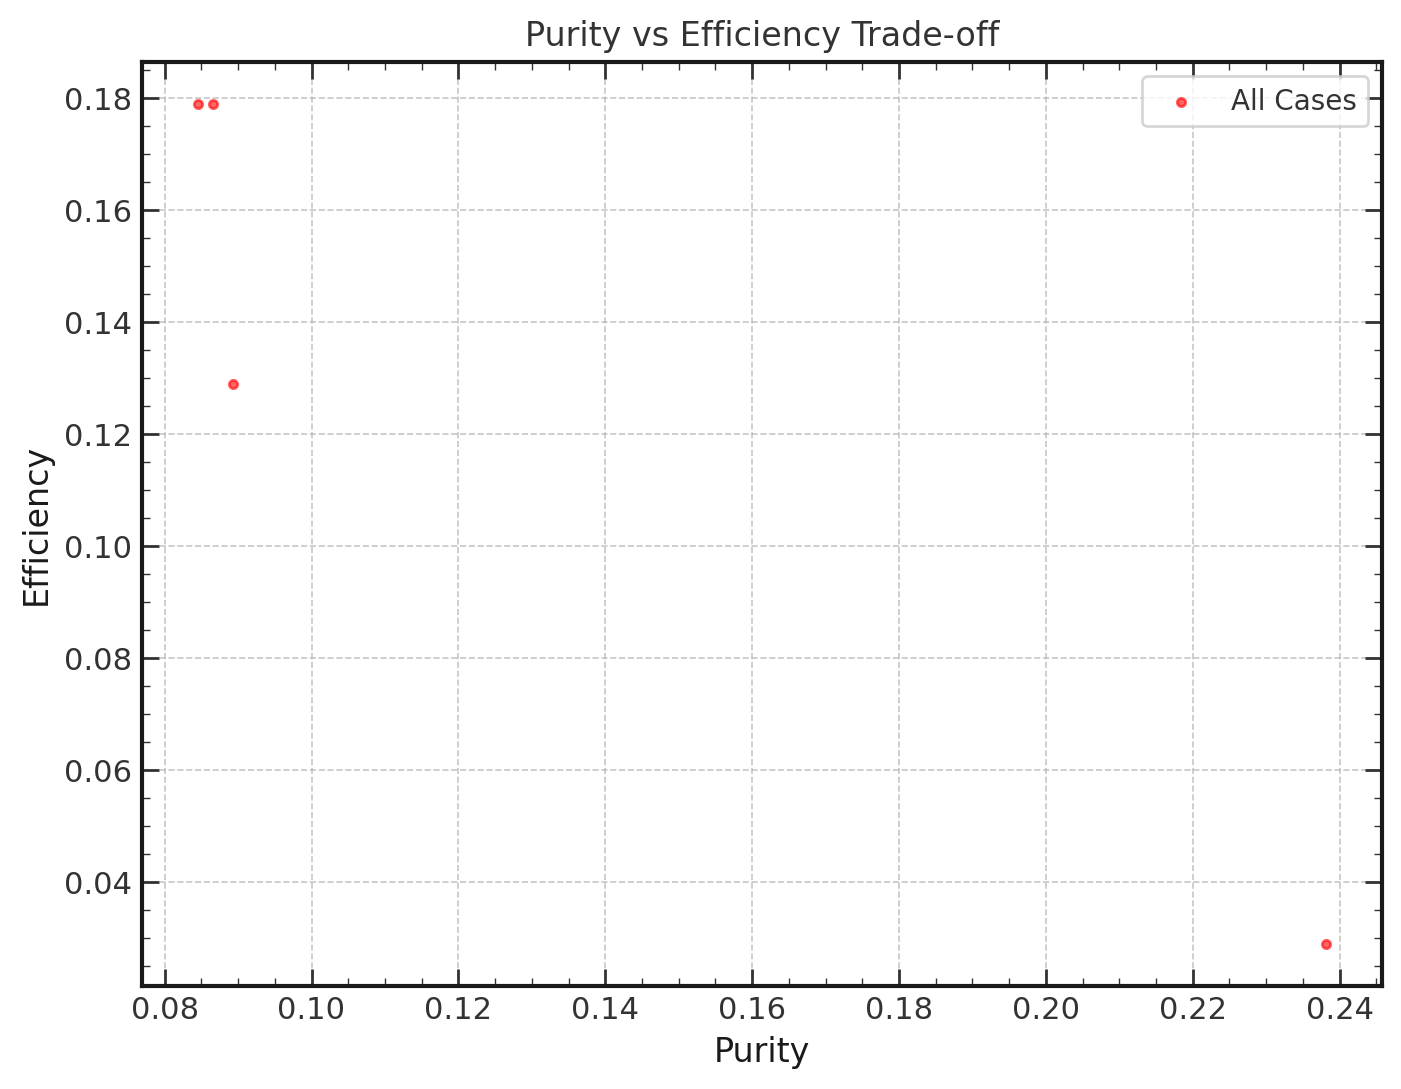

In [ ]:
results_file = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/results.csv"  # Update with your actual file path
results_df = pd.read_csv(results_file)

results = {
    'case': results_df['case'].tolist(), 
    'Efficiency p' : results_df['Efficiency p'].tolist(),
    'Purity p': results_df['Purity p'].tolist(),
    'Efficiency': results_df['Efficiency n-p'].tolist(),
    'Purity' : results_df['Purity n-p'].tolist(),
}

plt.figure(figsize=(8, 6))
plt.scatter(results["Purity"], results["Efficiency"], label="All Cases", color="red", alpha=0.6)
plt.xlabel("Purity")
plt.ylabel("Efficiency")
plt.title("Purity vs Efficiency Trade-off")
plt.legend()
plt.grid(True)
plt.show()



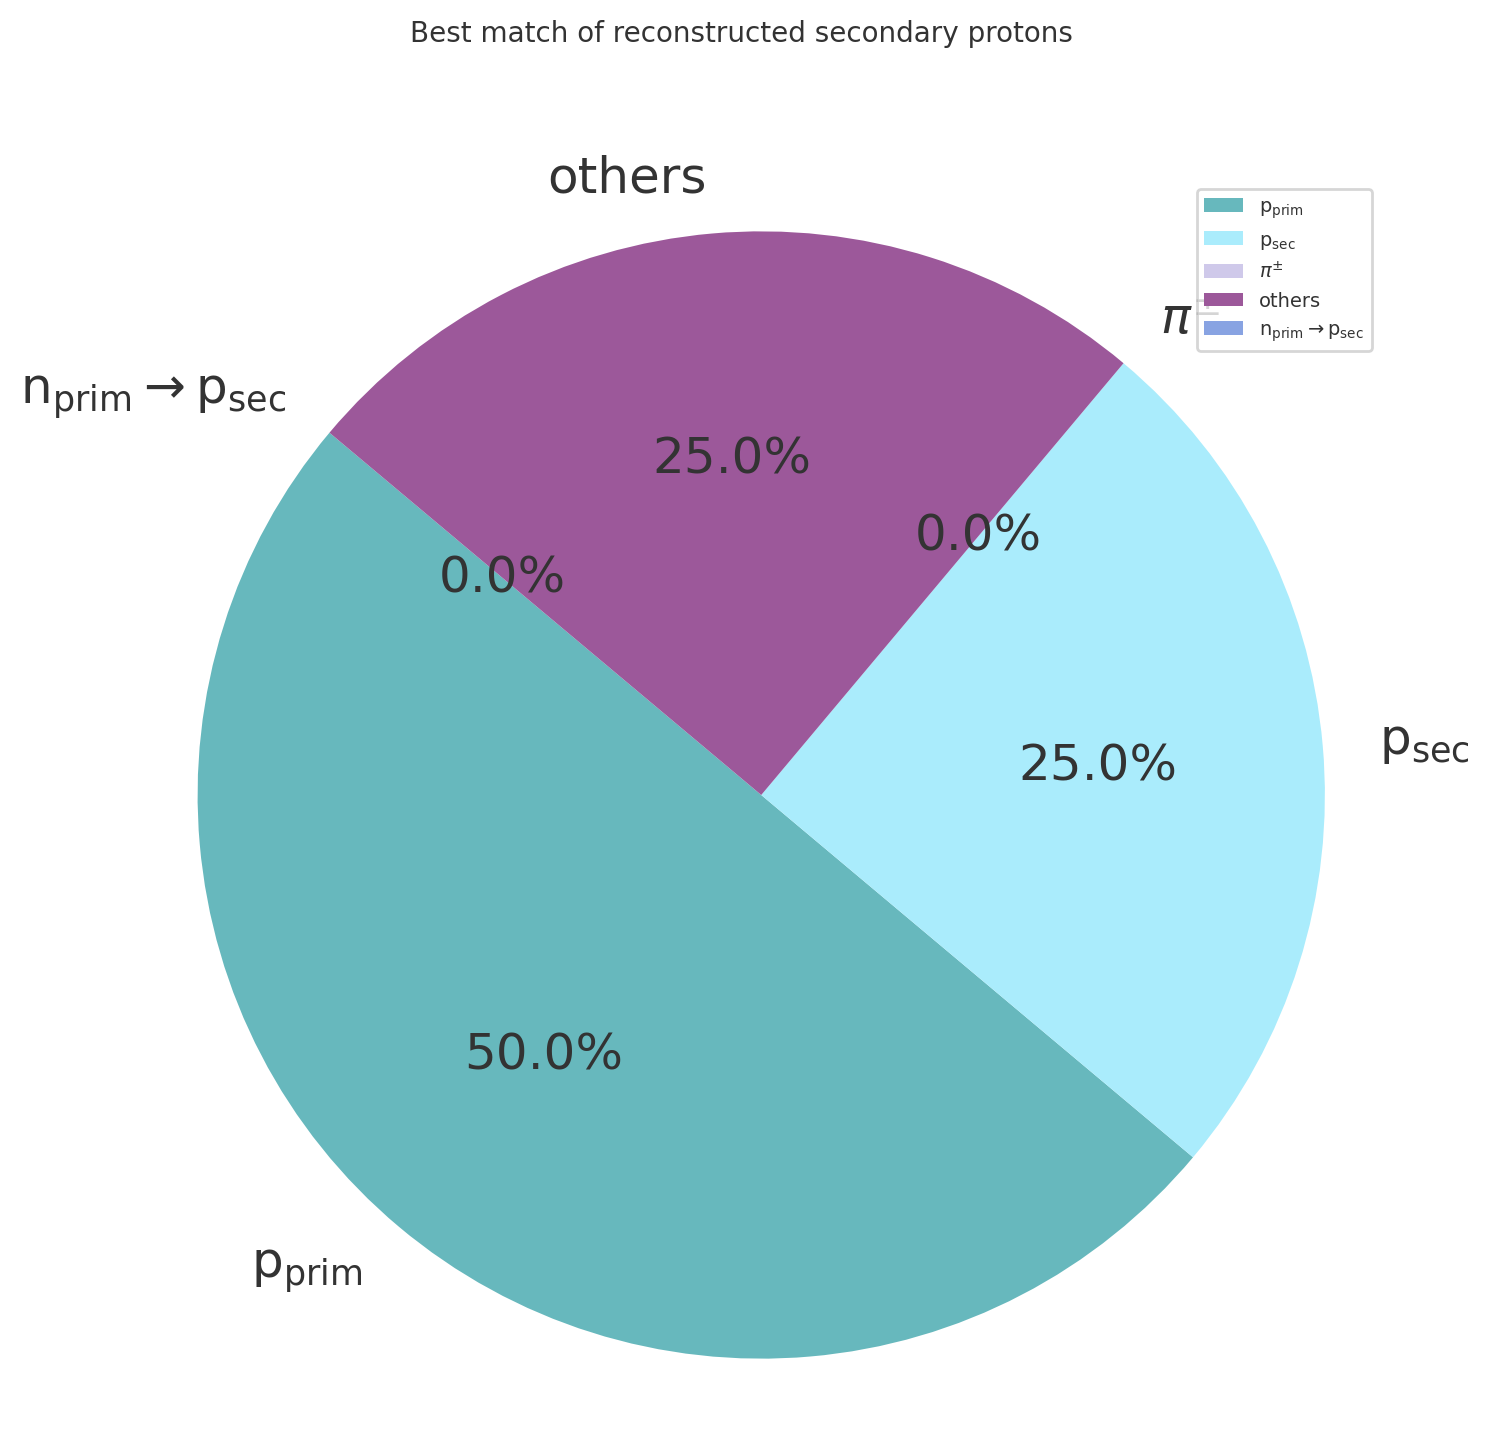

/global/homes/g/gkufatty/.conda/envs/env-nersc/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


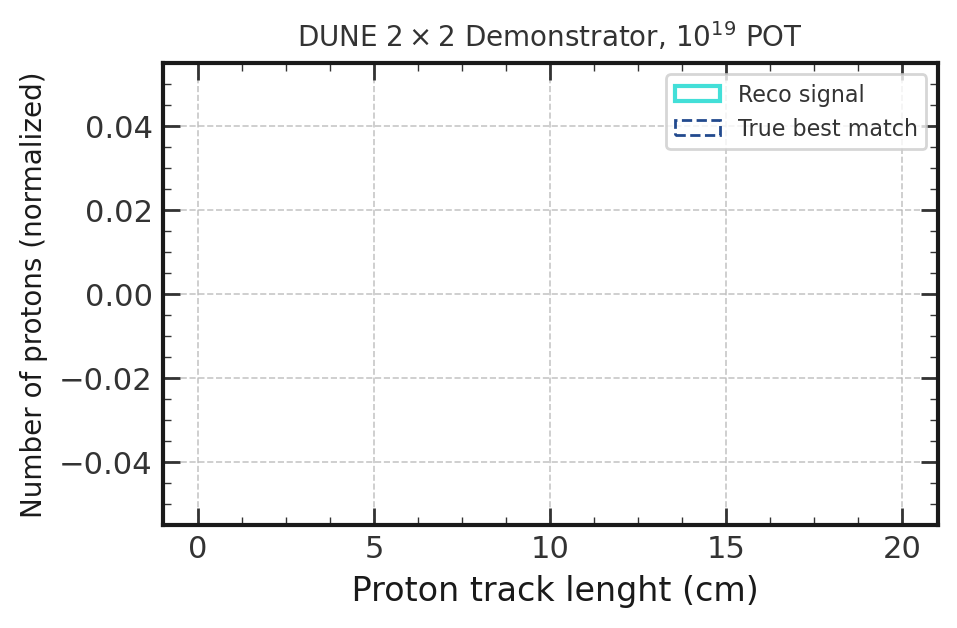

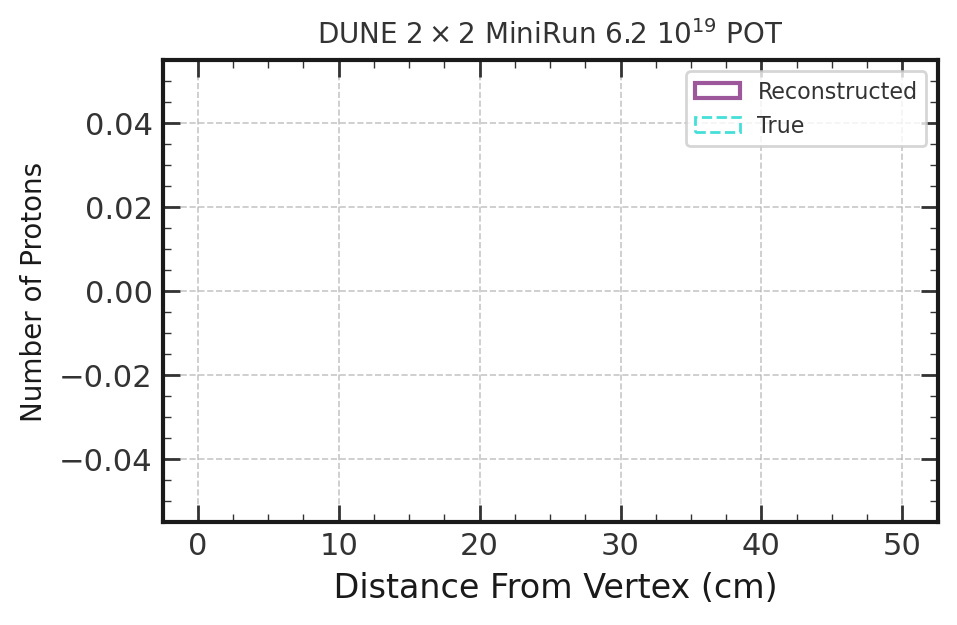

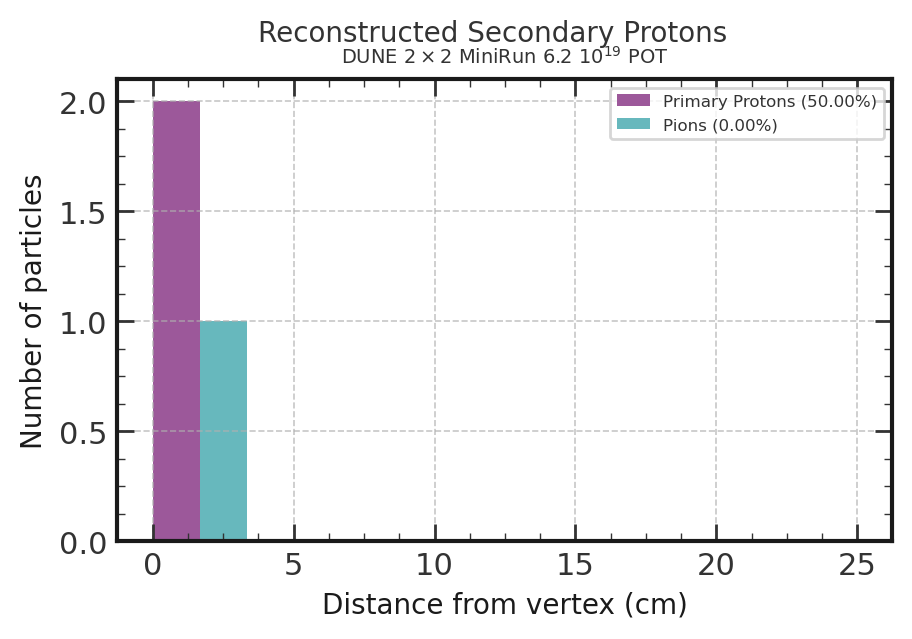

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7f59fc8662a0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1000x600 with 2 Axes>

In [12]:
#to run the global analyzer directly from the cvs files

import pandas as pd

# Load CSV file into a DataFrame

case= 'Case A'

reco_proton_file = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_selection_{case}_reco_proton.csv"  # Update with your actual file path
sample_dic_file = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_selection_{case}_sample.csv"
reco_proton_dic_df = pd.read_csv(reco_proton_file)
sample_dic_df = pd.read_csv(sample_dic_file)

# Convert the DataFrame to the required dictionary format
reco_proton_dic = {
    'best_match_pdg': reco_proton_dic_df['best_match_pdg'].tolist(),
    'best_match_type': reco_proton_dic_df['best_match_type'].tolist(),
    'best_match_length': reco_proton_dic_df['best_match_length'].tolist(),
    'best_match_distance': reco_proton_dic_df['best_match_distance'].tolist(),
    'reco_distance':reco_proton_dic_df['reco_distance'].tolist(),
    'reco_energy': reco_proton_dic_df['reco_energy'].tolist(),
    'reco_length': reco_proton_dic_df['reco_length'].tolist(),
    'parent_id': reco_proton_dic_df['parent_id'].tolist(),
}

sample_dic = {
    'best_match_length': sample_dic_df['best_match_length'].tolist(),
    'best_match_distance': sample_dic_df['best_match_distance'].tolist(),
    'best_match_energy': sample_dic_df['best_match_energy'].tolist(),
    'reco_distance': sample_dic_df['reco_distance'].tolist(),
    'reco_energy': sample_dic_df['reco_energy'].tolist(),
    'reco_length': sample_dic_df['reco_length'].tolist(),
}

# Initialize GlobalAnalyzer with dictionaries
global_analyzer = GlobalAnalyzer(reco_proton_dic, sample_dic, case="Case A")

# Run the analysis functions
global_analyzer.particle_predictions()
global_analyzer.plot_track_lenght()
global_analyzer.plot_part_dis()
global_analyzer.lenght_vs_distance()

# Save the results to a PDF
pdf_filename = global_analyzer.save_pdf()
print(f"Analysis saved in {pdf_filename}")
